# Retornos por descuento - notebook ordenado y auditado

Versión corregida:

- Se renombra **ROP** a **ROPI** en métricas, filtros, gráficos y títulos.
- Se corrige el **uplift de volumen (%)** como incremento bruto de venta ($) dividido por la venta baseline esperada ($), multiplicado por 100.
- Se simplifican las secciones 2 y 3 para dejar como métricas económicas centrales sólo el incremento en margen, el incremento en venta, el costo de promoción, el ROPI y el uplift.

La bitácora de filtros permite revisar en qué paso se pierden filas, cuántas se pierden y qué porcentaje representa.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FECHA_INICIO_DATOS_ANALISIS = pd.Timestamp("2025-01-01")
FECHA_FIN_DATOS_VENTAS = pd.Timestamp("2026-03-31")

# ============================================================
# Bitácora de filtros y transformaciones
# ============================================================
# Objetivo:
# - registrar cada filtro en el momento en que se aplica;
# - ver cuántas filas se pierden en cada paso;
# - evitar doble conteo: la bitácora secuencial cuenta pérdidas sobre la base
#   que sobrevivió al filtro anterior.

bitacora_filtros = []

def _n_unicos(df, id_col=None):
    if id_col is None or id_col not in df.columns:
        return np.nan
    return df[id_col].nunique(dropna=True)

def _normalizar_mask(mask, df):
    if isinstance(mask, (bool, np.bool_)):
        return pd.Series(bool(mask), index=df.index)

    if isinstance(mask, pd.Series):
        mask = mask.reindex(df.index)
    else:
        mask = pd.Series(mask, index=df.index)

    return mask.fillna(False).astype(bool)

def registrar_cambio(
    paso,
    df_antes,
    df_despues,
    grupo="",
    id_col=None,
    tipo="filtro",
    notas="",
):
    n_antes = len(df_antes)
    n_despues = len(df_despues)
    n_eliminadas = n_antes - n_despues
    pct_eliminado = n_eliminadas / n_antes if n_antes else 0

    registro = {
        "grupo": grupo,
        "tipo": tipo,
        "paso": paso,
        "filas_antes": n_antes,
        "filas_despues": n_despues,
        "filas_eliminadas": n_eliminadas,
        "pct_eliminado": pct_eliminado,
        "ids_antes": _n_unicos(df_antes, id_col),
        "ids_despues": _n_unicos(df_despues, id_col),
        "ids_eliminados": (
            _n_unicos(df_antes, id_col) - _n_unicos(df_despues, id_col)
            if id_col is not None and id_col in df_antes.columns and id_col in df_despues.columns
            else np.nan
        ),
        "notas": notas,
    }
    bitacora_filtros.append(registro)

    etiqueta_grupo = f"{grupo} | " if grupo else ""
    print(
        f"{etiqueta_grupo}{paso}: "
        f"{n_antes:,} -> {n_despues:,} filas "
        f"({n_eliminadas:,} eliminadas; {pct_eliminado:.1%})"
    )
    if notas:
        print(f"  Nota: {notas}")

    return registro

def registrar_estado(paso, df, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df,
        grupo=grupo,
        id_col=id_col,
        tipo="estado",
        notas=notas,
    )

def registrar_transformacion(paso, df_antes, df_despues, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df_antes,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="transformación",
        notas=notas,
    )

def aplicar_filtro(df, condicion, paso, grupo="", id_col=None, notas=""):
    mask = condicion(df) if callable(condicion) else condicion
    mask = _normalizar_mask(mask, df)

    df_despues = df.loc[mask].copy()

    registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="filtro",
        notas=notas,
    )

    return df_despues

def _desempaquetar_filtro(filtro):
    if isinstance(filtro, dict):
        return (
            filtro["paso"],
            filtro["condicion"],
            filtro.get("notas", ""),
        )

    if len(filtro) == 2:
        paso, condicion = filtro
        notas = ""
    else:
        paso, condicion, notas = filtro

    return paso, condicion, notas

def auditar_filtros_secuenciales(df, filtros, grupo="", id_col=None):
    actual = df.copy()
    registros = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        actual = aplicar_filtro(
            actual,
            condicion,
            paso=paso,
            grupo=grupo,
            id_col=id_col,
            notas=notas,
        )
        registros.append(bitacora_filtros[-1])

    return actual, pd.DataFrame(registros)

def calcular_impacto_individual(df, filtros, id_col=None):
    filas = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        mask = condicion(df) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, df)
        df_despues = df.loc[mask].copy()

        n_antes = len(df)
        n_despues = len(df_despues)

        filas.append({
            "paso": paso,
            "filas_antes": n_antes,
            "filas_despues": n_despues,
            "filas_eliminadas": n_antes - n_despues,
            "pct_eliminado": (n_antes - n_despues) / n_antes if n_antes else 0,
            "ids_antes": _n_unicos(df, id_col),
            "ids_despues": _n_unicos(df_despues, id_col),
            "ids_eliminados": (
                _n_unicos(df, id_col) - _n_unicos(df_despues, id_col)
                if id_col is not None and id_col in df.columns and id_col in df_despues.columns
                else np.nan
            ),
            "notas": notas,
        })

    return pd.DataFrame(filas)

def mostrar_bitacora_filtros(grupo=None):
    tabla = pd.DataFrame(bitacora_filtros)

    if tabla.empty:
        print("La bitácora de filtros todavía está vacía.")
        return tabla

    if grupo is not None:
        tabla = tabla.loc[tabla["grupo"].eq(grupo)].copy()

    if tabla.empty:
        print(f"No hay registros para el grupo: {grupo}")
        return tabla

    tabla = tabla.copy()
    tabla["pct_eliminado"] = (tabla["pct_eliminado"] * 100).round(2)

    columnas = [
        "grupo",
        "tipo",
        "paso",
        "filas_antes",
        "filas_despues",
        "filas_eliminadas",
        "pct_eliminado",
        "ids_antes",
        "ids_despues",
        "ids_eliminados",
        "notas",
    ]
    columnas = [col for col in columnas if col in tabla.columns]

    display(tabla[columnas])
    return tabla[columnas]


# 0. Cargas de datos

## 0.1 Ventas

In [2]:
# Cargar datos de ventas
path_ventas = "datos/Ventas por Cliente/ventas_con_descuento_aplicado_nuevo.csv"
ventas = pd.read_csv(path_ventas)

registrar_estado(
    "Ventas cargadas",
    ventas,
    grupo="0. Cargas de datos",
)

print("Ventas - Filas:", ventas.shape[0])
display(ventas.head())


/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_94189/3656900966.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


0. Cargas de datos | Ventas cargadas: 9,616,165 -> 9,616,165 filas (0 eliminadas; 0.0%)
Ventas - Filas: 9616165


,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,venta_id,...,descuento_pct_observado,descuento_bucket_pct,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,0,...,-5.876235,5.876235,0.0,-5.876235,base_forzado,NaN,False,True,46152.0,2712.0
1,1174760,CB,32,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,398,...,-12.476633,12.476633,-12.5,0.023367,base,2372.0,True,False,12410.4,1548.4
2,1137411,CB,54,2025-01-02,6800,"PAPAS FRITAS 2,5 KG calibre 7x7 MAESTRO",213202,100.0,2132.020000,21875,...,-3.001820,3.001820,-3.0,-0.001820,base,2837.0,True,False,219800.0,6598.0
3,1134837,CB,32,2025-01-02,3145,PASTA SALAME 16x125 GR LP,9308,2.0,4654.000000,21518,...,0.000000,-0.000000,0.0,0.000000,ninguno,NaN,False,False,9308.0,0.0
4,1114635,CB,54,2025-01-02,3144,PASTA POLLO PIMENTON 16x125 GR LP,9028,2.0,4514.000000,21240,...,-3.008165,3.008165,-3.0,-0.008165,base,1277.0,True,False,9308.0,280.0


In [3]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado',
       'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real', 'kilo_real',
       'precio_real', 'venta_id', 'zona', 'distrito', 'precio_lista',
       'dscto_base', 'dscto_volumen', 'dscto_binario', 'carta_impacto',
       'id_descuento_base', 'ids_descuento_volumen', 'id_descuento_binario',
       'id_descuento_carta_impacto', 'año_factura', 'mes_factura',
       'texto_breve_material', 'kg_por_unidad', 'peso_variable',
       'cantidad_unidades', 'cantidad_unidades_entera', 'inconsistencia',
       'unidades_redondeadas', 'precio_por_unidad', 'precio_lista_por_unidad',
       'descuento_pct_observado', 'descuento_bucket_pct',
       'descuento_pct_matcheado', 'diferencia_descuento_pct',
       'descuento_aplicado', 'id_descuento_aplicado', 'calza_con_descuento',
       'gap', 'monto_a_precio_lista', 'costo_descuento'],
      dtype='str')

## 0.2 Descuentos consolidados

In [4]:
path_descuentos = "datos/Descuentos históricos/consolidado_descuentos.csv"
descuentos = pd.read_csv(path_descuentos)
descuentos_raw = descuentos.copy()

registrar_estado(
    "Descuentos cargados",
    descuentos,
    grupo="0. Cargas de datos",
    id_col="id_descuento" if "id_descuento" in descuentos.columns else None,
)

print("Descuentos - Filas:", descuentos.shape[0])
display(descuentos.head())


0. Cargas de datos | Descuentos cargados: 76,509 -> 76,509 filas (0 eliminadas; 0.0%)
Descuentos - Filas: 76509


,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
0,1,base,1006,CB,54.0,NaN,2026-03-02,2026-03-18,0.0,338
1,2,base,1006,CB,54.0,NaN,2026-03-19,9999-12-31,0.0,339
2,3,base,1006,HR,55.0,NaN,2026-03-02,2026-03-18,0.0,1118
3,4,base,1006,HR,55.0,NaN,2026-03-19,2026-03-29,0.0,1119
4,5,base,1006,HR,56.0,NaN,2023-11-01,2024-06-09,-24.8,1656


### Chequeos rápidos de descuentos crudos

In [5]:
descuentos[descuentos["cod_consolidado"].isna()]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
44,45,base,1020,CB,NaN,NaN,2024-02-05,2024-02-29,-10.0,3643
4898,4899,carta_impacto,1006,NaN,NaN,1002215.0,2026-04-01,2026-04-10,2878.0,3422
4899,4900,carta_impacto,1006,NaN,NaN,1002667.0,2026-04-06,2026-04-10,2878.0,3629
4900,4901,carta_impacto,1006,NaN,NaN,1008117.0,2026-04-07,2026-04-10,2878.0,3732
4901,4902,carta_impacto,1006,NaN,NaN,1039197.0,2026-04-06,2026-04-10,2878.0,3975
...,...,...,...,...,...,...,...,...,...,...
74335,74336,carta_impacto,970,NaN,NaN,92024.0,2026-04-01,2026-04-30,3746.0,20539
75634,75635,volumen,6770,CB,NaN,NaN,2024-04-15,2024-04-25,-21.2,2179
75696,75697,volumen,6771,CB,NaN,NaN,2024-04-15,2024-04-25,-26.8,2180
75843,75844,volumen,689,CB,NaN,NaN,2024-05-12,2024-05-25,-20.0,2178


In [6]:
descuentos[descuentos["tipo_descuento"]=="base"]["monto_descuento"].describe()

count    3588.000000
mean      -12.648690
std        13.395793
min       -57.100000
25%       -20.000000
50%        -6.000000
75%        -3.000000
max         0.000000
Name: monto_descuento, dtype: float64

In [7]:
descuentos[
    (descuentos["tipo_descuento"]=="binario") &
    (descuentos["monto_descuento"] < -30)
]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
4253,4254,binario,3951,CB,32.0,NaN,2025-07-08,2025-07-28,-40.0,255
4254,4255,binario,3951,CB,32.0,NaN,2025-07-29,2025-08-16,-50.0,256
4258,4259,binario,3951,CB,54.0,NaN,2025-07-08,2025-07-28,-40.0,634
4259,4260,binario,3951,CB,54.0,NaN,2025-07-29,2025-08-16,-50.0,635
4263,4264,binario,3951,HR,37.0,NaN,2025-07-08,2025-07-28,-40.0,791
4264,4265,binario,3951,HR,37.0,NaN,2025-07-29,2025-08-16,-50.0,792
4268,4269,binario,3951,HR,55.0,NaN,2025-07-08,2025-07-28,-40.0,849
4269,4270,binario,3951,HR,55.0,NaN,2025-07-29,2025-08-16,-50.0,850
4495,4496,binario,6775,CB,32.0,NaN,2025-07-08,2025-07-14,-35.0,314
4497,4498,binario,6775,CB,32.0,NaN,2025-12-26,2026-01-13,-35.0,316


## 0.3 Costos por SKU

In [8]:
# Un Excel con varias hojas, una por mes, mismas columnas en todas las hojas.
# Se concatenan todas las hojas en un solo DataFrame con una columna adicional que indica el mes.
path_costos = "datos/Consolidado ABC SKU (oct25'-mar26') FINAL.xlsx"
lista_dfs_costos = []
xls = pd.ExcelFile(path_costos, engine="openpyxl")

for sheet_name in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl")
    df["Mes"] = sheet_name
    lista_dfs_costos.append(df)

costos = pd.concat(lista_dfs_costos, ignore_index=True)

registrar_estado(
    "Costos cargados",
    costos,
    grupo="0. Cargas de datos",
)

print("Costos - Filas:", costos.shape[0])
display(costos.head())


0. Cargas de datos | Costos cargados: 1,362 -> 1,362 filas (0 eliminadas; 0.0%)
Costos - Filas: 1362


,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,...,Energía por kilo,Distribución Fijo por kilo,T Producción por kilo,Gastos DM Canales por kilo,Gastos DM Marketing por kilo,Reponer por kilo,Gastos. Zonales Directos por kilo,O. G. Fijos Indirectos por kilo,Otros Distribución Variable por kilo,Mes
0,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,...,109.616023,51.243956,536.821480,15.667047,69.781019,107.213380,165.224788,356.538820,11.496824,Mar 26
1,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,...,109.616023,51.243956,651.298434,11.683227,70.917961,46.616111,174.134955,361.737830,1.065923,Mar 26
2,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,...,113.161033,51.243956,618.843430,10.371729,69.481203,84.973946,173.792703,355.245462,7.533394,Mar 26
3,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,...,100.040929,51.243956,256.383338,18.882393,79.456343,78.698590,153.891363,402.053980,30.895221,Mar 26
4,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,...,62.693270,51.243956,543.850298,9.115506,48.949864,76.885585,100.209147,259.732670,11.442677,Mar 26


In [9]:
costos.columns

Index(['SKU', ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable', 'Aporte por kilo', 'Costo por kilo',
       'Frío Externo por kilo', 'Energía por kilo',
       'Distribución Fijo por kilo', 'T Producción por kilo',
       'Gastos DM Canales por kilo', 'Gastos DM Marketing por kilo',
       'Reponer por kilo', 'Gastos. Zonales Directos por kilo',
       'O. G. Fijos Indirectos por kilo',
       'Otros Distribución Variable por kilo', 'Mes'],
      dtype='str')

In [10]:
cols_costos = [
    "Mes",
    "SKU",
    " Kilos Finales",
    "Facturación",
    "Aporte",
    "Costo",
    "Frío Externo",
    "Energía",
    "Distribución Fijo",
    "T Producción",
    "Gastos DM Canales",
    "Gastos DM Marketing",
    "Reponer",
    "Gastos. Zonales Directos",
    "O. G. Fijos Indirectos",
    "Otros Distribución Variable",
]

COLUMNAS_COSTO_2 = [
    "Costo",
    "Frío Externo",
    "Energía",
    "Distribución Fijo",
    "T Producción",
    "Gastos DM Canales",
    "Gastos DM Marketing",
    "Reponer",
    "Gastos. Zonales Directos",
    "O. G. Fijos Indirectos",
    "Otros Distribución Variable",
]

costos_antes_columnas = costos.copy()
costos = costos[cols_costos].copy()

registrar_transformacion(
    "Costos: selección de columnas útiles",
    costos_antes_columnas,
    costos,
    grupo="0. Cargas de datos",
    notas=f"Columnas seleccionadas: {len(cols_costos)}",
)

display(costos.head())


0. Cargas de datos | Costos: selección de columnas útiles: 1,362 -> 1,362 filas (0 eliminadas; 0.0%)
  Nota: Columnas seleccionadas: 16


,Mes,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,Mar 26,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,4.050366e+06,6.223088e+06,9.590299e+06,2.069492e+07,6.673211e+05
1,Mar 26,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,2.376188e+05,1.561926e+05,5.834592e+05,1.212044e+06,3.571497e+03
2,Mar 26,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,1.965619e+06,2.403908e+06,4.916585e+06,1.004987e+07,2.131193e+05
3,Mar 26,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,1.043556e+06,1.033604e+06,2.021163e+06,5.280456e+06,4.057686e+05
4,Mar 26,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,8.715810e+06,1.368993e+07,1.784283e+07,4.624692e+07,2.037436e+06


In [11]:
costos_totales = costos.groupby(["SKU"]).sum().reset_index()
costos_totales.head()

,SKU,Mes,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,20,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,335586.218,1662597580,153623897.0,6.106304e+08,7.001417e+06,4.006351e+07,1.867814e+07,1.710162e+08,6.286412e+06,2.557901e+07,3.301842e+07,5.643622e+07,1.059107e+08,3.132913e+06
1,27,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,19992.314,96892820,5081558.0,3.159423e+07,4.193767e+05,2.394141e+06,1.112293e+06,1.034808e+07,1.377657e+05,1.474946e+06,8.965587e+05,3.313494e+06,6.182961e+06,3.760482e+04
2,30,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,166105.952,823931212,66366773.0,3.727935e+08,3.463517e+06,2.051210e+07,9.254694e+06,9.408060e+07,3.468700e+06,1.265933e+07,1.274087e+07,3.103956e+07,5.252660e+07,1.192458e+06
3,102,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,76809.925,431581113,33333712.0,1.736206e+08,1.609275e+06,8.061725e+06,4.282384e+06,1.821598e+07,2.161787e+06,6.481077e+06,5.942076e+06,1.108287e+07,2.718273e+07,4.919939e+06
4,151,Dic 25Nov 25Oct 25,4611.500,16473437,110102.0,6.366029e+06,5.175683e+04,2.510712e+05,2.476763e+05,2.694126e+06,2.367651e+04,1.942270e+05,4.545280e+04,4.993600e+05,1.016952e+06,1.800514e+04


In [12]:
COLUMNAS_COSTO_2_FALTANTES = [
    columna for columna in COLUMNAS_COSTO_2
    if columna not in costos_totales.columns
]
assert not COLUMNAS_COSTO_2_FALTANTES, (
    f"Faltan columnas para Costo 2: {COLUMNAS_COSTO_2_FALTANTES}"
)

costos_totales["Costo 2 Total"] = costos_totales[COLUMNAS_COSTO_2].sum(axis=1)

costos_totales["Margen 2"] = (
    costos_totales["Facturación"]
    - costos_totales["Costo 2 Total"]
)


In [13]:
costos_totales["Costo 2 por Kilo"] = (
    costos_totales["Costo 2 Total"]
    / costos_totales[" Kilos Finales"]
)

# Se mantiene sólo como referencia histórica. No se usa en secciones 2 y 3.
costos_totales["Margen 2 por Kilo"] = (
    costos_totales["Margen 2"]
    / costos_totales[" Kilos Finales"]
)


## 0.4 Datos SKU

In [14]:
path_info_sku = "datos/Subfamilia y subcategoría.xlsx"
info_sku = pd.read_excel(path_info_sku)

registrar_estado(
    "Info SKU cargada",
    info_sku,
    grupo="0. Cargas de datos",
    id_col="sku" if "sku" in info_sku.columns else None,
)

display(info_sku.head())


0. Cargas de datos | Info SKU cargada: 1,873 -> 1,873 filas (0 eliminadas; 0.0%)


,sku,Subfamilia,Subcategora,Texto breve de material,Grupo art.,Creado el,estado,Válido de,GTPos,Denominación,...,Denominación.2,Tip Carne,Denom..1,Gr. Empaq.,envasado_granel,Gr. Carga,Denominación.3,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,Arrollado,Arrollado Lomo c/Ají,ARROLLADO LOMO CON AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,NaN,NaN,ARROLLADO LOMO CORTADO SJ,SJ,20.10.2005,Bloqueado,19.10.2020,NORM,Posición normal,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,NaN,NaN,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,SJ,27.01.2011,Bloqueado,08.04.2016,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,NaN,NaN,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,SJ,23.05.2013,Bloqueado,18.03.2020,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,Arrollado,Arrollado Lomo,ARROLLADO LOMO SIN AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [15]:
info_sku.columns
# Index(['sku', 'Subfamilia', 'Subcategora', 'Texto breve de material',
#        'Grupo art.', 'Creado el', 'estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'kg Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Denominación.1', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.2',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'envasado_granel', 'Gr. Carga',
#        'Denominación.3', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

Index(['sku', 'Subfamilia', 'Subcategora', 'Texto breve de material',
       'Grupo art.', 'Creado el', 'estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'kg Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Denominación.1', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.2',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'envasado_granel', 'Gr. Carga',
       'Denominación.3', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

In [16]:
path_seg_productos = "datos/Segmentacion_productos (1).xlsx"
seg_productos = pd.read_excel(path_seg_productos)

registrar_estado(
    "Segmentación productos cargada",
    seg_productos,
    grupo="0. Cargas de datos",
    id_col="sku" if "sku" in seg_productos.columns else None,
)

display(seg_productos.head())


0. Cargas de datos | Segmentación productos cargada: 218 -> 218 filas (0 eliminadas; 0.0%)


,sku,familia_hana,marca,descripción,kilos,ingresos_m,margen_1_m,margen_2_m,ebitda_m,marca_normalizada,ebitda_pct,margen_pct,segmento_producto,Infaltables
0,3109,JAMON G2,LA PREFERIDA,JAMON SANDWICH LP,398390.580,2075342.036,1.320033e+06,758334.664456,623179.820711,la preferida,0.300278,0.636056,Héroe,Faltable
1,421,PATE,SAN JORGE,PATE TERNERA 8x125 GRS.SJ,508267.552,1954343.478,1.329923e+06,478819.218456,348340.995060,san jorge,0.178239,0.680496,Héroe,Faltable
2,970,CARNES,SAN JORGE,MOLIDA 14x250 GR SJ,411706.750,1811076.827,9.322576e+05,435391.298100,316841.069705,san jorge,0.174946,0.514753,Héroe,Faltable
3,6783,LACTEOS,Los Nogales,MANTEQUILLA 125 GRS x8 LOS NOGALES,179480.900,1732725.366,5.869634e+05,335079.432902,229628.847484,los nogales,0.132525,0.338752,Héroe,Faltable
4,210,FIAMBRES,SAN JORGE,FIAMBRE SANDWICH SJ,809267.352,2903166.617,2.010887e+06,960805.242614,766732.128914,san jorge,0.264102,0.692653,Héroe,210


In [17]:
seg_productos.columns
# Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
#        'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
#        'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
#       dtype='str')

Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
       'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
       'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
      dtype='str')

# 1. Cruces y filtros pre-análisis

## 1.1 Filtros de ventas auditados

In [18]:
# Filtrar solo los canales relevantes.
# La bitácora registra cuántas filas se pierden en cada paso.
canales_relevantes = [
    32,  # COBERTURA
    54,  # VOLUMEN COBERTURA
    # 67,  # MAYORISTAS CADENAS
    # 57,  # MAYORISTA B VOLUMEN
    # 38,  # OTROS MAYORISTAS
    # 55,  # HORECA VOLUMEN
    # 37,  # OTROS HORECA
]

ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"])

ventas = aplicar_filtro(
    ventas,
    ventas["cod_consolidado"].isin(canales_relevantes),
    paso="Ventas: cod_consolidado en canales relevantes",
    grupo="1. Cruces y filtros pre-análisis",
    notas=f"Canales incluidos: {canales_relevantes}",
)

ventas = aplicar_filtro(
    ventas,
    ventas["fecha_factura"] >= FECHA_INICIO_DATOS_ANALISIS,
    paso="Ventas: fecha_factura >= fecha inicio análisis",
    grupo="1. Cruces y filtros pre-análisis",
    notas=f"Fecha inicio análisis: {FECHA_INICIO_DATOS_ANALISIS:%Y-%m-%d}",
)

ventas = aplicar_filtro(
    ventas,
    ventas["fecha_factura"] <= FECHA_FIN_DATOS_VENTAS,
    paso="Ventas: fecha_factura <= fecha de corte",
    grupo="1. Cruces y filtros pre-análisis",
    notas=f"Fecha de corte: {FECHA_FIN_DATOS_VENTAS:%Y-%m-%d}",
)

assert ventas["fecha_factura"].min() >= FECHA_INICIO_DATOS_ANALISIS, (
    "Hay ventas anteriores a la fecha mínima del análisis."
)
assert ventas["fecha_factura"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay ventas posteriores a la fecha máxima del análisis."
)

print("Fecha mínima de ventas usada:", ventas["fecha_factura"].min().strftime("%Y-%m-%d"))
print("Fecha máxima de ventas usada:", ventas["fecha_factura"].max().strftime("%Y-%m-%d"))
display(ventas.head())


1. Cruces y filtros pre-análisis | Ventas: cod_consolidado en canales relevantes: 9,616,165 -> 9,616,165 filas (0 eliminadas; 0.0%)
  Nota: Canales incluidos: [32, 54]
1. Cruces y filtros pre-análisis | Ventas: fecha_factura >= fecha inicio análisis: 9,616,165 -> 9,616,165 filas (0 eliminadas; 0.0%)
  Nota: Fecha inicio análisis: 2025-01-01
1. Cruces y filtros pre-análisis | Ventas: fecha_factura <= fecha de corte: 9,616,165 -> 9,479,067 filas (137,098 eliminadas; 1.4%)
  Nota: Fecha de corte: 2026-03-31
Fecha mínima de ventas usada: 2025-01-02
Fecha máxima de ventas usada: 2026-03-31


,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,venta_id,...,descuento_pct_observado,descuento_bucket_pct,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,0,...,-5.876235,5.876235,0.0,-5.876235,base_forzado,NaN,False,True,46152.0,2712.0
1,1174760,CB,32,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,398,...,-12.476633,12.476633,-12.5,0.023367,base,2372.0,True,False,12410.4,1548.4
2,1137411,CB,54,2025-01-02,6800,"PAPAS FRITAS 2,5 KG calibre 7x7 MAESTRO",213202,100.0,2132.020000,21875,...,-3.001820,3.001820,-3.0,-0.001820,base,2837.0,True,False,219800.0,6598.0
3,1134837,CB,32,2025-01-02,3145,PASTA SALAME 16x125 GR LP,9308,2.0,4654.000000,21518,...,0.000000,-0.000000,0.0,0.000000,ninguno,NaN,False,False,9308.0,0.0
4,1114635,CB,54,2025-01-02,3144,PASTA POLLO PIMENTON 16x125 GR LP,9028,2.0,4514.000000,21240,...,-3.008165,3.008165,-3.0,-0.008165,base,1277.0,True,False,9308.0,280.0


## 1.2 Filtros de descuentos auditados

In [19]:
# Normalizar nombre y formato del tipo de descuento.
# Nota: en algunos archivos puede aparecer escrito como "tipo_desuento".
def _normalizar_tipo_descuento_descuentos(df):
    df = df.copy()

    if "tipo_descuento" not in df.columns and "tipo_desuento" in df.columns:
        df = df.rename(columns={"tipo_desuento": "tipo_descuento"})

    df["tipo_descuento"] = (
        df["tipo_descuento"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return df


def _preparar_descuentos_para_analisis(df):
    df = df.copy()

    df["fecha_inicio_original"] = df["fecha_inicio"].astype("string").str.strip()
    df["fecha_fin_original"] = df["fecha_fin"].astype("string").str.strip()

    fecha_fin_normalizada = df["fecha_fin_original"].replace(
        {"9999-12-31": FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")}
    )

    df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio_original"])
    df["fecha_fin"] = pd.to_datetime(fecha_fin_normalizada)

    n_fecha_inicio_recortada = int(
        (df["fecha_inicio"] < FECHA_INICIO_DATOS_ANALISIS).sum()
    )
    n_fecha_fin_abierta = int(df["fecha_fin_original"].eq("9999-12-31").sum())

    mask_fecha_fin_post_corte = df["fecha_fin"] > FECHA_FIN_DATOS_VENTAS
    n_finitos_recortados_post_corte = int(
        (
            mask_fecha_fin_post_corte
            & ~df["fecha_fin_original"].eq("9999-12-31")
        ).sum()
    )

    df.loc[
        df["fecha_inicio"] < FECHA_INICIO_DATOS_ANALISIS,
        "fecha_inicio",
    ] = FECHA_INICIO_DATOS_ANALISIS

    df.loc[mask_fecha_fin_post_corte, "fecha_fin"] = FECHA_FIN_DATOS_VENTAS

    df.attrs["resumen_preparacion_descuentos"] = {
        "n_fecha_inicio_recortada": n_fecha_inicio_recortada,
        "n_fecha_fin_abierta": n_fecha_fin_abierta,
        "n_finitos_recortados_post_corte": n_finitos_recortados_post_corte,
    }

    return df


def _aplicar_filtros_sin_registro(df, filtros):
    actual = df.copy()

    for filtro in filtros:
        _, condicion, _ = _desempaquetar_filtro(filtro)
        mask = condicion(actual) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, actual)
        actual = actual.loc[mask].copy()

    return actual


def aplicar_descuentos_pre_analisis(
    df,
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    registrar_en_bitacora=True,
):
    actual = _normalizar_tipo_descuento_descuentos(df)

    if registrar_en_bitacora:
        actual, _ = auditar_filtros_secuenciales(
            actual,
            filtros_descuentos_pre_analisis_tempranos,
            grupo=grupo,
            id_col=id_col,
        )
    else:
        actual = _aplicar_filtros_sin_registro(
            actual,
            filtros_descuentos_pre_analisis_tempranos,
        )

    antes_preparacion = actual.copy()
    actual = _preparar_descuentos_para_analisis(actual)

    if registrar_en_bitacora:
        resumen_preparacion = actual.attrs.get(
            "resumen_preparacion_descuentos",
            {},
        )
        registrar_transformacion(
            "Descuentos: preparar fechas para análisis",
            antes_preparacion,
            actual,
            grupo=grupo,
            id_col=id_col,
            notas=(
                f"inicio análisis: {FECHA_INICIO_DATOS_ANALISIS:%Y-%m-%d}; "
                f"descuentos recortados por inicio: {resumen_preparacion.get('n_fecha_inicio_recortada', 0)}; "
                f"fecha_fin_original == 9999-12-31: {resumen_preparacion.get('n_fecha_fin_abierta', 0)}; "
                f"finitos recortados por exceder corte: {resumen_preparacion.get('n_finitos_recortados_post_corte', 0)}"
            ),
        )
        actual, _ = auditar_filtros_secuenciales(
            actual,
            filtros_descuentos_pre_analisis_tardios,
            grupo=grupo,
            id_col=id_col,
        )
    else:
        actual = _aplicar_filtros_sin_registro(
            actual,
            filtros_descuentos_pre_analisis_tardios,
        )

    return actual


cod_consolidado_ventas = ventas["cod_consolidado"].dropna().unique()

filtros_descuentos_pre_analisis_tempranos = [
    (
        "Descuentos: monto_descuento < 0",
        lambda df: df["monto_descuento"] < 0,
        "Excluye descuentos nulos, cero o positivos.",
    ),
    (
        "Descuentos: excluir carta_impacto",
        lambda df: df["tipo_descuento"].fillna("") != "carta_impacto",
        "",
    ),
    (
        "Descuentos: cod_consolidado presente en ventas filtradas",
        lambda df: (
            df["cod_consolidado"].isin(cod_consolidado_ventas)
            | df["cod_consolidado"].isna()
        ),
        f"Consolidados disponibles en ventas: {len(cod_consolidado_ventas)}",
    ),
]

filtros_descuentos_pre_analisis_tardios = [
    (
        "Descuentos: período con solape a ventana de análisis",
        lambda df: ~(
            (df["fecha_fin"] < FECHA_INICIO_DATOS_ANALISIS)
            | (df["fecha_inicio"] > FECHA_FIN_DATOS_VENTAS)
        ),
        (
            f"ventana análisis: {FECHA_INICIO_DATOS_ANALISIS:%Y-%m-%d} a "
            f"{FECHA_FIN_DATOS_VENTAS:%Y-%m-%d}"
        ),
    ),
    (
        "Descuentos: fecha_fin >= fecha_inicio",
        lambda df: df["fecha_fin"] >= df["fecha_inicio"],
        "Excluye periodos inválidos tras el recorte de fechas.",
    ),
]

filtros_descuentos_pre_analisis = (
    filtros_descuentos_pre_analisis_tempranos
    + filtros_descuentos_pre_analisis_tardios
)

descuentos = aplicar_descuentos_pre_analisis(descuentos)

assert descuentos["fecha_inicio"].min() >= FECHA_INICIO_DATOS_ANALISIS, (
    "Hay descuentos con fecha_inicio anterior a la fecha mínima del análisis."
)
assert descuentos["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha máxima del análisis."
)
assert (descuentos["fecha_fin"] >= descuentos["fecha_inicio"]).all(), (
    "Hay descuentos con fecha_fin anterior a fecha_inicio."
)

print("Descuentos después de filtros pre-análisis - Filas:", descuentos.shape[0])
mostrar_bitacora_filtros("1. Cruces y filtros pre-análisis")


1. Cruces y filtros pre-análisis | Descuentos: monto_descuento < 0: 76,509 -> 6,660 filas (69,849 eliminadas; 91.3%)
  Nota: Excluye descuentos nulos, cero o positivos.
1. Cruces y filtros pre-análisis | Descuentos: excluir carta_impacto: 6,660 -> 6,660 filas (0 eliminadas; 0.0%)
1. Cruces y filtros pre-análisis | Descuentos: cod_consolidado presente en ventas filtradas: 6,660 -> 2,749 filas (3,911 eliminadas; 58.7%)
  Nota: Consolidados disponibles en ventas: 2
1. Cruces y filtros pre-análisis | Descuentos: preparar fechas para análisis: 2,749 -> 2,749 filas (0 eliminadas; 0.0%)
  Nota: inicio análisis: 2025-01-01; descuentos recortados por inicio: 741; fecha_fin_original == 9999-12-31: 677; finitos recortados por exceder corte: 80
1. Cruces y filtros pre-análisis | Descuentos: período con solape a ventana de análisis: 2,749 -> 2,180 filas (569 eliminadas; 20.7%)
  Nota: ventana análisis: 2025-01-01 a 2026-03-31
1. Cruces y filtros pre-análisis | Descuentos: fecha_fin >= fecha_inicio:

,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,9616165,9616165,0,0.00,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura >= fecha inicio análisis,9616165,9616165,0,0.00,NaN,NaN,NaN,Fecha inicio análisis: 2025-01-01
8,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,9616165,9479067,137098,1.43,NaN,NaN,NaN,Fecha de corte: 2026-03-31
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
10,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
11,1. Cruces y filtros pre-análisis,filtro,Descuentos: cod_consolidado presente en ventas...,6660,2749,3911,58.72,6660.0,2749.0,3911.0,Consolidados disponibles en ventas: 2
12,1. Cruces y filtros pre-análisis,transformación,Descuentos: preparar fechas para análisis,2749,2749,0,0.00,2749.0,2749.0,0.0,inicio análisis: 2025-01-01; descuentos recort...
13,1. Cruces y filtros pre-análisis,filtro,Descuentos: período con solape a ventana de an...,2749,2180,569,20.70,2749.0,2180.0,569.0,ventana análisis: 2025-01-01 a 2026-03-31
14,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_fin >= fecha_inicio,2180,2180,0,0.00,2180.0,2180.0,0.0,Excluye periodos inválidos tras el recorte de ...


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,9616165,9616165,0,0.00,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura >= fecha inicio análisis,9616165,9616165,0,0.00,NaN,NaN,NaN,Fecha inicio análisis: 2025-01-01
8,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,9616165,9479067,137098,1.43,NaN,NaN,NaN,Fecha de corte: 2026-03-31
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
10,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
11,1. Cruces y filtros pre-análisis,filtro,Descuentos: cod_consolidado presente en ventas...,6660,2749,3911,58.72,6660.0,2749.0,3911.0,Consolidados disponibles en ventas: 2
12,1. Cruces y filtros pre-análisis,transformación,Descuentos: preparar fechas para análisis,2749,2749,0,0.00,2749.0,2749.0,0.0,inicio análisis: 2025-01-01; descuentos recort...
13,1. Cruces y filtros pre-análisis,filtro,Descuentos: período con solape a ventana de an...,2749,2180,569,20.70,2749.0,2180.0,569.0,ventana análisis: 2025-01-01 a 2026-03-31
14,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_fin >= fecha_inicio,2180,2180,0,0.00,2180.0,2180.0,0.0,Excluye periodos inválidos tras el recorte de ...


## 1.3 Funciones y cruces de clasificación SKU

In [20]:
COLUMNAS_CLASIFICACION_SKU = [
    "subfamilia",
    "familia_hana",
    "segmento_producto",
]

ETIQUETAS_FALTANTES_CLASIFICACION_SKU = {
    "subfamilia": "Sin subfamilia",
    "familia_hana": "Sin familia_hana",
    "segmento_producto": "Sin segmento_producto",
}


def _normalizar_texto_categoria(serie, valor_default):
    serie = pd.Series(serie, copy=False).astype("string").str.strip()
    return serie.fillna("").replace("", valor_default)


def enriquecer_resultados_con_clasificacion_sku(
    resultados_df,
    info_sku_base=None,
    seg_productos_base=None,
):
    if "cod_sku" not in resultados_df.columns:
        raise KeyError("resultados_df debe contener la columna 'cod_sku'.")

    resultados = resultados_df.copy()
    n_filas_original = len(resultados)
    n_ids_original = (
        resultados[ID_COL_ANALISIS].nunique()
        if ID_COL_ANALISIS in resultados.columns
        else None
    )

    resultados = resultados.drop(columns=COLUMNAS_CLASIFICACION_SKU, errors="ignore")
    resultados["__cod_sku_merge"] = pd.to_numeric(resultados["cod_sku"], errors="coerce")

    info_sku_base = info_sku if info_sku_base is None else info_sku_base
    seg_productos_base = seg_productos if seg_productos_base is None else seg_productos_base

    info_sku_merge = (
        info_sku_base[["sku", "Subfamilia"]]
        .copy()
        .assign(__cod_sku_merge=lambda df: pd.to_numeric(df["sku"], errors="coerce"))
        .dropna(subset=["__cod_sku_merge"])
        .drop_duplicates(subset=["__cod_sku_merge"], keep="first")
        .drop(columns=["sku"])
        .rename(columns={"Subfamilia": "subfamilia"})
    )

    seg_productos_merge = (
        seg_productos_base[["sku", "familia_hana", "segmento_producto"]]
        .copy()
        .assign(__cod_sku_merge=lambda df: pd.to_numeric(df["sku"], errors="coerce"))
        .dropna(subset=["__cod_sku_merge"])
        .drop_duplicates(subset=["__cod_sku_merge"], keep="first")
        .drop(columns=["sku"])
    )

    resultados = resultados.merge(info_sku_merge, on="__cod_sku_merge", how="left")
    resultados = resultados.merge(seg_productos_merge, on="__cod_sku_merge", how="left")

    for columna, etiqueta_faltante in ETIQUETAS_FALTANTES_CLASIFICACION_SKU.items():
        resultados[columna] = _normalizar_texto_categoria(
            resultados[columna],
            etiqueta_faltante,
        )

    resultados = resultados.drop(columns=["__cod_sku_merge"])

    columnas_clasificacion = [
        columna for columna in COLUMNAS_CLASIFICACION_SKU
        if columna in resultados.columns
    ]
    columnas_restantes = [
        columna for columna in resultados.columns
        if columna not in columnas_clasificacion
    ]

    if "cod_sku" in columnas_restantes:
        posicion_cod_sku = columnas_restantes.index("cod_sku") + 1
        columnas_ordenadas = (
            columnas_restantes[:posicion_cod_sku]
            + columnas_clasificacion
            + columnas_restantes[posicion_cod_sku:]
        )
        resultados = resultados[columnas_ordenadas]

    assert len(resultados) == n_filas_original, (
        "El merge de clasificación SKU cambió la cantidad de filas de resultados_df."
    )

    if n_ids_original is not None:
        assert resultados[ID_COL_ANALISIS].nunique() == n_ids_original, (
            "El merge de clasificación SKU cambió la cantidad de ids únicos en resultados_df."
        )

    return resultados

## 1.4 Unidad de análisis: agrupación de descuentos

In [21]:
# Unidad correcta de análisis:
# no cambiamos el id_descuento original, sino que creamos un id_descuento_analisis.
# Dos registros pertenecen al mismo descuento si coinciden en:
# cod_sku, tipo_descuento, cod_canal, cod_consolidado, fecha_inicio y fecha_fin.
ID_COL_ANALISIS = "id_descuento_analisis"

COLUMNAS_LLAVE_DESCUENTO_ANALISIS = [
    "cod_sku",
    "tipo_descuento",
    "cod_canal",
    "cod_consolidado",
    "fecha_inicio",
    "fecha_fin",
]

def _ids_ordenados(serie):
    valores = pd.Series(serie.dropna().unique())
    valores_num = pd.to_numeric(valores, errors="coerce")
    if len(valores) > 0 and valores_num.notna().all():
        return sorted(valores_num.astype(int).tolist())
    return sorted(valores.astype(str).tolist())

def filtrar_ventas_por_llave(ventas_df, sku, canal, consolidado):
    filtro = (
        (ventas_df["cod_sku"] == sku)
        & (ventas_df["cod_canal_comercial"] == canal)
    )

    if pd.notna(consolidado) and str(consolidado).strip() != "":
        filtro = filtro & (ventas_df["cod_consolidado"] == consolidado)

    return ventas_df[filtro].copy()

def filtrar_ventas_por_ids_descuento(ventas_df, ids_descuento):
    ids_originales = pd.Series(ids_descuento)

    ids_num = pd.to_numeric(ids_originales, errors="coerce").dropna().unique()
    if len(ids_num) > 0:
        id_aplicado_num = pd.to_numeric(
            ventas_df["id_descuento_aplicado"],
            errors="coerce"
        )
        return ventas_df[id_aplicado_num.isin(ids_num)].copy()

    ids_str = ids_originales.dropna().astype(str).unique().tolist()
    return ventas_df[
        ventas_df["id_descuento_aplicado"].astype("string").isin(ids_str)
    ].copy()


TIPOS_DESCUENTO_ACTIVACION_PARCIAL = {"binario", "volumen"}

def _normalizar_tipo_descuento_activacion(valor):
    if pd.isna(valor):
        return ""

    valor = str(valor).strip().lower()

    if valor.startswith("binario"):
        return "binario"
    if valor.startswith("volumen"):
        return "volumen"

    return valor

def filtrar_ventas_periodo_descuento(
    ventas_df,
    ids_descuento,
    fecha_inicio,
    fecha_fin,
    tipo_descuento,
):
    """
    Filtra las ventas usadas para medir la demanda durante el periodo de descuento.

    Para descuentos de activación parcial (binario y volumen), la demanda del periodo
    debe considerar tanto las ventas con el descuento correspondiente como las ventas
    del mismo periodo y llave sin ningún descuento.

    Para el resto de los tipos de descuento se mantiene la lógica original: sólo ventas
    asociadas a los ids del descuento.
    """
    fecha_inicio = pd.to_datetime(fecha_inicio).normalize()
    fecha_fin = pd.to_datetime(fecha_fin).normalize()

    fechas_factura = pd.to_datetime(ventas_df["fecha_factura"]).dt.normalize()
    ventas_periodo = ventas_df[
        (fechas_factura >= fecha_inicio)
        & (fechas_factura <= fecha_fin)
    ].copy()

    ventas_descuento = filtrar_ventas_por_ids_descuento(
        ventas_periodo,
        ids_descuento,
    )

    tipo_norm = _normalizar_tipo_descuento_activacion(tipo_descuento)

    if tipo_norm not in TIPOS_DESCUENTO_ACTIVACION_PARCIAL:
        return ventas_descuento

    ventas_sin_descuento_periodo = ventas_periodo[
        ventas_periodo["descuento_aplicado"]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("ninguno")
    ].copy()

    return (
        pd.concat(
            [ventas_descuento, ventas_sin_descuento_periodo],
            axis=0,
        )
        .loc[lambda df: ~df.index.duplicated(keep="first")]
        .copy()
    )

descuentos = descuentos.sort_values(
    COLUMNAS_LLAVE_DESCUENTO_ANALISIS + ["id_descuento"]
).copy()

descuentos[ID_COL_ANALISIS] = (
    descuentos
    .groupby(COLUMNAS_LLAVE_DESCUENTO_ANALISIS, dropna=False)
    .ngroup()
    + 1
)

descuentos_analisis = (
    descuentos
    .groupby(ID_COL_ANALISIS, as_index=False)
    .agg(
        cod_sku=("cod_sku", "first"),
        tipo_descuento=("tipo_descuento", "first"),
        cod_canal=("cod_canal", "first"),
        cod_consolidado=("cod_consolidado", "first"),
        fecha_inicio=("fecha_inicio", "first"),
        fecha_fin=("fecha_fin", "first"),
        fecha_inicio_original=("fecha_inicio_original", _ids_ordenados),
        fecha_fin_original=("fecha_fin_original", _ids_ordenados),
        ids_descuento_originales=("id_descuento", _ids_ordenados),
        n_ids_descuento_originales=("id_descuento", "nunique"),
        monto_descuento_min=("monto_descuento", "min"),
        monto_descuento_max=("monto_descuento", "max"),
    )
)

descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1

assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)

descuentos_analisis["es_descuento_agrupado"] = (
    descuentos_analisis["n_ids_descuento_originales"] > 1
)

print("IDs descuento originales:", descuentos["id_descuento"].nunique())
print("Unidades de análisis:", descuentos_analisis[ID_COL_ANALISIS].nunique())
print(
    "IDs originales consolidados por agrupación:",
    descuentos["id_descuento"].nunique() - descuentos_analisis[ID_COL_ANALISIS].nunique()
)

descuentos_analisis.head()


IDs descuento originales: 2180
Unidades de análisis: 1470
IDs originales consolidados por agrupación: 710


,id_descuento_analisis,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_inicio_original,fecha_fin_original,ids_descuento_originales,n_ids_descuento_originales,monto_descuento_min,monto_descuento_max,duracion_dias,es_descuento_agrupado
0,1,20,binario,CB,32.0,2026-02-02,2026-02-28,[2026-02-02],[2026-02-28],[3824],1,-15.0,-15.0,27,False
1,2,20,binario,CB,54.0,2026-02-02,2026-02-28,[2026-02-02],[2026-02-28],[3825],1,-15.0,-15.0,27,False
2,3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[2026-03-02],[9999-12-31],"[74649, 74650, 74651]",3,-20.0,-10.0,30,True
3,4,20,volumen,CB,54.0,2026-03-02,2026-03-31,[2026-03-02],[9999-12-31],"[74652, 74653, 74654]",3,-20.0,-10.0,30,True
4,5,27,base,CB,54.0,2025-01-01,2026-03-29,[2022-07-18],[2026-03-29],[659],1,-3.0,-3.0,453,False


In [22]:
# Verificación de la nueva unidad de análisis
assert descuentos["id_descuento"].nunique() == (
    descuentos[["id_descuento", ID_COL_ANALISIS]]
    .drop_duplicates()["id_descuento"]
    .nunique()
), "Hay ids originales sin asignación única a id_descuento_analisis."

assert descuentos_analisis[ID_COL_ANALISIS].is_unique, (
    "id_descuento_analisis debería ser único en descuentos_analisis."
)

print("Distribución de cantidad de ids originales por unidad de análisis:")
display(
    descuentos_analisis["n_ids_descuento_originales"]
    .value_counts()
    .sort_index()
    .rename_axis("n_ids_descuento_originales")
    .reset_index(name="n_unidades_analisis")
)

print("Ejemplos de descuentos agrupados:")
display(
    descuentos_analisis.loc[
        descuentos_analisis["es_descuento_agrupado"],
        [
            ID_COL_ANALISIS,
            "ids_descuento_originales",
            "n_ids_descuento_originales",
            "cod_sku",
            "tipo_descuento",
            "cod_canal",
            "cod_consolidado",
            "fecha_inicio",
            "fecha_fin",
            "fecha_inicio_original",
            "fecha_fin_original",
            "monto_descuento_min",
            "monto_descuento_max",
        ],
    ].head(20)
)


Distribución de cantidad de ids originales por unidad de análisis:


,n_ids_descuento_originales,n_unidades_analisis
0,1,1085
1,2,60
2,3,325


Ejemplos de descuentos agrupados:


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_inicio_original,fecha_fin_original,monto_descuento_min,monto_descuento_max
2,3,"[74649, 74650, 74651]",3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[2026-03-02],[9999-12-31],-20.0,-10.0
3,4,"[74652, 74653, 74654]",3,20,volumen,CB,54.0,2026-03-02,2026-03-31,[2026-03-02],[9999-12-31],-20.0,-10.0
16,17,"[74661, 74662, 74663]",3,210,volumen,CB,32.0,2026-02-20,2026-03-01,[2026-02-20],[2026-03-01],-20.0,-10.0
17,18,"[74664, 74665, 74666]",3,210,volumen,CB,32.0,2026-03-02,2026-03-14,[2026-03-02],[2026-03-14],-20.0,-10.0
18,19,"[74667, 74668, 74669]",3,210,volumen,CB,32.0,2026-03-16,2026-03-31,[2026-03-16],[9999-12-31],-20.0,-10.0
19,20,"[74670, 74671, 74672]",3,210,volumen,CB,54.0,2026-02-20,2026-03-01,[2026-02-20],[2026-03-01],-20.0,-10.0
20,21,"[74673, 74674, 74675]",3,210,volumen,CB,54.0,2026-03-02,2026-03-14,[2026-03-02],[2026-03-14],-20.0,-10.0
21,22,"[74676, 74677, 74678]",3,210,volumen,CB,54.0,2026-03-16,2026-03-31,[2026-03-16],[9999-12-31],-20.0,-10.0
22,23,"[74685, 74686, 74687]",3,215,volumen,CB,32.0,2026-03-16,2026-03-31,[2026-03-16],[9999-12-31],-20.0,-10.0
23,24,"[74688, 74689, 74690]",3,215,volumen,CB,54.0,2026-03-16,2026-03-31,[2026-03-16],[9999-12-31],-20.0,-10.0


# 2. Análisis exploratorio / ejemplo

## 2.0 Selección de descuento de ejemplo

In [23]:
# Fijamos un id_descuento original de referencia.
# Si pertenece a un descuento de volumen con varios tramos, se analizará junto con todos
# los ids originales que compartan la llave de negocio.

# descuentos["id_descuento"].values[1]
# 621   = Ejemplo de descuento base sin ventas en el periodo
# 75274 = Ejemplo de descuento con buen ROPI que queda alineado con estrategia de segmento de producto
# 75245 = Ejemplo de descuento Emergente con buen ROPI
# 4196  = Ejemplo de descuento con ROPI regular (~1) que queda desalineado con la estrategia de producto, Aprendiz no debería buscar promociones, ojalá con elasticidad entre 0 y -1
# 4200  = Ejemplo de descuento con ROPI malo <0, Aprendiz que no logra aumentar su volumen de venta con respecto al baseline  
# 74661 = Ejemplo de descuento con ROPI malo < 0, no se vio un incremento en el volumen de venta durante la promoción

ID_DESCUENTO_ORIGINAL_EJEMPLO = 75245

descuento_original_ejemplo = descuentos.loc[
    descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
]

if descuento_original_ejemplo.empty:
    ID_DESCUENTO_ORIGINAL_EJEMPLO = descuentos["id_descuento"].iloc[0]
    descuento_original_ejemplo = descuentos.loc[
        descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
    ]

ID_DESCUENTO_ANALISIS_EJEMPLO = descuento_original_ejemplo[ID_COL_ANALISIS].iloc[0]

descuento_ejemplo = descuentos_analisis.loc[
    descuentos_analisis[ID_COL_ANALISIS] == ID_DESCUENTO_ANALISIS_EJEMPLO
].iloc[0]

IDS_DESCUENTO_ORIGINALES_EJEMPLO = descuento_ejemplo["ids_descuento_originales"]

# Buscamos la llave primaria del descuento agrupado
SKU_EJEMPLO = descuento_ejemplo["cod_sku"]
COD_CANAL_EJEMPLO = descuento_ejemplo["cod_canal"]
COD_CONSOLIDADO_EJEMPLO = descuento_ejemplo["cod_consolidado"]


In [24]:
print("Ejemplo de descuento agrupado:")
print("ID Descuento original de referencia:", ID_DESCUENTO_ORIGINAL_EJEMPLO)
print("ID Descuento análisis:", ID_DESCUENTO_ANALISIS_EJEMPLO)
print("IDs originales incluidos:", IDS_DESCUENTO_ORIGINALES_EJEMPLO)
print("Número de ids originales incluidos:", len(IDS_DESCUENTO_ORIGINALES_EJEMPLO))
print("SKU:", SKU_EJEMPLO)
print("Código Canal:", COD_CANAL_EJEMPLO)
print("Código Consolidado:", COD_CONSOLIDADO_EJEMPLO)

fechas_desde = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fechas_hasta = pd.to_datetime(descuento_ejemplo["fecha_fin"])

print("Fecha inicio original(es):", descuento_ejemplo.get("fecha_inicio_original", np.nan))
print("Fecha fin original(es):", descuento_ejemplo.get("fecha_fin_original", np.nan))
print("Desde:", fechas_desde.strftime("%Y-%m-%d"))
print("Hasta:", fechas_hasta.strftime("%Y-%m-%d"))

dias_descuento = (fechas_hasta - fechas_desde).days + 1
print("Duración del descuento (días):", dias_descuento)
print("Monto mínimo del descuento:", descuento_ejemplo["monto_descuento_min"])
print("Monto máximo del descuento:", descuento_ejemplo["monto_descuento_max"])


Ejemplo de descuento agrupado:
ID Descuento original de referencia: 75245
ID Descuento análisis: 792
IDs originales incluidos: [75245, 75246, 75247]
Número de ids originales incluidos: 3
SKU: 3248
Código Canal: CB
Código Consolidado: 32.0
Fecha inicio original(es): ['2025-12-29']
Fecha fin original(es): ['2026-01-31']
Desde: 2025-12-29
Hasta: 2026-01-31
Duración del descuento (días): 34
Monto mínimo del descuento: -20.0
Monto máximo del descuento: -10.0


## 2.1 Calcular baseline de contribución

In [25]:
ventas_llave_ejemplo = filtrar_ventas_por_llave(
    ventas,
    SKU_EJEMPLO,
    COD_CANAL_EJEMPLO,
    COD_CONSOLIDADO_EJEMPLO,
)

n_ventas_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO].shape[0]
n_ventas_sku_canal = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)
    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
].shape[0]
n_ventas_sku_canal_consolidado = ventas_llave_ejemplo.shape[0]

print(f"Número de ventas para SKU {SKU_EJEMPLO}: {n_ventas_sku}")
print(f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO}: {n_ventas_sku_canal}")
print(
    f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO} "
    f"y consolidado {COD_CONSOLIDADO_EJEMPLO}: {n_ventas_sku_canal_consolidado}"
)

# Determinar periodo sin ningún descuento aplicado.
ventas_sin_descuento = ventas_llave_ejemplo[
    ventas_llave_ejemplo["descuento_aplicado"] == "ninguno"
].copy()
uso_fallback_precio_maximo_ejemplo = False

if ventas_sin_descuento.shape[0] == 0 and ventas_llave_ejemplo.shape[0] > 0:
    precio_maximo_muestra = ventas_llave_ejemplo["precio_real"].max()
    ventas_sin_descuento = ventas_llave_ejemplo[
        ventas_llave_ejemplo["precio_real"] == precio_maximo_muestra
    ].copy()
    uso_fallback_precio_maximo_ejemplo = True

ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
    ventas_sin_descuento["fecha_factura"]
)

dias_baseline_usados_ejemplo = ventas_sin_descuento["fecha_factura"].nunique()
kg_baseline_total_ejemplo = ventas_sin_descuento["kilo_real"].sum()
venta_baseline_total_ejemplo = ventas_sin_descuento["monto_real"].sum()

costo_2_base_ejemplo = costos_totales.loc[
    costos_totales["SKU"] == SKU_EJEMPLO,
    "Costo 2 por Kilo",
]
costo_2_por_kilo = (
    costo_2_base_ejemplo.iloc[0]
    if not costo_2_base_ejemplo.empty
    else np.nan
)

margen_baseline_total_ejemplo = (
    venta_baseline_total_ejemplo
    - kg_baseline_total_ejemplo * costo_2_por_kilo
    if pd.notna(costo_2_por_kilo)
    else np.nan
)

print(f"Periodo baseline sin descuento: {dias_baseline_usados_ejemplo} días")
print(f"Uso fallback precio máximo: {uso_fallback_precio_maximo_ejemplo}")
print(f"Kg baseline total: {kg_baseline_total_ejemplo:.2f} kg")
print(f"Venta baseline total: ${venta_baseline_total_ejemplo:.2f}")
print(f"Costo 2 por kilo: ${costo_2_por_kilo:.2f}")
print(f"Margen baseline total: ${margen_baseline_total_ejemplo:.2f}")


Número de ventas para SKU 3248: 29726
Número de ventas para SKU 3248 en canal CB: 29726
Número de ventas para SKU 3248 en canal CB y consolidado 32.0: 26422
Periodo baseline sin descuento: 127 días
Uso fallback precio máximo: False
Kg baseline total: 17730.00 kg
Venta baseline total: $64008432.00
Costo 2 por kilo: $2212.19
Margen baseline total: $24786377.06


## 2.2 Calcular contribución durante el descuento

In [26]:
# Determinar periodo del descuento aplicado.
# Para descuentos de volumen, se consideran todas las ventas asociadas a cualquiera
# de los ids originales que pertenecen al mismo id_descuento_analisis.
#
# Parche metodológico:
# - para descuentos binarios y de volumen, la demanda durante el periodo de descuento
#   incluye ventas con el descuento correspondiente y ventas del mismo periodo/llave
#   sin ningún descuento.
# - para otros tipos se mantiene la lógica original.
fecha_inicio_descuento = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fecha_fin_descuento = pd.to_datetime(descuento_ejemplo["fecha_fin"])

ventas_con_descuento = filtrar_ventas_periodo_descuento(
    ventas_llave_ejemplo,
    IDS_DESCUENTO_ORIGINALES_EJEMPLO,
    fecha_inicio_descuento,
    fecha_fin_descuento,
    descuento_ejemplo["tipo_descuento"],
)

dias_con_descuento = (fecha_fin_descuento - fecha_inicio_descuento).days + 1

kg_observado_descuento = ventas_con_descuento["kilo_real"].sum()
venta_observada_descuento = ventas_con_descuento["monto_real"].sum()
margen_observado_descuento = (
    venta_observada_descuento - kg_observado_descuento * costo_2_por_kilo
    if pd.notna(costo_2_por_kilo)
    else np.nan
)

print(f"\nPeriodo con descuento: {dias_con_descuento} días")
print(f"Tipo descuento: {descuento_ejemplo['tipo_descuento']}")
print(f"IDs originales considerados: {IDS_DESCUENTO_ORIGINALES_EJEMPLO}")
print(f"Ventas del periodo consideradas: {ventas_con_descuento.shape[0]}")
print(f"Kg observado con descuento: {kg_observado_descuento:.2f} kg")
print(f"Venta observada con descuento: ${venta_observada_descuento:.2f}")
print(f"Margen observado con descuento: ${margen_observado_descuento:.2f}")



Periodo con descuento: 34 días
Tipo descuento: volumen
IDs originales considerados: [75245, 75246, 75247]
Ventas del periodo consideradas: 3452
Kg observado con descuento: 12363.00 kg
Venta observada con descuento: $42957647.00
Margen observado con descuento: $15608393.46


## 2.3 Calcular ROPI, incremento de venta y uplift


In [27]:
factor_periodo_ejemplo = (
    dias_con_descuento / dias_baseline_usados_ejemplo
    if dias_baseline_usados_ejemplo > 0
    else np.nan
)

venta_baseline_esperada = (
    venta_baseline_total_ejemplo * factor_periodo_ejemplo
    if pd.notna(factor_periodo_ejemplo)
    else np.nan
)

margen_baseline_esperado = (
    margen_baseline_total_ejemplo * factor_periodo_ejemplo
    if pd.notna(margen_baseline_total_ejemplo) and pd.notna(factor_periodo_ejemplo)
    else np.nan
)

incremento_venta_total = (
    venta_observada_descuento - venta_baseline_esperada
    if pd.notna(venta_baseline_esperada)
    else np.nan
)

margen_incremental_bruto = (
    margen_observado_descuento - margen_baseline_esperado
    if pd.notna(margen_observado_descuento) and pd.notna(margen_baseline_esperado)
    else np.nan
)

uplift_de_volumen_pct = (
    incremento_venta_total / venta_baseline_esperada * 100
    if pd.notna(incremento_venta_total)
    and pd.notna(venta_baseline_esperada)
    and venta_baseline_esperada > 0
    else np.nan
)

print(f"\nVenta baseline esperada durante el descuento: ${venta_baseline_esperada:.2f}")
print(f"Margen baseline esperado durante el descuento: ${margen_baseline_esperado:.2f}")
print(f"Incremento bruto de venta: ${incremento_venta_total:.2f}")
print(f"Margen incremental bruto: ${margen_incremental_bruto:.2f}")
print(f"Uplift de volumen: {uplift_de_volumen_pct:.2f}%")



Venta baseline esperada durante el descuento: $17136115.65
Margen baseline esperado durante el descuento: $6635722.99
Incremento bruto de venta: $25821531.35
Margen incremental bruto: $8972670.47
Uplift de volumen: 150.68%


In [28]:
# Fórmulas centrales usadas en el resto del notebook:
# - ROPI = margen incremental bruto / costo de promoción
# - Uplift de volumen (%) = incremento bruto de venta ($) / venta baseline esperada ($) * 100


In [29]:
costo_promocion = ventas_con_descuento["costo_descuento"].sum()
ropi = (
    margen_incremental_bruto / costo_promocion
    if pd.notna(margen_incremental_bruto) and costo_promocion > 0
    else np.nan
)

print(f"Costo promoción agrupado: ${costo_promocion:.2f}")
print(f"Return on Promotion Investment (ROPI) agrupado: {ropi:.2f}")


Costo promoción agrupado: $1803472.00
Return on Promotion Investment (ROPI) agrupado: 4.98


# 3. Análisis completo

In [30]:
# Creamos una función para automatizar este análisis para cualquier descuento
# usando id_descuento_analisis como unidad de análisis.
#
# Métricas centrales:
# - ROPI = margen incremental bruto / costo de promoción.
# - Incremento Venta Total ($) = venta observada durante descuento - venta baseline esperada.
# - Uplift de volumen (%) = Incremento Venta Total ($) / venta baseline esperada ($) * 100.
baseline_cache = {}
BASELINE_CACHE_VERSION = "v4_costo_2_ropi_uplift_venta_baseline"

def _normalizar_clave_baseline(valor):
    return None if pd.isna(valor) else valor

def _obtener_costo_2_por_kilo(sku):
    costo_base = costos_totales.loc[
        costos_totales["SKU"] == sku,
        "Costo 2 por Kilo",
    ]
    return costo_base.iloc[0] if not costo_base.empty else np.nan

def _calcular_margen_total(monto_total, kilos_total, costo_2_por_kilo):
    if pd.isna(costo_2_por_kilo):
        return np.nan
    return monto_total - kilos_total * costo_2_por_kilo

from pathlib import Path
import pickle

cache_path = Path("baseline_cache_costo2_margen2.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
if cache_path.exists():
    with cache_path.open("rb") as f:
        baseline_cache_raw = pickle.load(f)

    baseline_cache = {
        key: value
        for key, value in baseline_cache_raw.items()
        if isinstance(key, tuple)
        and len(key) == 5
        and key[0] == BASELINE_CACHE_VERSION
        and key[1] == cache_fecha_corte
    }

    print(
        f"Cache cargado desde {cache_path}: {len(baseline_cache)} entradas "
        f"compatibles con {BASELINE_CACHE_VERSION} y corte {cache_fecha_corte}"
    )
else:
    baseline_cache = {}
    print(f"No se encontró {cache_path}. Se usará un cache vacío.")

BASELINE_CACHE_FIELDS = {
    "venta_baseline_total",
    "kg_baseline_total",
    "margen_baseline_total",
    "costo_2_por_kilo",
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
}

COLUMNAS_BASELINE_RESULTADOS = [
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
]

MAPEO_RESULTADOS_ANALIZAR_DESCUENTO = {
    "ROPI": "ropi",
    "Costo 2 por kg utilizado ($/kg)": "costo_2_por_kilo",
    "Margen incremental bruto ($)": "margen_incremental_bruto",
    "Costo Promoción ($)": "costo_promocion",
    "Incremento Venta Total ($)": "incremento_venta_total",
    "Uplift de volumen (%)": "uplift_de_volumen_pct",
    "dias_baseline_usados": "dias_baseline_usados",
    "fecha_min_baseline": "fecha_min_baseline",
    "fecha_max_baseline": "fecha_max_baseline",
    "span_calendario_baseline_dias": "span_calendario_baseline_dias",
    "n_transacciones_baseline": "n_transacciones_baseline",
    "kg_baseline": "kg_baseline",
    "uso_fallback_precio_maximo": "uso_fallback_precio_maximo",
}


def _resultado_vacio():
    return {
        "ropi": np.nan,
        "costo_2_por_kilo": np.nan,
        "margen_incremental_bruto": np.nan,
        "costo_promocion": np.nan,
        "incremento_venta_total": np.nan,
        "uplift_de_volumen_pct": np.nan,
        "dias_baseline_usados": np.nan,
        "fecha_min_baseline": pd.NaT,
        "fecha_max_baseline": pd.NaT,
        "span_calendario_baseline_dias": np.nan,
        "n_transacciones_baseline": np.nan,
        "kg_baseline": np.nan,
        "uso_fallback_precio_maximo": np.nan,
    }


def _construir_baseline_cache_entry(sku, canal, consolidado):
    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )

    ventas_sin_descuento = ventas_llave[
        ventas_llave["descuento_aplicado"] == "ninguno"
    ].copy()
    uso_fallback_precio_maximo = False

    # Si no hay ventas explícitamente sin descuento, usamos como muestra
    # aquellas que fueron a precio máximo dentro de la misma llave.
    if ventas_sin_descuento.shape[0] == 0 and ventas_llave.shape[0] > 0:
        precio_maximo_muestra = ventas_llave["precio_real"].max()
        ventas_sin_descuento = ventas_llave[
            ventas_llave["precio_real"] == precio_maximo_muestra
        ].copy()
        uso_fallback_precio_maximo = True

    costo_2_por_kilo = _obtener_costo_2_por_kilo(sku)

    if ventas_sin_descuento.empty:
        return {
            "venta_baseline_total": np.nan,
            "kg_baseline_total": np.nan,
            "margen_baseline_total": np.nan,
            "costo_2_por_kilo": costo_2_por_kilo,
            "dias_baseline_usados": np.nan,
            "fecha_min_baseline": pd.NaT,
            "fecha_max_baseline": pd.NaT,
            "span_calendario_baseline_dias": np.nan,
            "n_transacciones_baseline": 0,
            "kg_baseline": np.nan,
            "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
        }

    ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
        ventas_sin_descuento["fecha_factura"]
    )

    dias_baseline_usados = ventas_sin_descuento["fecha_factura"].nunique()
    kg_baseline_total = ventas_sin_descuento["kilo_real"].sum()
    venta_baseline_total = ventas_sin_descuento["monto_real"].sum()
    margen_baseline_total = _calcular_margen_total(
        venta_baseline_total,
        kg_baseline_total,
        costo_2_por_kilo,
    )
    fecha_min_baseline = ventas_sin_descuento["fecha_factura"].min()
    fecha_max_baseline = ventas_sin_descuento["fecha_factura"].max()

    return {
        "venta_baseline_total": venta_baseline_total,
        "kg_baseline_total": kg_baseline_total,
        "margen_baseline_total": margen_baseline_total,
        "costo_2_por_kilo": costo_2_por_kilo,
        "dias_baseline_usados": dias_baseline_usados,
        "fecha_min_baseline": fecha_min_baseline,
        "fecha_max_baseline": fecha_max_baseline,
        "span_calendario_baseline_dias": (
            (fecha_max_baseline - fecha_min_baseline).days + 1
            if pd.notna(fecha_min_baseline) and pd.notna(fecha_max_baseline)
            else np.nan
        ),
        "n_transacciones_baseline": len(ventas_sin_descuento),
        "kg_baseline": kg_baseline_total,
        "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
    }


def _obtener_baseline_cache_entry(sku, canal, consolidado):
    baseline_key = (
        BASELINE_CACHE_VERSION,
        cache_fecha_corte,
        sku,
        canal,
        _normalizar_clave_baseline(consolidado),
    )

    baseline = baseline_cache.get(baseline_key)

    if not isinstance(baseline, dict) or not BASELINE_CACHE_FIELDS.issubset(baseline):
        baseline = _construir_baseline_cache_entry(sku, canal, consolidado)
        baseline_cache[baseline_key] = baseline

    return baseline


def analizar_descuento(id_descuento_analisis):
    descuento_base = descuentos_analisis[
        descuentos_analisis[ID_COL_ANALISIS] == id_descuento_analisis
    ]

    if descuento_base.empty:
        return _resultado_vacio()

    descuento = descuento_base.iloc[0]
    sku = descuento["cod_sku"]
    canal = descuento["cod_canal"]
    consolidado = descuento["cod_consolidado"]
    fecha_inicio = pd.to_datetime(descuento["fecha_inicio"])
    fecha_fin = pd.to_datetime(descuento["fecha_fin"])
    ids_descuento_originales = descuento["ids_descuento_originales"]

    baseline = _obtener_baseline_cache_entry(sku, canal, consolidado)
    costo_2_por_kilo = baseline["costo_2_por_kilo"]

    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )
    ventas_con_descuento = filtrar_ventas_periodo_descuento(
        ventas_llave,
        ids_descuento_originales,
        fecha_inicio,
        fecha_fin,
        descuento["tipo_descuento"],
    )

    dias_con_descuento = (fecha_fin - fecha_inicio).days + 1
    kg_observado_descuento = ventas_con_descuento["kilo_real"].sum()
    venta_observada_descuento = ventas_con_descuento["monto_real"].sum()
    margen_observado_descuento = _calcular_margen_total(
        venta_observada_descuento,
        kg_observado_descuento,
        costo_2_por_kilo,
    )

    dias_baseline_usados = baseline["dias_baseline_usados"]
    factor_periodo = (
        dias_con_descuento / dias_baseline_usados
        if pd.notna(dias_baseline_usados) and dias_baseline_usados > 0
        else np.nan
    )

    venta_baseline_esperada = (
        baseline["venta_baseline_total"] * factor_periodo
        if pd.notna(baseline["venta_baseline_total"]) and pd.notna(factor_periodo)
        else np.nan
    )
    margen_baseline_esperado = (
        baseline["margen_baseline_total"] * factor_periodo
        if pd.notna(baseline["margen_baseline_total"]) and pd.notna(factor_periodo)
        else np.nan
    )

    incremento_venta_total = (
        venta_observada_descuento - venta_baseline_esperada
        if pd.notna(venta_baseline_esperada)
        else np.nan
    )
    margen_incremental_bruto = (
        margen_observado_descuento - margen_baseline_esperado
        if pd.notna(margen_observado_descuento) and pd.notna(margen_baseline_esperado)
        else np.nan
    )

    costo_promocion = ventas_con_descuento["costo_descuento"].sum()
    ropi = (
        margen_incremental_bruto / costo_promocion
        if pd.notna(margen_incremental_bruto) and costo_promocion > 0
        else np.nan
    )
    uplift_de_volumen_pct = (
        incremento_venta_total / venta_baseline_esperada * 100
        if pd.notna(incremento_venta_total)
        and pd.notna(venta_baseline_esperada)
        and venta_baseline_esperada > 0
        else np.nan
    )

    return {
        "ropi": ropi,
        "costo_2_por_kilo": costo_2_por_kilo,
        "margen_incremental_bruto": margen_incremental_bruto,
        "costo_promocion": costo_promocion,
        "incremento_venta_total": incremento_venta_total,
        "uplift_de_volumen_pct": uplift_de_volumen_pct,
        "dias_baseline_usados": baseline["dias_baseline_usados"],
        "fecha_min_baseline": baseline["fecha_min_baseline"],
        "fecha_max_baseline": baseline["fecha_max_baseline"],
        "span_calendario_baseline_dias": baseline["span_calendario_baseline_dias"],
        "n_transacciones_baseline": baseline["n_transacciones_baseline"],
        "kg_baseline": baseline["kg_baseline"],
        "uso_fallback_precio_maximo": baseline["uso_fallback_precio_maximo"],
    }


No se encontró baseline_cache_costo2_margen2.pkl. Se usará un cache vacío.


In [31]:
# Usar la función para completar la tabla de descuentos con sus métricas principales.
# Cada fila de resultados_df representa una unidad id_descuento_analisis.
resultados = []

for _, descuento in descuentos_analisis.iterrows():
    id_descuento_analisis = descuento[ID_COL_ANALISIS]
    metricas_descuento = analizar_descuento(id_descuento_analisis)

    resultado = {
        ID_COL_ANALISIS: id_descuento_analisis,
        "ids_descuento_originales": descuento["ids_descuento_originales"],
        "n_ids_descuento_originales": descuento["n_ids_descuento_originales"],
        "es_descuento_agrupado": descuento["es_descuento_agrupado"],
        "cod_sku": descuento["cod_sku"],
        "tipo_descuento": descuento["tipo_descuento"],
        "cod_canal": descuento["cod_canal"],
        "cod_consolidado": descuento["cod_consolidado"],
        "fecha_inicio": descuento["fecha_inicio"],
        "fecha_fin": descuento["fecha_fin"],
        "duracion_dias": descuento["duracion_dias"],
    }

    for columna_resultado, clave_metrica in MAPEO_RESULTADOS_ANALIZAR_DESCUENTO.items():
        resultado[columna_resultado] = metricas_descuento[clave_metrica]

    resultados.append(resultado)


In [32]:
resultados_df = pd.DataFrame(resultados)
resultados_df = enriquecer_resultados_con_clasificacion_sku(resultados_df)
resultados_df.head(n=20)

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Costo Promoción ($),Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,4811870.764,-1.419284e+07,-16.001080,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,2588109.259,1.027598e+07,215.595900,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,1270393.337,-1.232220e+07,-12.502899,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,2461003.190,2.796582e+07,528.065061,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False
4,5,[659],1,False,27,Arrollado,ARROLLADOS,Héroe,base,CB,...,2000512.362,5.166138e+07,391.885042,141.0,2025-01-02,2026-03-31,454.0,227,839.892,False
5,6,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,605451.466,-4.925624e+05,-6.316177,371.0,2025-01-02,2026-03-31,454.0,6603,21825.425,False
6,7,[3891],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,285618.062,8.328039e+05,105.991224,141.0,2025-01-02,2026-03-31,454.0,227,839.892,False
7,8,[738],1,False,30,Arrollado,ARROLLADOS,Héroe,base,CB,...,6990718.239,2.118938e+08,1443.629660,133.0,2025-01-02,2026-03-31,454.0,305,895.622,False
8,9,[3912],1,False,30,Arrollado,ARROLLADOS,Héroe,binario,CB,...,3311755.048,-9.367936e+06,-17.258207,384.0,2025-01-02,2026-03-31,454.0,70559,157117.727,False
9,10,[3913],1,False,30,Arrollado,ARROLLADOS,Héroe,binario,CB,...,1318850.128,6.598300e+06,754.230625,133.0,2025-01-02,2026-03-31,454.0,305,895.622,False


In [33]:
# Validación rápida de resultados
assert resultados_df[ID_COL_ANALISIS].is_unique, (
    "Cada id_descuento_analisis debería aparecer una sola vez en resultados_df."
)
assert pd.to_datetime(resultados_df["fecha_fin"]).max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay resultados con fecha_fin posterior a la fecha maxima del analisis."
)
assert resultados_df["duracion_dias"].min() > 0, (
    "Hay resultados con duracion_dias menor o igual a cero."
)
assert all(
    columna in resultados_df.columns
    for columna in COLUMNAS_CLASIFICACION_SKU
), "Faltan columnas de clasificación SKU en resultados_df."
assert resultados_df[COLUMNAS_CLASIFICACION_SKU].notna().all().all(), (
    "Hay valores nulos en las columnas de clasificación SKU."
)
assert resultados_df["subfamilia"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'subfamilia'."
)
assert resultados_df["familia_hana"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'familia_hana'."
)
assert resultados_df["segmento_producto"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'segmento_producto'."
)

columnas_economicas_requeridas = {
    "ROPI",
    "Incremento Venta Total ($)",
    "Uplift de volumen (%)",
    "Costo 2 por kg utilizado ($/kg)",
    "Margen incremental bruto ($)",
    "Costo Promoción ($)",
}
assert columnas_economicas_requeridas.issubset(resultados_df.columns), (
    "Faltan columnas económicas centrales en resultados_df."
)

print("Resultados calculados:", resultados_df.shape[0])
print("Descuentos agrupados en resultados:", resultados_df["es_descuento_agrupado"].sum())
print("Cobertura subfamilia:", (resultados_df["subfamilia"] != "Sin subfamilia").mean())
print("Cobertura familia_hana:", (resultados_df["familia_hana"] != "Sin familia_hana").mean())
print(
    "Cobertura segmento_producto:",
    (resultados_df["segmento_producto"] != "Sin segmento_producto").mean(),
)

# Esta copia queda como base sin filtros pre-gráficos.
# Permite cambiar umbrales en la sección 4 sin filtrar acumulativamente.
resultados_df_pre_graficos = resultados_df.copy()

resultados_df.head()


Resultados calculados: 1470
Descuentos agrupados en resultados: 385
Cobertura subfamilia: 0.9156462585034013
Cobertura familia_hana: 0.8993197278911564
Cobertura segmento_producto: 0.8993197278911564


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Costo Promoción ($),Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,4811870.764,-1.419284e+07,-16.001080,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,2588109.259,1.027598e+07,215.595900,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,1270393.337,-1.232220e+07,-12.502899,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,2461003.190,2.796582e+07,528.065061,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False
4,5,[659],1,False,27,Arrollado,ARROLLADOS,Héroe,base,CB,...,2000512.362,5.166138e+07,391.885042,141.0,2025-01-02,2026-03-31,454.0,227,839.892,False


## 3.1 Guardar cache de baseline

In [34]:
from pathlib import Path
import pickle

output_path = Path("baseline_cache_costo2_margen2.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
with output_path.open("wb") as f:
    pickle.dump(baseline_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

output_path.resolve()


PosixPath('/Users/summa/Documents/GitHub/ci0103/baseline_cache_costo2_margen2.pkl')

# 4. Filtros pre-gráficos

## 4.1 Preparación de resultados para gráficos

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Base limpia para gráficos: siempre partir desde resultados sin filtros pre-gráficos.
if "resultados_df_pre_graficos" in globals():
    resultados_df = resultados_df_pre_graficos.copy()
else:
    resultados_df = resultados_df.copy()

# # Alternativa: cargar datos procesados desde CSV
# path_resultados = "resultados_retornos_agrupados.csv"
# resultados_df = pd.read_csv(path_resultados)
# resultados_df = resultados_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Compatibilidad con versiones anteriores del notebook.
# Si aparecen columnas de una versión anterior, se regeneran las métricas centrales
# para evitar arrastrar el cálculo antiguo del uplift.
columnas_obsoletas_previas = {
    "ROP",
    "Incremento Rentabilidad Total ($)",
    "Uplift de volumen",
    "Costo Producción por kg utilizado ($/kg)",
    "Margen por kg utilizado ($/kg)",
    "Contribución neta del descuento ($)",
    "Ingreso baseline esperado ($)",
    "Costo baseline esperado ($)",
    "Margen baseline esperado ($)",
    "Ingreso observado descuento ($)",
    "Costo observado descuento ($)",
    "Margen observado descuento ($)",
}
metricas_posiblemente_obsoletas = bool(
    columnas_obsoletas_previas.intersection(resultados_df.columns)
)

resultados_df = resultados_df.rename(
    columns={
        "ROP": "ROPI",
        "Incremento Rentabilidad Total ($)": "Margen incremental bruto ($)",
        "Uplift de volumen": "Uplift de volumen (%)",
    }
)

columnas_obsoletas = [
    "Contribución neta del descuento ($)",
    "Ingreso baseline esperado ($)",
    "Costo baseline esperado ($)",
    "Margen baseline esperado ($)",
    "Ingreso observado descuento ($)",
    "Costo observado descuento ($)",
    "Margen observado descuento ($)",
    "Costo Producción por kg utilizado ($/kg)",
    "Margen por kg utilizado ($/kg)",
]
resultados_df = resultados_df.drop(columns=columnas_obsoletas, errors="ignore")

columnas_metricas_canonicas = [
    "ROPI",
    "Costo 2 por kg utilizado ($/kg)",
    "Margen incremental bruto ($)",
    "Costo Promoción ($)",
    "Incremento Venta Total ($)",
    "Uplift de volumen (%)",
] + COLUMNAS_BASELINE_RESULTADOS

regenerar_metricas_canonicas = (
    metricas_posiblemente_obsoletas
    or any(
        columna not in resultados_df.columns
        for columna in columnas_metricas_canonicas
    )
)

if regenerar_metricas_canonicas:
    if "analizar_descuento" not in globals():
        raise NameError(
            "No existe analizar_descuento() en memoria para regenerar métricas canónicas."
        )

    metricas_canonicas = []
    for id_descuento_analisis in resultados_df[ID_COL_ANALISIS].drop_duplicates().tolist():
        metricas_descuento = analizar_descuento(id_descuento_analisis)
        fila_metricas = {ID_COL_ANALISIS: id_descuento_analisis}

        for columna_resultado in columnas_metricas_canonicas:
            clave_metrica = MAPEO_RESULTADOS_ANALIZAR_DESCUENTO[columna_resultado]
            fila_metricas[columna_resultado] = metricas_descuento[clave_metrica]

        metricas_canonicas.append(fila_metricas)

    metricas_canonicas_df = pd.DataFrame(metricas_canonicas)
    columnas_a_reemplazar = [
        columna
        for columna in columnas_metricas_canonicas
        if columna in resultados_df.columns
    ]
    resultados_df = resultados_df.drop(columns=columnas_a_reemplazar)
    resultados_df = resultados_df.merge(
        metricas_canonicas_df,
        on=ID_COL_ANALISIS,
        how="left",
    )

for columna_fecha in ["fecha_min_baseline", "fecha_max_baseline"]:
    if columna_fecha in resultados_df.columns:
        resultados_df[columna_fecha] = pd.to_datetime(
            resultados_df[columna_fecha],
            errors="coerce",
        )

resultados_df = enriquecer_resultados_con_clasificacion_sku(resultados_df)

assert all(
    columna in resultados_df.columns
    for columna in COLUMNAS_CLASIFICACION_SKU
), "Faltan columnas de clasificación SKU en resultados_df."
assert resultados_df[COLUMNAS_CLASIFICACION_SKU].notna().all().all(), (
    "Hay valores nulos en las columnas de clasificación SKU."
)
assert set(columnas_metricas_canonicas).issubset(resultados_df.columns), (
    "Faltan métricas centrales de descuentos o metadata de baseline en resultados_df."
)

# Masks ROPI
ropi_margina    = resultados_df["ROPI"] >= 1
ropi_pos        = (resultados_df["ROPI"] <1) & (resultados_df["ROPI"] >= 0)
ropi_neg        = resultados_df["ROPI"] < 0

# Masks Uplift
uplift_pos      = resultados_df['Uplift de volumen (%)'] >= 0
uplift_neg      = resultados_df['Uplift de volumen (%)'] < 0

# Cuadrantes de interes
rojo     = ropi_neg & uplift_neg
naranjo  = ropi_neg & uplift_pos
amarillo = ropi_pos & uplift_pos
verde    = ropi_margina & uplift_pos

# Agregar columna de segmento
resultados_df["color"] = np.select(
    [rojo, naranjo, amarillo, verde],
    ["rojo", "naranjo", "amarillo", "verde"],
    default="gris"
)

# Actualizar la base pre-gráficos después de homologar columnas.
resultados_df_pre_graficos = resultados_df.copy()

print(f"Descuentos analizados como unidades agrupadas antes de filtros pre-gráficos: {resultados_df.shape[0]}")
display(resultados_df.head())


Descuentos analizados como unidades agrupadas antes de filtros pre-gráficos: 1470


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-1.419284e+07,-16.001080,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,1.027598e+07,215.595900,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,amarillo
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,-1.232220e+07,-12.502899,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,2.796582e+07,528.065061,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,verde
4,5,[659],1,False,27,Arrollado,ARROLLADOS,Héroe,base,CB,...,5.166138e+07,391.885042,141.0,2025-01-02,2026-03-31,454.0,227,839.892,False,verde


In [36]:
# Convertir columnas a datetime
descuentos_analisis["fecha_inicio"] = pd.to_datetime(descuentos_analisis["fecha_inicio"])
descuentos_analisis["fecha_fin"] = pd.to_datetime(descuentos_analisis["fecha_fin"])

assert descuentos_analisis["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha maxima del analisis."
)

# Calcular cantidad de días con descuento (incluyendo ambos extremos)
descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1
assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)


## 4.2 Filtros editables y auditoría de pérdidas de filas

In [37]:
# ============================================================
# Filtros editables de outliers antes de los gráficos
# ============================================================

# Ajusta estos umbrales para probar distintos escenarios.
ROPI_MIN = -10
ROPI_MAX = 10
DIAS_BASELINE_MIN = 10
DIAS_DSCTO_MIN = 0
DIAS_DSCTO_MAX = 10000000

# Base no filtrada para que esta celda pueda re-ejecutarse sin filtrar acumulativamente.
resultados_base = (
    resultados_df_pre_graficos.copy()
    if "resultados_df_pre_graficos" in globals()
    else resultados_df.copy()
)

assert "dias_baseline_usados" in resultados_base.columns, (
    "Falta dias_baseline_usados en resultados_base. Reejecuta la homologación de resultados_df."
)

# ------------------------------------------------------------
# Máscaras globales para diagnóstico
# ------------------------------------------------------------

def _ropi_num(df):
    return pd.to_numeric(df["ROPI"], errors="coerce")

ropi_base = _ropi_num(resultados_base)

mask_ropi_valido = ropi_base.notna() & np.isfinite(ropi_base)

if ROPI_MIN is not None:
    mask_ropi_valido &= ropi_base >= ROPI_MIN

if ROPI_MAX is not None:
    mask_ropi_valido &= ropi_base <= ROPI_MAX

dias_baseline_base = pd.to_numeric(
    resultados_base["dias_baseline_usados"],
    errors="coerce",
)

mask_baseline_valido = (
    dias_baseline_base.notna()
    & (dias_baseline_base >= DIAS_BASELINE_MIN)
)

duracion_dias_base = pd.to_numeric(
    resultados_base["duracion_dias"],
    errors="coerce",
)

mask_dias_dscto_min = (
    duracion_dias_base
    >= DIAS_DSCTO_MIN
)

mask_dias_dscto_max = (
    duracion_dias_base
    <= DIAS_DSCTO_MAX
)

mask_final = (
    mask_ropi_valido
    & mask_baseline_valido
    & mask_dias_dscto_min
    & mask_dias_dscto_max
)

# ------------------------------------------------------------
# Filtros secuenciales: esta es la tabla que evita doble conteo
# ------------------------------------------------------------

filtros_pre_graficos = [
    (
        "ROPI no nulo y finito",
        lambda df: _ropi_num(df).notna() & np.isfinite(_ropi_num(df)),
        "Quita resultados sin ROPI calculable.",
    ),
]

if ROPI_MIN is not None:
    filtros_pre_graficos.append(
        (
            f"ROPI >= {ROPI_MIN}",
            lambda df: _ropi_num(df) >= ROPI_MIN,
            "Corte inferior de outliers de ROPI.",
        )
    )

if ROPI_MAX is not None:
    filtros_pre_graficos.append(
        (
            f"ROPI <= {ROPI_MAX}",
            lambda df: _ropi_num(df) <= ROPI_MAX,
            "Corte superior de outliers de ROPI.",
        )
    )

filtros_pre_graficos.extend([
    (
        f"Baseline usado >= {DIAS_BASELINE_MIN} días",
        lambda df: pd.to_numeric(df["dias_baseline_usados"], errors="coerce") >= DIAS_BASELINE_MIN,
        "Asegura una muestra mínima para estimar baseline.",
    ),
    (
        f"Duración descuento >= {DIAS_DSCTO_MIN} días",
        lambda df: pd.to_numeric(df["duracion_dias"], errors="coerce") >= DIAS_DSCTO_MIN,
        "Excluye promociones demasiado cortas para comparar.",
    ),
    (
        f"Duración descuento <= {DIAS_DSCTO_MAX} días",
        lambda df: pd.to_numeric(df["duracion_dias"], errors="coerce") <= DIAS_DSCTO_MAX,
        "Excluye promociones demasiado largas para mantener comparabilidad.",
    ),
])

print("Impacto individual de cada filtro aplicado sobre la base completa:")
impacto_individual_pre_graficos = calcular_impacto_individual(
    resultados_base,
    filtros_pre_graficos,
    id_col=ID_COL_ANALISIS,
)
display(impacto_individual_pre_graficos)

print("Impacto secuencial de filtros pre-gráficos:")
resultados_df, bitacora_pre_graficos = auditar_filtros_secuenciales(
    resultados_base,
    filtros_pre_graficos,
    grupo="4. Filtros pre-gráficos",
    id_col=ID_COL_ANALISIS,
)
display(bitacora_pre_graficos)

ids_secuencial = set(resultados_df[ID_COL_ANALISIS].tolist())
ids_directo = set(resultados_base.loc[mask_final, ID_COL_ANALISIS].tolist())

assert ids_secuencial == ids_directo, (
    "La aplicación secuencial no coincide con la máscara final combinada."
)

n_antes = resultados_base.shape[0]
n_despues = resultados_df.shape[0]

print(f"Descuentos antes de filtros pre-gráficos: {n_antes}")
print(f"Descuentos después de filtros pre-gráficos: {n_despues}")
print(f"Descuentos eliminados: {n_antes - n_despues}")
print(f"Filtro ROPI: [{ROPI_MIN}, {ROPI_MAX}]")
print(f"Filtro baseline mínimo: {DIAS_BASELINE_MIN} días")
print(f"Filtro duración descuento mínimo: {DIAS_DSCTO_MIN} días")
print(f"Filtro duración descuento máximo: {DIAS_DSCTO_MAX} días")


Impacto individual de cada filtro aplicado sobre la base completa:


,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,ROPI no nulo y finito,1470,1323,147,0.100000,1470,1323,147,Quita resultados sin ROPI calculable.
1,ROPI >= -10,1470,1267,203,0.138095,1470,1267,203,Corte inferior de outliers de ROPI.
2,ROPI <= 10,1470,1304,166,0.112925,1470,1304,166,Corte superior de outliers de ROPI.
3,Baseline usado >= 10 días,1470,1326,144,0.097959,1470,1326,144,Asegura una muestra mínima para estimar baseline.
4,Duración descuento >= 0 días,1470,1470,0,0.000000,1470,1470,0,Excluye promociones demasiado cortas para comp...
5,Duración descuento <= 10000000 días,1470,1470,0,0.000000,1470,1470,0,Excluye promociones demasiado largas para mant...


Impacto secuencial de filtros pre-gráficos:
4. Filtros pre-gráficos | ROPI no nulo y finito: 1,470 -> 1,323 filas (147 eliminadas; 10.0%)
  Nota: Quita resultados sin ROPI calculable.
4. Filtros pre-gráficos | ROPI >= -10: 1,323 -> 1,267 filas (56 eliminadas; 4.2%)
  Nota: Corte inferior de outliers de ROPI.
4. Filtros pre-gráficos | ROPI <= 10: 1,267 -> 1,248 filas (19 eliminadas; 1.5%)
  Nota: Corte superior de outliers de ROPI.
4. Filtros pre-gráficos | Baseline usado >= 10 días: 1,248 -> 1,228 filas (20 eliminadas; 1.6%)
  Nota: Asegura una muestra mínima para estimar baseline.
4. Filtros pre-gráficos | Duración descuento >= 0 días: 1,228 -> 1,228 filas (0 eliminadas; 0.0%)
  Nota: Excluye promociones demasiado cortas para comparar.
4. Filtros pre-gráficos | Duración descuento <= 10000000 días: 1,228 -> 1,228 filas (0 eliminadas; 0.0%)
  Nota: Excluye promociones demasiado largas para mantener comparabilidad.


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,4. Filtros pre-gráficos,filtro,ROPI no nulo y finito,1470,1323,147,0.100000,1470,1323,147,Quita resultados sin ROPI calculable.
1,4. Filtros pre-gráficos,filtro,ROPI >= -10,1323,1267,56,0.042328,1323,1267,56,Corte inferior de outliers de ROPI.
2,4. Filtros pre-gráficos,filtro,ROPI <= 10,1267,1248,19,0.014996,1267,1248,19,Corte superior de outliers de ROPI.
3,4. Filtros pre-gráficos,filtro,Baseline usado >= 10 días,1248,1228,20,0.016026,1248,1228,20,Asegura una muestra mínima para estimar baseline.
4,4. Filtros pre-gráficos,filtro,Duración descuento >= 0 días,1228,1228,0,0.000000,1228,1228,0,Excluye promociones demasiado cortas para comp...
5,4. Filtros pre-gráficos,filtro,Duración descuento <= 10000000 días,1228,1228,0,0.000000,1228,1228,0,Excluye promociones demasiado largas para mant...


Descuentos antes de filtros pre-gráficos: 1470
Descuentos después de filtros pre-gráficos: 1228
Descuentos eliminados: 242
Filtro ROPI: [-10, 10]
Filtro baseline mínimo: 10 días
Filtro duración descuento mínimo: 0 días
Filtro duración descuento máximo: 10000000 días


## 4.3 Diagnóstico de la base filtrada

In [38]:
resultados_df["tipo_descuento"].value_counts()

tipo_descuento
binario    697
volumen    332
base       199
Name: count, dtype: int64

In [39]:
resultados_df[resultados_df["tipo_descuento"]=="base"]["duracion_dias"].describe()

count    199.000000
mean     209.532663
std      199.659528
min        1.000000
25%       13.000000
50%      126.000000
75%      453.000000
max      455.000000
Name: duracion_dias, dtype: float64

In [40]:
(resultados_df[resultados_df["tipo_descuento"] == "base"]["duracion_dias"] <= DIAS_DSCTO_MAX).mean()

np.float64(1.0)

In [41]:
resultados_df.describe()

,id_descuento_analisis,n_ids_descuento_originales,cod_sku,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROPI,Costo 2 por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline
count,1228.000000,1228.000000,1228.000000,1228.000000,1228,1228,1228.000000,1228.000000,1228.000000,1.228000e+03,1.228000e+03,1.228000e+03,1228.000000,1228.000000,1228,1228,1228.000000,1228.000000,1.228000e+03
mean,731.204397,1.476384,3669.501629,44.003257,2025-10-20 01:44:21.889250,2025-12-12 01:37:19.739413,53.995114,0.731536,4321.587583,3.693486e+06,4.222412e+06,2.087998e+07,207.311960,244.270358,2025-02-05 11:49:26.775244,2026-03-25 20:54:43.387622,414.378664,25396.650651,9.061284e+04
min,1.000000,1.000000,20.000000,32.000000,2025-01-01 00:00:00,2025-02-01 00:00:00,1.000000,-9.980653,1357.956321,-4.426927e+07,1.967000e+03,-3.894318e+07,-95.078369,10.000000,2025-01-02 00:00:00,2025-06-18 00:00:00,25.000000,10.000000,2.240000e+01
25%,360.750000,1.000000,1433.000000,32.000000,2025-07-14 00:00:00,2025-10-01 00:00:00,17.000000,-0.293598,2288.181701,-2.201652e+05,5.526563e+05,6.495006e+05,15.970905,148.750000,2025-01-02 00:00:00,2026-03-31 00:00:00,442.000000,499.000000,2.205200e+03
50%,718.500000,1.000000,3146.000000,54.000000,2025-12-01 00:00:00,2026-01-31 00:00:00,27.000000,0.456518,3145.762380,5.435185e+05,1.769296e+06,6.485242e+06,88.212547,242.000000,2025-01-02 00:00:00,2026-03-31 00:00:00,454.000000,2289.500000,9.541123e+03
75%,1121.250000,2.000000,3996.000000,54.000000,2026-02-24 00:00:00,2026-03-24 00:00:00,32.000000,1.492587,5430.802305,3.711489e+06,4.870764e+06,2.329224e+07,308.231566,371.000000,2025-01-04 00:00:00,2026-03-31 00:00:00,454.000000,26837.000000,5.891000e+04
max,1470.000000,3.000000,8991.000000,54.000000,2026-03-31 00:00:00,2026-03-31 00:00:00,455.000000,9.913977,29280.461919,3.568872e+08,7.178822e+07,1.217454e+09,1957.346971,395.000000,2026-03-02 00:00:00,2026-03-31 00:00:00,454.000000,398262.000000,1.922466e+06
std,429.269676,0.823610,2535.916685,10.958616,NaN,NaN,105.860513,2.453468,3168.323707,1.856619e+07,6.700406e+06,6.279263e+07,291.575843,121.753650,NaN,NaN,90.873022,54719.795775,2.127124e+05


In [42]:
resultados_df.sort_values("ROPI", ascending=False).head(n=20)


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color
1323,1324,[3162],1,False,8300,Jamón Cerdo,JAMON G1,Héroe,base,CB,...,4.361146e+08,431.517140,208.0,2025-01-02,2026-03-31,454.0,1340,7967.655,False,verde
1048,1049,"[75474, 75475, 75476]",3,True,3984,Snackin (Snacks de Salame),SNACKS,Héroe,volumen,CB,...,1.444033e+06,187.095564,139.0,2025-01-06,2026-03-31,450.0,382,236.000,False,verde
1123,1124,[2410],1,False,3997,Snackin (Snacks de Salame),SNACKS,Héroe,base,CB,...,1.172149e+07,235.756784,54.0,2025-04-22,2026-03-31,344.0,134,36.000,False,verde
1275,1276,[3041],1,False,8117,Coppa / Queso cabeza,TIPICOS,Héroe,base,CB,...,2.493612e+08,489.408959,226.0,2025-01-02,2026-03-31,454.0,1283,7742.815,False,verde
580,581,[945],1,False,3034,Salame y Pepperoni,SALAMES,Héroe,base,CB,...,1.009201e+06,495.981906,233.0,2025-01-02,2026-03-31,454.0,1517,2205.200,False,verde
632,633,[1091],1,False,3071,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Héroe,base,CB,...,4.722900e+08,964.994492,274.0,2025-01-02,2026-03-31,454.0,3483,6644.800,False,verde
744,745,[1414],1,False,3201,Jamón Cerdo,JAMON G1,Héroe,base,CB,...,6.841047e+07,321.469619,179.0,2025-01-02,2026-03-31,454.0,367,960.000,False,verde
1272,1273,[3010],1,False,8080,Chorizo Estándar,PARRILLEROS,Héroe,base,CB,...,4.172226e+08,1643.558324,209.0,2025-01-02,2026-03-31,454.0,541,3685.600,False,verde
292,293,[226],1,False,1228,Jamón Cerdo,JAMON G2,Héroe,base,CB,...,3.853679e+08,183.994654,242.0,2025-01-02,2026-03-31,454.0,3326,23319.535,False,verde
900,901,[1932],1,False,3850,Chorizo Premium (Angus/Artesanal),PARRILLEROS,Emergente,base,CB,...,1.110204e+08,728.442852,140.0,2025-01-02,2026-03-31,454.0,234,783.000,False,verde


## 4.4 Diagnóstico de observaciones excluidas

In [43]:
filtrados_ropi = resultados_base[~mask_ropi_valido]

filtrados_ropi["tipo_descuento"].value_counts()


tipo_descuento
base       147
volumen     61
binario     14
Name: count, dtype: int64

In [44]:
filtrados_ropi_base = resultados_base[(
    (~mask_ropi_valido) &
    (resultados_base["tipo_descuento"] == "base")
)]

filtrados_ropi_base["ROPI"].describe()


count      40.000000
mean     -218.904853
std       628.814447
min     -2831.415692
25%       -91.698040
50%       -23.560929
75%       -13.758109
max        17.318714
Name: ROPI, dtype: float64

In [45]:
filtrados_ropi_base["ROPI"].describe()


count      40.000000
mean     -218.904853
std       628.814447
min     -2831.415692
25%       -91.698040
50%       -23.560929
75%       -13.758109
max        17.318714
Name: ROPI, dtype: float64

In [46]:
filtrados_baseline = resultados_base[~mask_baseline_valido]

filtrados_baseline["dias_baseline_usados"].describe()

count    50.000000
mean      4.880000
std       3.127495
min       1.000000
25%       2.000000
50%       4.500000
75%       8.000000
max       9.000000
Name: dias_baseline_usados, dtype: float64

In [47]:
filtrados_baseline["ROPI"].describe()


count       34.000000
mean     -1661.623853
std       8371.400213
min     -48880.996418
25%        -25.896198
50%         -5.620981
75%         -0.339120
max          5.041754
Name: ROPI, dtype: float64

In [48]:
mask_ropi_nan = ropi_base.notna() & np.isfinite(ropi_base)
filtrados_ropi_nan = resultados_base[~mask_ropi_nan]

filtrados_ropi_nan.head()


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Incremento Venta Total ($),Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color
28,29,[623],1,False,253,Jamón y Pechuga de Pavo,JAMON G1,Aprendiz,base,CB,...,-397589.257732,-100.0,97.0,2025-01-27,2026-03-31,429.0,129,694.0,False,gris
33,34,[696],1,False,281,Sin subfamilia,Sin familia_hana,Sin segmento_producto,base,CB,...,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False,gris
49,50,[2430],1,False,407,Sin subfamilia,Sin familia_hana,Sin segmento_producto,base,CB,...,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False,gris
99,100,[2521],1,False,460,Sin subfamilia,Sin familia_hana,Sin segmento_producto,base,CB,...,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False,gris
100,101,[2526],1,False,475,Sin subfamilia,Sin familia_hana,Sin segmento_producto,base,CB,...,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False,gris


In [49]:
mask_dias_dscto_fuera_rango = ~(mask_dias_dscto_min & mask_dias_dscto_max)
filtrados_duracion_dscto = resultados_base[mask_dias_dscto_fuera_rango]

filtrados_duracion_dscto["duracion_dias"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: duracion_dias, dtype: float64

In [50]:
filtrados_duracion_dscto["ROPI"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ROPI, dtype: float64

## 4.5 Bitácora acumulada de filtros

In [51]:
mostrar_bitacora_filtros()


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,0. Cargas de datos,estado,Ventas cargadas,9616165,9616165,0,0.00,NaN,NaN,NaN,
1,0. Cargas de datos,estado,Descuentos cargados,76509,76509,0,0.00,76509.0,76509.0,0.0,
2,0. Cargas de datos,estado,Costos cargados,1362,1362,0,0.00,NaN,NaN,NaN,
3,0. Cargas de datos,transformación,Costos: selección de columnas útiles,1362,1362,0,0.00,NaN,NaN,NaN,Columnas seleccionadas: 16
4,0. Cargas de datos,estado,Info SKU cargada,1873,1873,0,0.00,1873.0,1873.0,0.0,
5,0. Cargas de datos,estado,Segmentación productos cargada,218,218,0,0.00,218.0,218.0,0.0,
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,9616165,9616165,0,0.00,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura >= fecha inicio análisis,9616165,9616165,0,0.00,NaN,NaN,NaN,Fecha inicio análisis: 2025-01-01
8,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,9616165,9479067,137098,1.43,NaN,NaN,NaN,Fecha de corte: 2026-03-31
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,0. Cargas de datos,estado,Ventas cargadas,9616165,9616165,0,0.00,NaN,NaN,NaN,
1,0. Cargas de datos,estado,Descuentos cargados,76509,76509,0,0.00,76509.0,76509.0,0.0,
2,0. Cargas de datos,estado,Costos cargados,1362,1362,0,0.00,NaN,NaN,NaN,
3,0. Cargas de datos,transformación,Costos: selección de columnas útiles,1362,1362,0,0.00,NaN,NaN,NaN,Columnas seleccionadas: 16
4,0. Cargas de datos,estado,Info SKU cargada,1873,1873,0,0.00,1873.0,1873.0,0.0,
5,0. Cargas de datos,estado,Segmentación productos cargada,218,218,0,0.00,218.0,218.0,0.0,
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,9616165,9616165,0,0.00,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura >= fecha inicio análisis,9616165,9616165,0,0.00,NaN,NaN,NaN,Fecha inicio análisis: 2025-01-01
8,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,9616165,9479067,137098,1.43,NaN,NaN,NaN,Fecha de corte: 2026-03-31
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."


# 5. Gráficos y tablas para sacar insights

## 5.1 KPIs de la base filtrada


In [52]:
# KPIs sobre la base filtrada que se usará en gráficos e insights.
margen_incremental_bruto_total = resultados_df["Margen incremental bruto ($)"].sum()
incremento_venta_total = resultados_df["Incremento Venta Total ($)"].sum()
costos_total = resultados_df["Costo Promoción ($)"].sum()
uplift_mediano = resultados_df["Uplift de volumen (%)"].median()

tabla_kpis = pd.DataFrame({
    "métrica": [
        "Margen incremental bruto total ($)",
        "Incremento bruto de venta total ($)",
        "Costo promoción total ($)",
        "Uplift de volumen mediano (%)",
        "N descuentos analizados",
    ],
    "valor": [
        margen_incremental_bruto_total,
        incremento_venta_total,
        costos_total,
        uplift_mediano,
        resultados_df[ID_COL_ANALISIS].nunique(),
    ],
})

display(tabla_kpis)


,métrica,valor
0,Margen incremental bruto total ($),4.535601e+09
1,Incremento bruto de venta total ($),2.564062e+10
2,Costo promoción total ($),5.185121e+09
3,Uplift de volumen mediano (%),8.821255e+01
4,N descuentos analizados,1.228000e+03


## 5.2 Setup de tipo de descuento y paleta

In [53]:
# Agregar/normalizar tipo_descuento a resultados_df desde descuentos_analisis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalizar_tipo_descuento(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().lower()

    if valor == "base" or valor.startswith("base"):
        return "base"
    if valor == "binario" or valor.startswith("binario"):
        return "binario"
    if valor == "volumen" or valor.startswith("volumen"):
        return "volumen"

    return valor

# Construir mapa id_descuento_analisis -> tipo_descuento
tipo_por_descuento = (
    descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
    .drop_duplicates(ID_COL_ANALISIS)
    .copy()
)

tipo_por_descuento["tipo_descuento"] = tipo_por_descuento["tipo_descuento"].map(
    normalizar_tipo_descuento
)

# Hacer merge sobre resultados_df ya calculado/filtrado
resultados_df = resultados_df.drop(columns=["tipo_descuento"], errors="ignore").merge(
    tipo_por_descuento,
    on=ID_COL_ANALISIS,
    how="left",
)

# Validación solicitada
assert resultados_df["tipo_descuento"].notna().all(), (
    "Hay descuentos en resultados_df sin tipo_descuento. "
    "Revisar ids faltantes: "
    f"{resultados_df.loc[resultados_df['tipo_descuento'].isna(), ID_COL_ANALISIS].tolist()}"
)

print("Tipos de descuento en resultados_df:")
display(resultados_df["tipo_descuento"].value_counts(dropna=False))


Tipos de descuento en resultados_df:


tipo_descuento
binario    697
volumen    332
base       199
Name: count, dtype: int64

In [54]:
# Paleta fija para tipos esperados + fallback para tipos inesperados

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(resultados_df["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

print("Orden tipos descuento:", orden_tipos_descuento)

Orden tipos descuento: ['base', 'binario', 'volumen']


## 5.3 Uplift de volumen de venta por descuento


In [55]:
resultados_df.head()

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-16.001080,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo,binario
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,CB,54.0,...,215.595900,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,amarillo,binario
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-12.502899,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo,volumen
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,CB,54.0,...,528.065061,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,verde,volumen
4,6,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-6.316177,371.0,2025-01-02,2026-03-31,454.0,6603,21825.425,False,rojo,binario


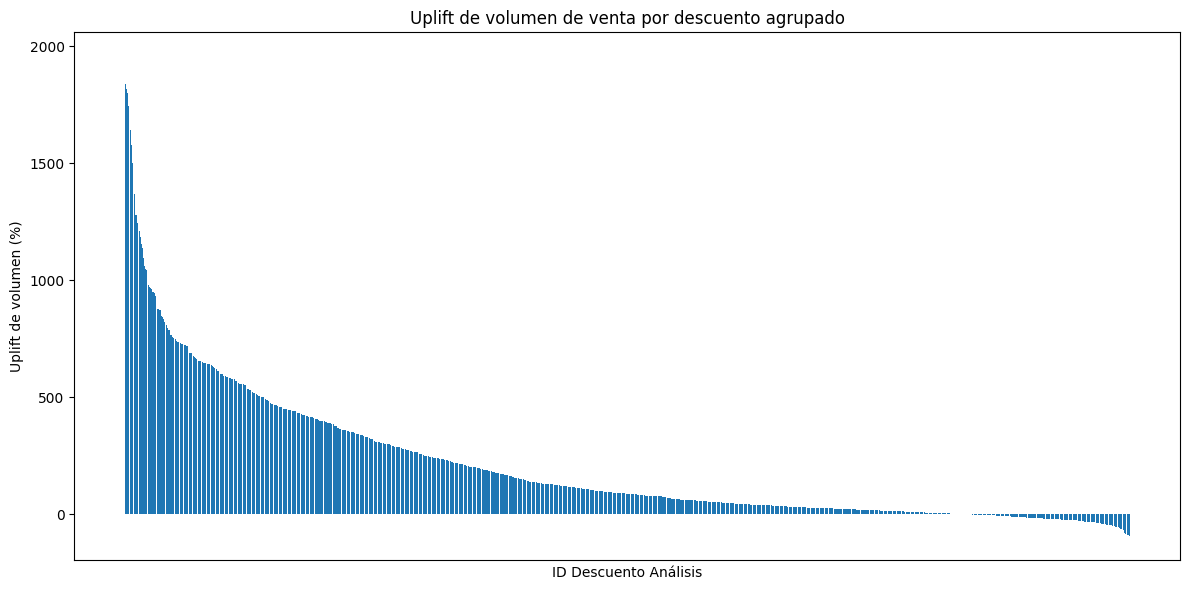

In [56]:
# Graficamos el incremento bruto de venta de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df.sort_values("Uplift de volumen (%)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["Uplift de volumen (%)"],
)
plt.title("Uplift de volumen de venta por descuento agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Uplift de volumen (%)")
plt.xticks([])
plt.tight_layout()
plt.show()


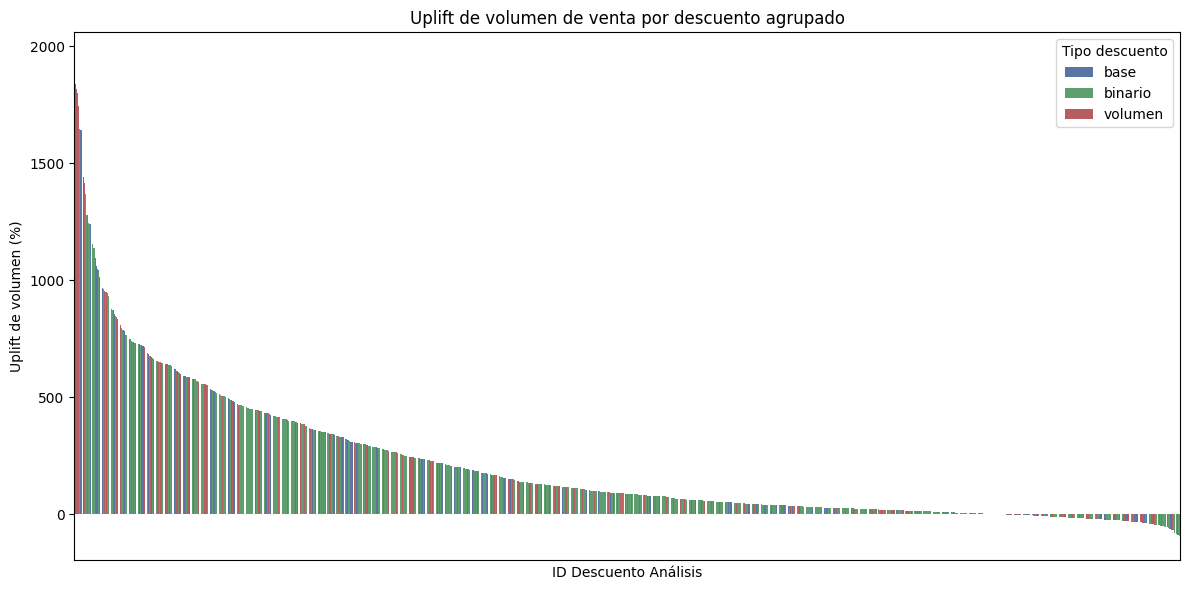

In [57]:
# Graficamos el incremento bruto de venta de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df.sort_values("Uplift de volumen (%)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="Uplift de volumen (%)",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.title("Uplift de volumen de venta por descuento agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Uplift de volumen (%)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

In [58]:
# Tabla resumen de rangos de uplift por tipo_descuento
data_grafico = resultados_df.copy()
data_grafico["Uplift de volumen (%)"] = pd.to_numeric(
    data_grafico["Uplift de volumen (%)"],
    errors="coerce",
)
data_grafico = data_grafico[
    data_grafico["Uplift de volumen (%)"].notna()
    & np.isfinite(data_grafico["Uplift de volumen (%)"])
].copy()

tol = 1e-4

condiciones = [
    data_grafico["Uplift de volumen (%)"] < -10,
    (data_grafico["Uplift de volumen (%)"] >= -10)
    & (data_grafico["Uplift de volumen (%)"] < -1),
    (data_grafico["Uplift de volumen (%)"] >= -1)
    & (data_grafico["Uplift de volumen (%)"] < -tol),
    data_grafico["Uplift de volumen (%)"].abs() <= tol,
    (data_grafico["Uplift de volumen (%)"] > tol)
    & (data_grafico["Uplift de volumen (%)"] <= 10),
    (data_grafico["Uplift de volumen (%)"] > 10)
    & (data_grafico["Uplift de volumen (%)"] <= 25),
    (data_grafico["Uplift de volumen (%)"] > 25)
    & (data_grafico["Uplift de volumen (%)"] <= 50),
    data_grafico["Uplift de volumen (%)"] > 50,
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 10",
    "10 a 25",
    "25 a 50",
    "> 50",
]

rango_uplift = np.select(
    condiciones,
    labels,
    default="otros",
)

data_grafico["rango_uplift"] = pd.Categorical(
    rango_uplift,
    categories=labels,
    ordered=True,
)

tabla_uplift = (
    pd.crosstab(
        data_grafico["rango_uplift"],
        data_grafico["tipo_descuento"],
    )
    .reindex(labels, fill_value=0)
)

# Asegurar columnas esperadas aunque alguna no aparezca en los datos filtrados
for col in ["base", "binario", "volumen"]:
    if col not in tabla_uplift.columns:
        tabla_uplift[col] = 0

tabla_uplift = tabla_uplift[["base", "binario", "volumen"]]
tabla_uplift["total"] = tabla_uplift.sum(axis=1)

assert tabla_uplift["total"].sum() == len(data_grafico), (
    f"La suma de tabla_uplift['total']={tabla_uplift['total'].sum()} "
    f"no coincide con len(data_grafico)={len(data_grafico)}"
)

assert (
    tabla_uplift[["base", "binario", "volumen"]].sum(axis=1)
    == tabla_uplift["total"]
).all(), "Las columnas por tipo no suman correctamente el total por rango."

tabla_uplift = tabla_uplift.reset_index()

display(tabla_uplift)

tipo_descuento,rango_uplift,base,binario,volumen,total
0,< -10,26,71,47,144
1,-10 a -1,8,22,20,50
2,-1 a 0,1,3,0,4
3,≈ 0,0,0,0,0
4,0 a 10,8,40,23,71
5,10 a 25,7,61,31,99
6,25 a 50,24,83,23,130
7,> 50,125,417,188,730


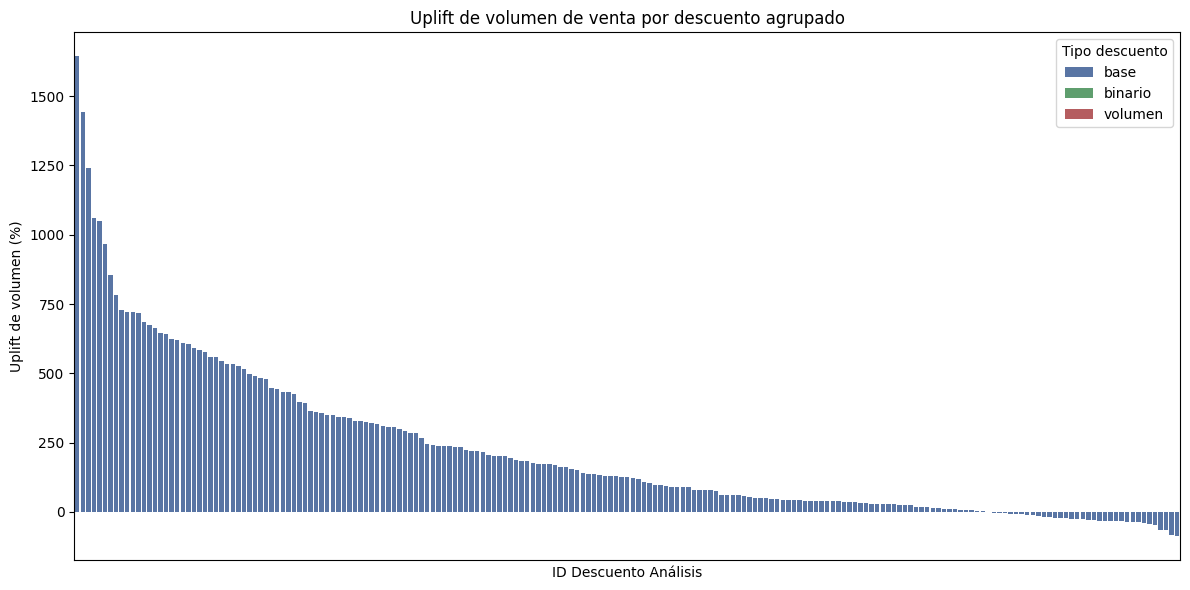

In [59]:
# Graficamos el incremento bruto de venta de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "base"
].sort_values("Uplift de volumen (%)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="Uplift de volumen (%)",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.title("Uplift de volumen de venta por descuento agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Uplift de volumen (%)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

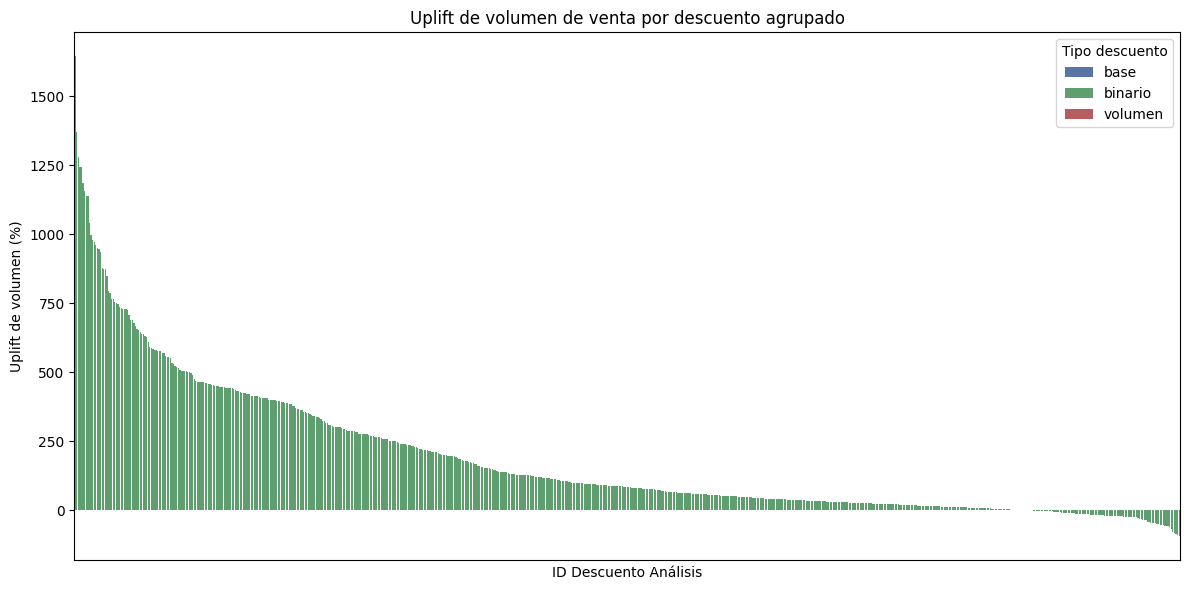

In [60]:
# Graficamos el incremento bruto de venta de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "binario"
].sort_values("Uplift de volumen (%)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="Uplift de volumen (%)",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.title("Uplift de volumen de venta por descuento agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Uplift de volumen (%)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

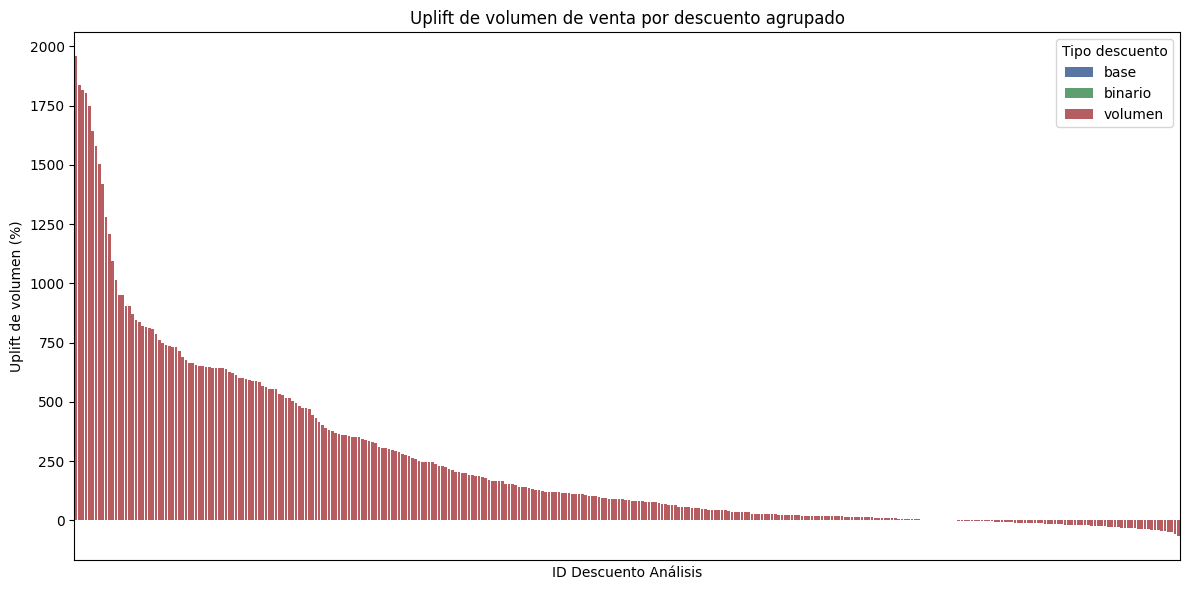

In [61]:
# Graficamos el incremento bruto de venta de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "volumen"
].sort_values("Uplift de volumen (%)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="Uplift de volumen (%)",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.title("Uplift de volumen de venta por descuento agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Uplift de volumen (%)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

## 5.4 Descuentos ordenados por ROPI

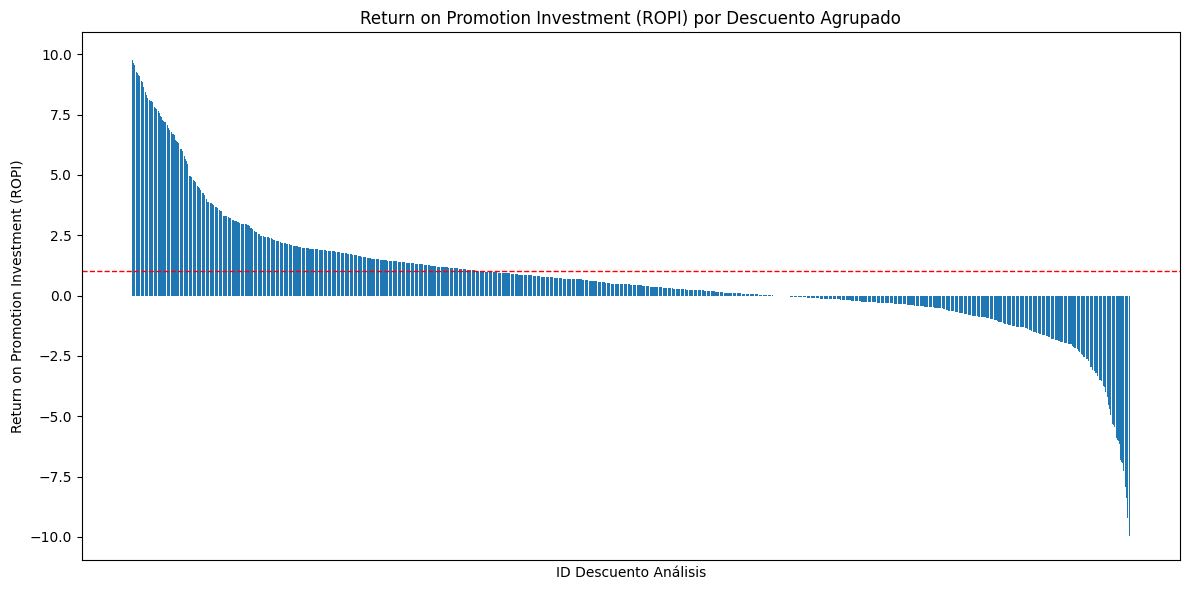

In [62]:
# Graficamos el ROPI de cada descuento agrupado, ordenados de mayor a menor
data_grafico = resultados_df.sort_values("ROPI", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["ROPI"],
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion Investment (ROPI) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.xticks([])
plt.tight_layout()
plt.show()


In [63]:
tol = 1e-4
condiciones = [
    data_grafico["ROPI"] < -10,
    (data_grafico["ROPI"] >= -10) & (data_grafico["ROPI"] < -1),
    (data_grafico["ROPI"] >= -1) & (data_grafico["ROPI"] < 0),
    data_grafico["ROPI"].abs() <= tol,
    (data_grafico["ROPI"] > 0) & (data_grafico["ROPI"] <= 1),
    data_grafico["ROPI"] > 1
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "> 1"
]

# crear columna categórica
data_grafico["rango_ropi"] = np.select(condiciones, labels, default="otros")

# tabla de conteo
tabla = data_grafico["rango_ropi"].value_counts().reindex(labels, fill_value=0).reset_index()
tabla.columns = ["rango_ropi", "cantidad"]

display(tabla)

,rango_ropi,cantidad
0,< -10,0
1,-10 a -1,166
2,-1 a 0,272
3,≈ 0,0
4,0 a 1,355
5,> 1,435


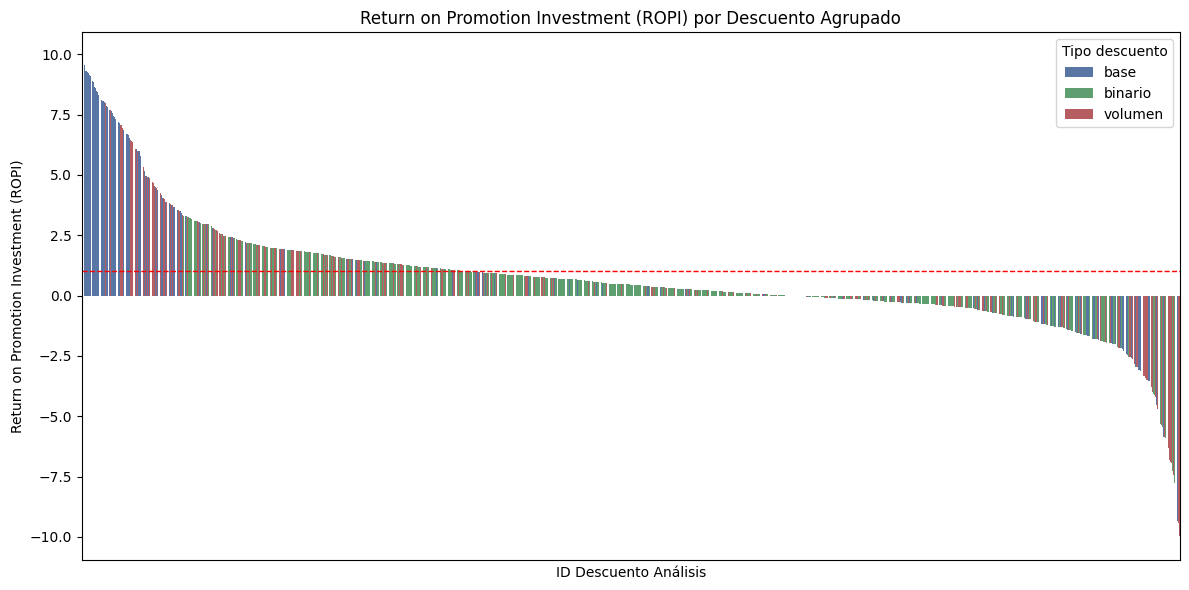

In [64]:
# Gráfico: ROPI por descuento agrupado, coloreado por tipo_descuento

data_grafico = resultados_df.sort_values(
    "ROPI",
    ascending=False,
).copy()

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion Investment (ROPI) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()


Descuentos Base Analizados: 199


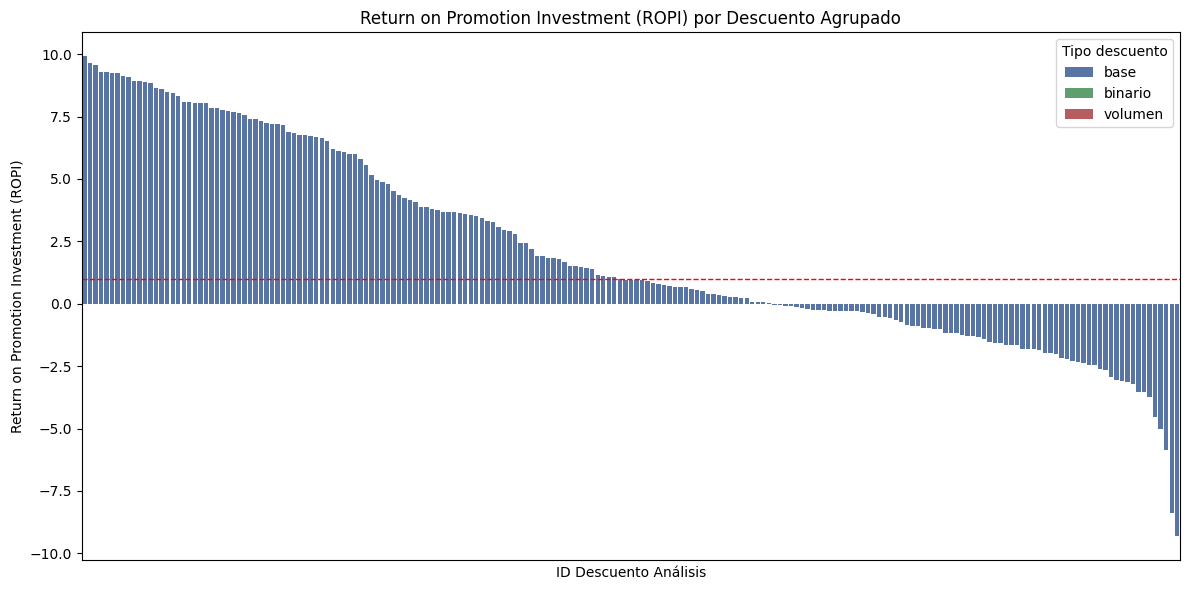

In [65]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "base"
].sort_values(
    "ROPI",
    ascending=False,
).copy()

print(f"Descuentos Base Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion Investment (ROPI) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Binario Analizados: 697


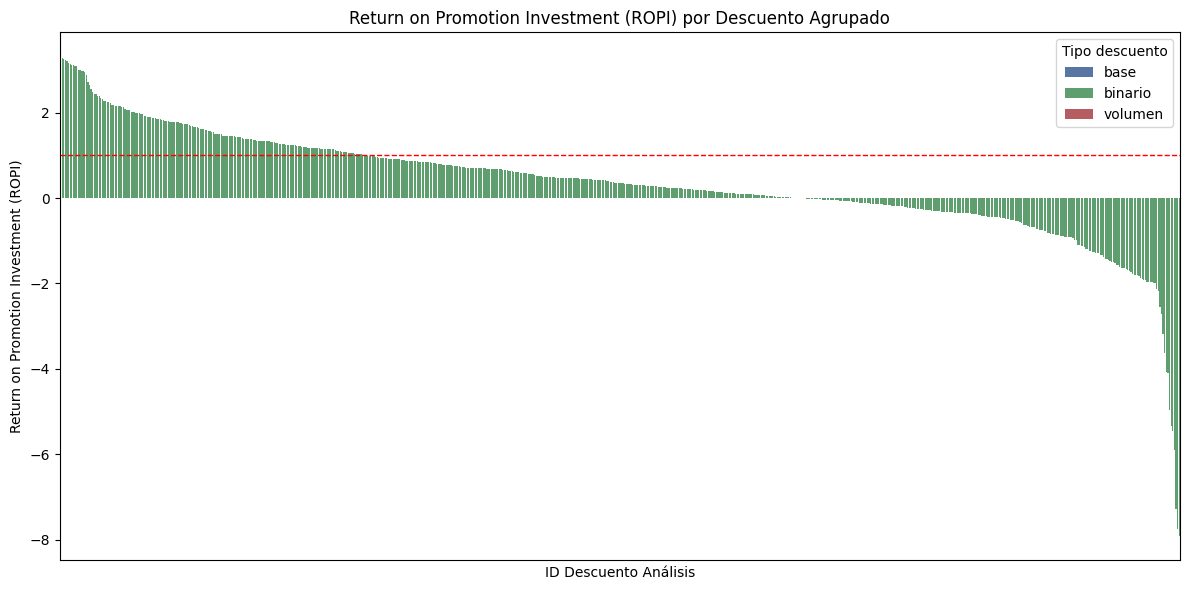

In [66]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "binario"
].sort_values(
    "ROPI",
    ascending=False,
).copy()
print(f"Descuentos Binario Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion Investment (ROPI) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Volumen Analizados: 332


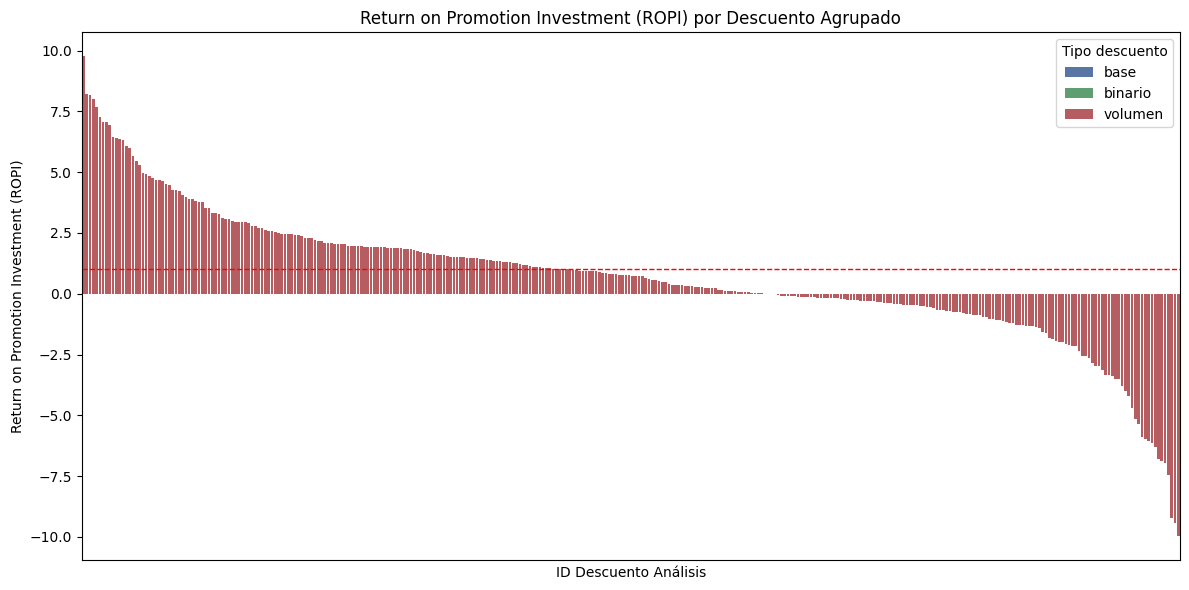

In [67]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "volumen"
].sort_values(
    "ROPI",
    ascending=False,
).copy()
print(f"Descuentos Volumen Analizados: {data_grafico.shape[0]}")


data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion Investment (ROPI) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

In [68]:
# Tabla resumen de rangos ROPI por tipo_descuento
data_grafico = resultados_df.sort_values(
    "ROPI",
    ascending=False,
).copy()
tol = 1e-4

condiciones = [
    data_grafico["ROPI"] < -10,
    (data_grafico["ROPI"] >= -10) & (data_grafico["ROPI"] < -1),
    (data_grafico["ROPI"] >= -1) & (data_grafico["ROPI"] < -tol),
    data_grafico["ROPI"].abs() <= tol,
    (data_grafico["ROPI"] > tol) & (data_grafico["ROPI"] <= 1),
    (data_grafico["ROPI"] > 1) & (data_grafico["ROPI"] <= 2),
    (data_grafico["ROPI"] > 2) & (data_grafico["ROPI"] <= 5),
    data_grafico["ROPI"] > 5,
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_grafico["rango_ropi"] = np.select(
    condiciones,
    labels,
    default="otros"
)

data_grafico["rango_ropi"] = pd.Categorical(
    data_grafico["rango_ropi"],
    categories=labels,
    ordered=True
)

tabla = (
    pd.crosstab(
        data_grafico["rango_ropi"],
        data_grafico["tipo_descuento"]
    )
    .reindex(labels, fill_value=0)
)

# Asegurar columnas esperadas aunque alguna no aparezca en los datos filtrados
for col in ["base", "binario", "volumen"]:
    if col not in tabla.columns:
        tabla[col] = 0

tabla = tabla[["base", "binario", "volumen"]]
tabla["total"] = tabla.sum(axis=1)

tabla = tabla.reset_index()

# Validaciones solicitadas
# assert tabla["total"].sum() == len(data_grafico), (
#     f"La suma de tabla['total']={tabla['total'].sum()} "
#     f"no coincide con len(data_grafico)={len(data_grafico)}"
# )

assert (
    tabla[["base", "binario", "volumen"]].sum(axis=1) == tabla["total"]
).all(), "Las columnas por tipo no suman correctamente el total por rango."

display(tabla)

tipo_descuento,rango_ropi,base,binario,volumen,total
0,< -10,0,0,0,0
1,-10 a -1,44,64,58,166
2,-1 a 0,30,174,68,272
3,≈ 0,0,0,0,0
4,0 a 1,28,268,59,355
5,1 a 2,15,144,67,226
6,2 a 5,29,47,62,138
7,> 5,53,0,18,71


## 5.5 Duración y monto del descuento vs ROPI

In [69]:
# ------------------------------------------------------------
# 1. Preparar base de análisis
# ------------------------------------------------------------

data_ropi = resultados_df.copy()

# Asegurar tipo_descuento si no quedó en resultados_df
if "tipo_descuento" not in data_ropi.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_ropi = data_ropi.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Asegurar monto_descuento_min/max si no quedaron en resultados_df
cols_monto_descuento = ["monto_descuento_min", "monto_descuento_max"]

if not all(col in data_ropi.columns for col in cols_monto_descuento):
    monto_por_descuento = (
        descuentos_analisis[
            [ID_COL_ANALISIS, "monto_descuento_min", "monto_descuento_max"]
        ]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_ropi = data_ropi.merge(
        monto_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Monto representativo del descuento.
# Para descuentos de volumen agrupados puede haber varios tramos, por eso usamos el promedio entre min y max.
data_ropi["monto_descuento_representativo"] = (
    data_ropi[["monto_descuento_min", "monto_descuento_max"]]
    .mean(axis=1)
)

# Filtrar observaciones válidas
data_ropi = data_ropi[
    data_ropi["ROPI"].notna()
    & np.isfinite(data_ropi["ROPI"])
    & data_ropi["duracion_dias"].notna()
].copy()

# ------------------------------------------------------------
# 2. Crear rangos de ROPI con los mismos intervalos definidos antes
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_ropi["ROPI"] < -10,
    (data_ropi["ROPI"] >= -10) & (data_ropi["ROPI"] < -1),
    (data_ropi["ROPI"] >= -1) & (data_ropi["ROPI"] < -tol),
    data_ropi["ROPI"].abs() <= tol,
    (data_ropi["ROPI"] > tol) & (data_ropi["ROPI"] <= 1),
    (data_ropi["ROPI"] > 1) & (data_ropi["ROPI"] <= 2),
    (data_ropi["ROPI"] > 2) & (data_ropi["ROPI"] <= 5),
    data_ropi["ROPI"] > 5,
]

labels_ropi = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_ropi["rango_ropi"] = np.select(
    condiciones,
    labels_ropi,
    default="otros",
)

data_ropi["rango_ropi"] = pd.Categorical(
    data_ropi["rango_ropi"],
    categories=labels_ropi,
    ordered=True,
)


def graficar_scatter_categorico_ropi(
    data,
    columna_categoria,
    titulo,
    xlabel,
):
    datos = data[
        data["ROPI"].notna()
        & np.isfinite(data["ROPI"])
        & data[columna_categoria].notna()
    ].copy()

    datos[columna_categoria] = (
        datos[columna_categoria]
        .astype("string")
        .fillna(ETIQUETAS_FALTANTES_CLASIFICACION_SKU[columna_categoria])
        .str.strip()
    )

    orden_categorias = datos[columna_categoria].value_counts().index.tolist()
    orden_tipos_presentes = [
        tipo for tipo in orden_tipos_descuento
        if tipo in datos["tipo_descuento"].dropna().unique()
    ]

    ancho_figura = min(max(12, 0.55 * len(orden_categorias) + 4), 24)

    plt.figure(figsize=(ancho_figura, 6))

    sns.stripplot(
        data=datos,
        x=columna_categoria,
        y="ROPI",
        hue="tipo_descuento",
        order=orden_categorias,
        hue_order=orden_tipos_presentes,
        palette=paleta_tipo_descuento,
        dodge=True,
        jitter=0.28,
        alpha=0.6,
        size=5,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel("Return on Promotion Investment (ROPI)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Tipo descuento", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [70]:

# ------------------------------------------------------------
# 3. Tabla: distribución de duración de descuentos por rango de ROPI
# ------------------------------------------------------------

tabla_duracion_por_ropi = (
    data_ropi
    .groupby("rango_ropi", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        duracion_promedio_dias=("duracion_dias", "mean"),
        duracion_mediana_dias=("duracion_dias", "median"),
        duracion_min_dias=("duracion_dias", "min"),
        duracion_p25_dias=("duracion_dias", lambda x: x.quantile(0.25)),
        duracion_p75_dias=("duracion_dias", lambda x: x.quantile(0.75)),
        duracion_max_dias=("duracion_dias", "max"),
        ropi_promedio=("ROPI", "mean"),
        ropi_mediana=("ROPI", "median"),
    )
    .reset_index()
)

tabla_duracion_por_ropi = tabla_duracion_por_ropi.round({
    "duracion_promedio_dias": 1,
    "duracion_mediana_dias": 1,
    "duracion_p25_dias": 1,
    "duracion_p75_dias": 1,
    "ropi_promedio": 2,
    "ropi_mediana": 2,
})

display(tabla_duracion_por_ropi)

,rango_ropi,n_descuentos,duracion_promedio_dias,duracion_mediana_dias,duracion_min_dias,duracion_p25_dias,duracion_p75_dias,duracion_max_dias,ropi_promedio,ropi_mediana
0,< -10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10 a -1,166,33.4,27.0,2.0,13.0,30.0,453.0,-2.74,-1.94
2,-1 a 0,272,26.5,27.0,1.0,13.0,30.0,419.0,-0.37,-0.30
3,≈ 0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0 a 1,355,25.5,27.0,1.0,18.0,27.0,453.0,0.47,0.46
5,1 a 2,226,35.5,27.0,2.0,21.0,30.0,455.0,1.46,1.44
6,2 a 5,138,103.1,29.0,2.0,23.0,34.0,453.0,3.05,2.95
7,> 5,71,313.1,442.0,2.0,30.0,453.0,455.0,7.50,7.42


In [71]:

# ------------------------------------------------------------
# 4. Paleta para pintar por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_ropi["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]


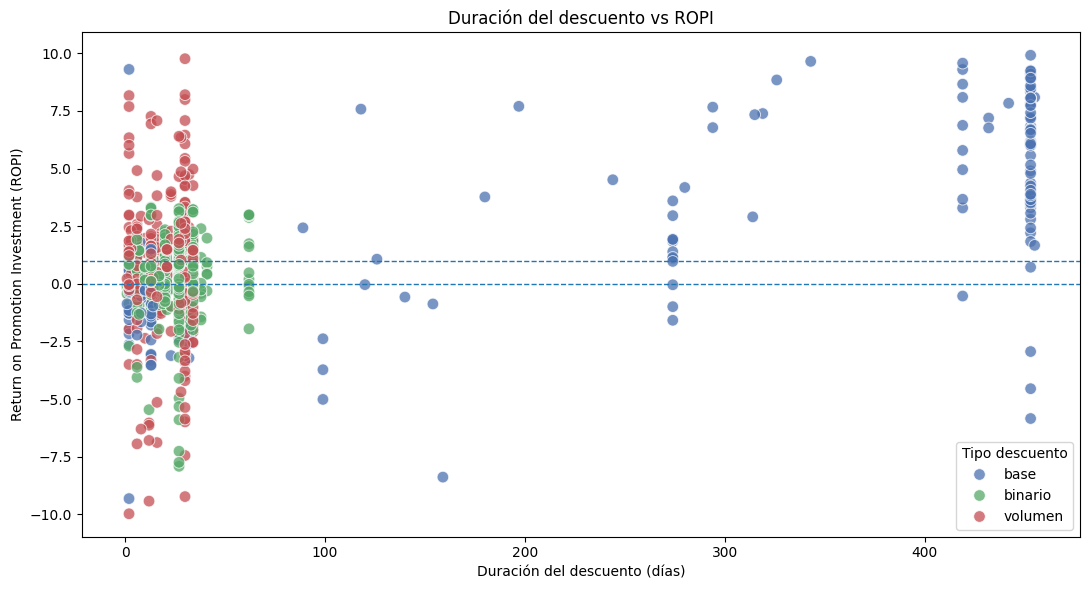

In [72]:
# ------------------------------------------------------------
# 5. Scatterplot: duración del descuento vs ROPI
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_ropi,
    x="duracion_dias",
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del descuento vs ROPI")
plt.xlabel("Duración del descuento (días)")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

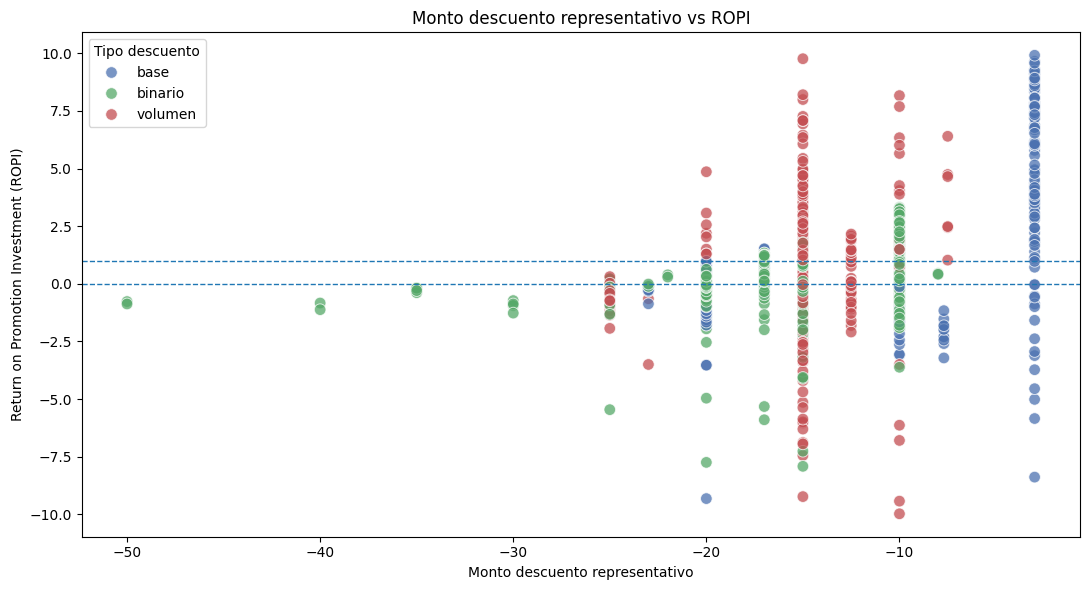

In [73]:
# ------------------------------------------------------------
# 6. Scatterplot: monto descuento representativo vs ROPI
# ------------------------------------------------------------

data_monto = data_ropi[
    data_ropi["monto_descuento_representativo"].notna()
].copy()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_monto,
    x="monto_descuento_representativo",
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Monto descuento representativo vs ROPI")
plt.xlabel("Monto descuento representativo")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

## 5.6 Scatterplots categóricos de ROPI por clasificación SKU

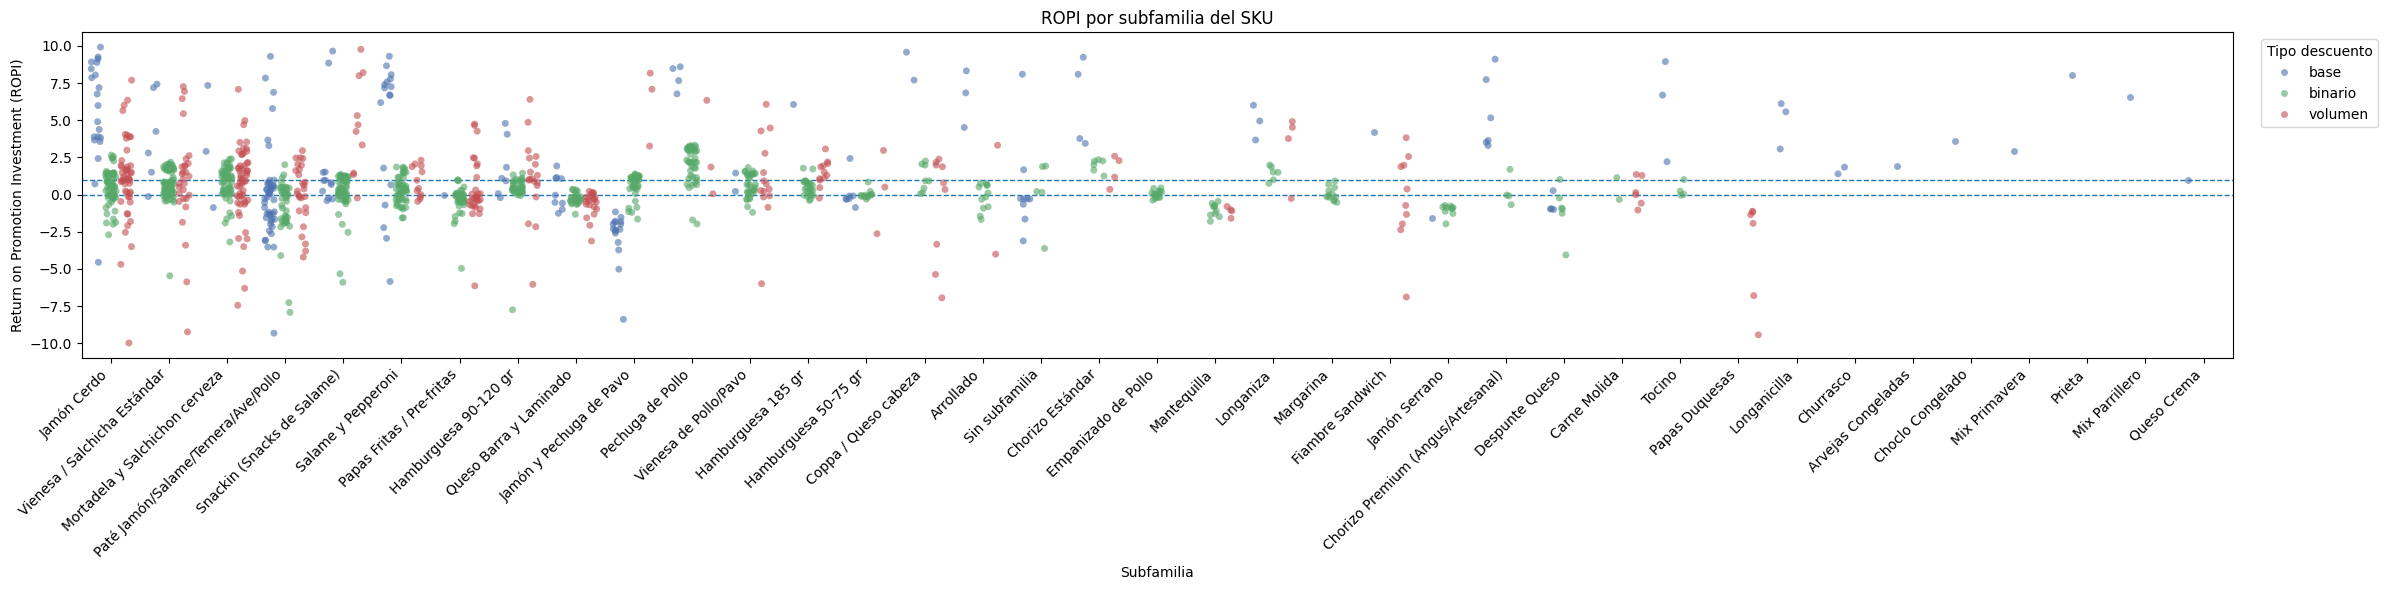

In [74]:
graficar_scatter_categorico_ropi(
    data_ropi,
    "subfamilia",
    titulo="ROPI por subfamilia del SKU",
    xlabel="Subfamilia",
)

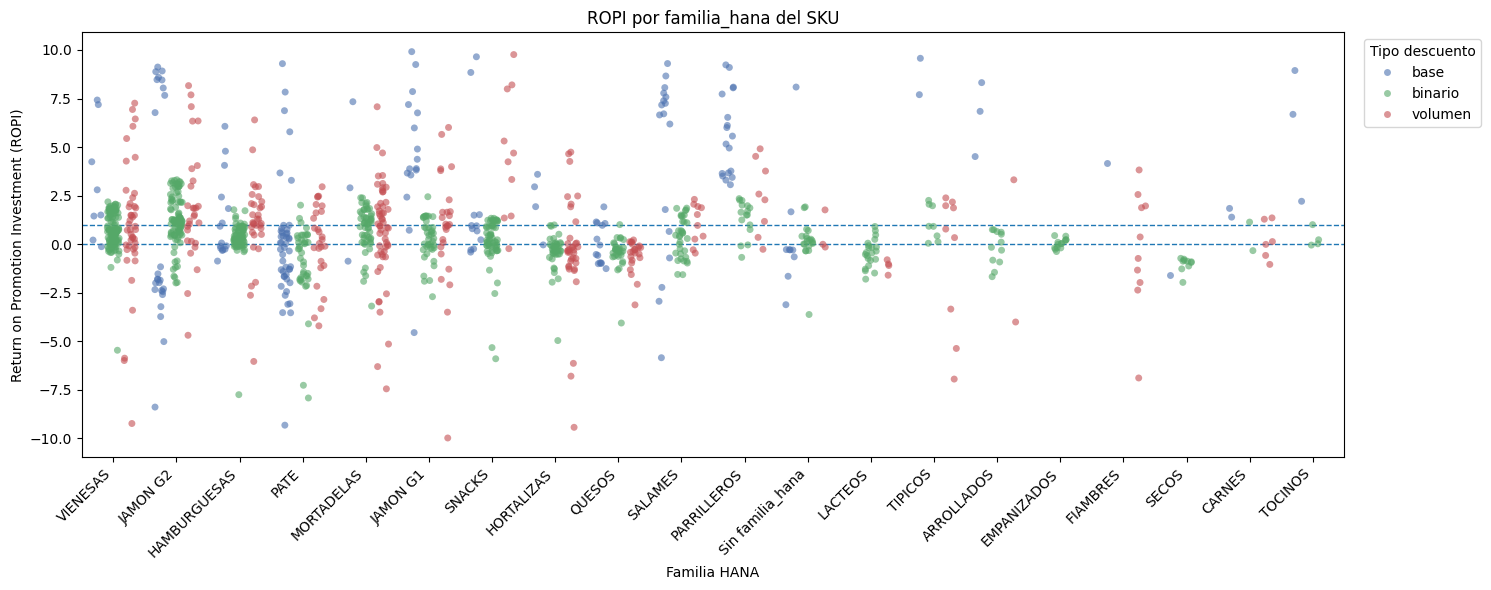

In [75]:
graficar_scatter_categorico_ropi(
    data_ropi,
    "familia_hana",
    titulo="ROPI por familia_hana del SKU",
    xlabel="Familia HANA",
)

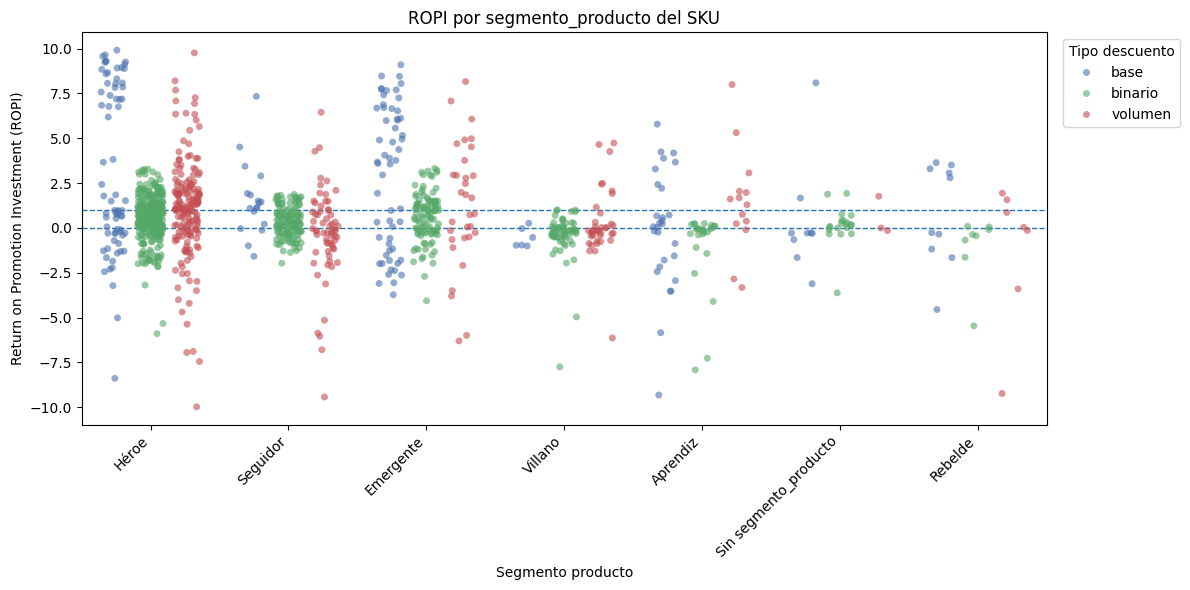

In [76]:
graficar_scatter_categorico_ropi(
    data_ropi,
    "segmento_producto",
    titulo="ROPI por segmento_producto del SKU",
    xlabel="Segmento producto",
)

## 5.7 Duración del baseline utilizado vs ROPI

,rango_ropi,n_descuentos,dias_baseline_promedio,dias_baseline_mediana,dias_baseline_min,dias_baseline_p25,dias_baseline_p75,dias_baseline_max,span_calendario_mediana,pct_con_fallback_precio_maximo,ropi_mediana
0,< -10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10 a -1,166,306.0,368.0,10.0,238.0,385.0,394.0,454.0,0.0,-1.94
2,-1 a 0,272,268.1,340.0,12.0,168.0,382.0,395.0,454.0,0.0,-0.30
3,≈ 0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0 a 1,355,255.8,255.0,12.0,173.0,378.0,395.0,454.0,0.0,0.46
5,1 a 2,226,210.9,228.5,12.0,150.0,262.2,395.0,454.0,0.0,1.44
6,2 a 5,138,188.8,217.0,11.0,71.0,256.0,395.0,454.0,0.0,2.95
7,> 5,71,164.9,149.0,37.0,86.0,230.5,387.0,454.0,0.0,7.42


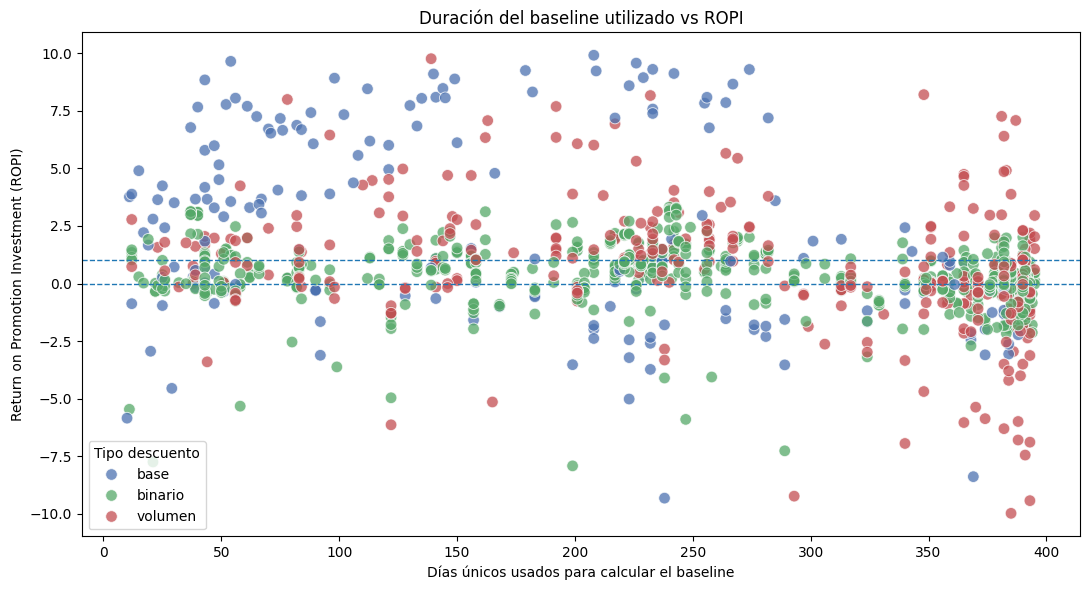

In [77]:
# ============================================================
# Duración del baseline utilizado vs ROPI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columnas_baseline_requeridas = [
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
]

columnas_baseline_faltantes = [
    columna
    for columna in columnas_baseline_requeridas
    if columna not in resultados_df.columns
]

if columnas_baseline_faltantes:
    raise KeyError(
        "Falta metadata de baseline centralizada en resultados_df: "
        + ", ".join(columnas_baseline_faltantes)
    )

data_baseline_ropi = resultados_df.copy()
data_baseline_ropi["ROPI"] = pd.to_numeric(data_baseline_ropi["ROPI"], errors="coerce")
data_baseline_ropi["dias_baseline_usados"] = pd.to_numeric(
    data_baseline_ropi["dias_baseline_usados"],
    errors="coerce",
)
data_baseline_ropi["span_calendario_baseline_dias"] = pd.to_numeric(
    data_baseline_ropi["span_calendario_baseline_dias"],
    errors="coerce",
)
data_baseline_ropi["uso_fallback_precio_maximo"] = (
    data_baseline_ropi["uso_fallback_precio_maximo"]
    .replace({"True": True, "False": False, "true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

data_baseline_ropi = data_baseline_ropi[
    data_baseline_ropi["ROPI"].notna()
    & np.isfinite(data_baseline_ropi["ROPI"])
    & data_baseline_ropi["dias_baseline_usados"].notna()
    & (data_baseline_ropi["dias_baseline_usados"] > 0)
].copy()

# ------------------------------------------------------------
# 1. Crear rangos de ROPI
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_baseline_ropi["ROPI"] < -10,
    (data_baseline_ropi["ROPI"] >= -10) & (data_baseline_ropi["ROPI"] < -1),
    (data_baseline_ropi["ROPI"] >= -1) & (data_baseline_ropi["ROPI"] < -tol),
    data_baseline_ropi["ROPI"].abs() <= tol,
    (data_baseline_ropi["ROPI"] > tol) & (data_baseline_ropi["ROPI"] <= 1),
    (data_baseline_ropi["ROPI"] > 1) & (data_baseline_ropi["ROPI"] <= 2),
    (data_baseline_ropi["ROPI"] > 2) & (data_baseline_ropi["ROPI"] <= 5),
    data_baseline_ropi["ROPI"] > 5,
]

labels_ropi = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_baseline_ropi["rango_ropi"] = np.select(
    condiciones,
    labels_ropi,
    default="otros",
)

data_baseline_ropi["rango_ropi"] = pd.Categorical(
    data_baseline_ropi["rango_ropi"],
    categories=labels_ropi,
    ordered=True,
)

# ------------------------------------------------------------
# 2. Tabla: duración del baseline por rango de ROPI
# ------------------------------------------------------------

tabla_baseline_por_ropi = (
    data_baseline_ropi
    .groupby("rango_ropi", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        dias_baseline_promedio=("dias_baseline_usados", "mean"),
        dias_baseline_mediana=("dias_baseline_usados", "median"),
        dias_baseline_min=("dias_baseline_usados", "min"),
        dias_baseline_p25=("dias_baseline_usados", lambda x: x.quantile(0.25)),
        dias_baseline_p75=("dias_baseline_usados", lambda x: x.quantile(0.75)),
        dias_baseline_max=("dias_baseline_usados", "max"),
        span_calendario_mediana=("span_calendario_baseline_dias", "median"),
        pct_con_fallback_precio_maximo=("uso_fallback_precio_maximo", "mean"),
        ropi_mediana=("ROPI", "median"),
    )
    .reset_index()
)

tabla_baseline_por_ropi["pct_con_fallback_precio_maximo"] = (
    tabla_baseline_por_ropi["pct_con_fallback_precio_maximo"] * 100
)

tabla_baseline_por_ropi = tabla_baseline_por_ropi.round({
    "dias_baseline_promedio": 1,
    "dias_baseline_mediana": 1,
    "dias_baseline_p25": 1,
    "dias_baseline_p75": 1,
    "span_calendario_mediana": 1,
    "pct_con_fallback_precio_maximo": 1,
    "ropi_mediana": 2,
})

display(tabla_baseline_por_ropi)

# ------------------------------------------------------------
# 3. Scatterplot: duración del baseline vs ROPI, pintado por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_baseline_ropi["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_baseline_ropi,
    x="dias_baseline_usados",
    y="ROPI",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del baseline utilizado vs ROPI")
plt.xlabel("Días únicos usados para calcular el baseline")
plt.ylabel("Return on Promotion Investment (ROPI)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

## 5.8 ROPI vs uplift de volumen


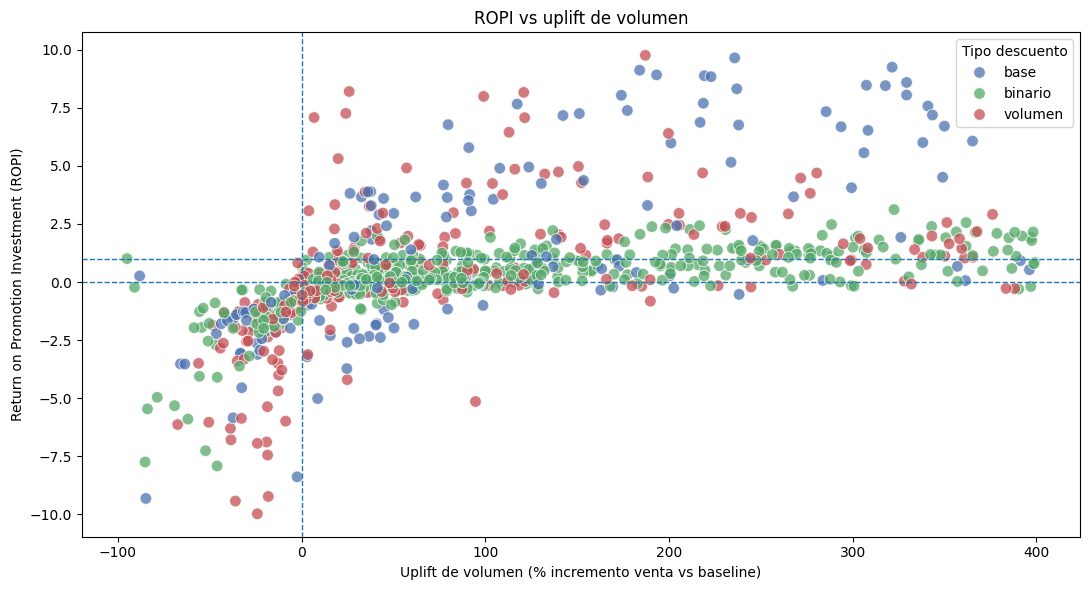

In [78]:
# ============================================================
# ROPI vs uplift de volumen
# ============================================================

data_uplift_ropi = resultados_df[
    resultados_df["ROPI"].notna()
    & np.isfinite(resultados_df["ROPI"])
    & resultados_df["Uplift de volumen (%)"].notna()
    & np.isfinite(resultados_df["Uplift de volumen (%)"])
    & (resultados_df["Uplift de volumen (%)"] <= 400)
].copy()

if "tipo_descuento" not in data_uplift_ropi.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )
    data_uplift_ropi = data_uplift_ropi.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

if "paleta_tipo_descuento" not in globals() or "orden_tipos_descuento" not in globals():
    paleta_tipo_descuento = {
        "base": "#4C72B0",
        "binario": "#55A868",
        "volumen": "#C44E52",
    }

    tipos_presentes = sorted(data_uplift_ropi["tipo_descuento"].dropna().unique())
    tipos_inesperados = [
        tipo for tipo in tipos_presentes
        if tipo not in paleta_tipo_descuento
    ]

    if tipos_inesperados:
        colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
        paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

    orden_tipos_descuento = [
        tipo for tipo in ["base", "binario", "volumen"]
        if tipo in tipos_presentes
    ] + [
        tipo for tipo in tipos_presentes
        if tipo not in ["base", "binario", "volumen"]
    ]

if data_uplift_ropi.empty:
    print("No hay descuentos con ROPI y uplift de volumen válidos para graficar.")
else:
    plt.figure(figsize=(11, 6))

    sns.scatterplot(
        data=data_uplift_ropi,
        x="Uplift de volumen (%)",
        y="ROPI",
        hue="tipo_descuento",
        hue_order=orden_tipos_descuento,
        palette=paleta_tipo_descuento,
        alpha=0.75,
        s=70,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)


    plt.title("ROPI vs uplift de volumen")
    plt.xlabel("Uplift de volumen (% incremento venta vs baseline)")
    plt.ylabel("Return on Promotion Investment (ROPI)")
    plt.legend(title="Tipo descuento")
    plt.tight_layout()
    plt.show()


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

def agregar_zonas_performance(
    ax,
    x_min,
    x_max,
    y_min,
    y_max,
    x_corte=0,
    y_corte=0,
    y_objetivo=1,
):
    """
    Pinta las zonas de performance del gráfico:
    - rojo:   x < 0, y < 0
    - beige:  x >= 0, y < 0
    - amarillo: x >= 0, 0 <= y < 1
    - verde:  x >= 0, y >= 1
    El resto queda con fondo gris claro.
    """

    colores = {
        "fondo": "#F2F2F2",
        "rojo": "#E88E86",
        "beige": "#DCBB8F",
        "amarillo": "#F2E89A",
        "verde": "#97C79A",
    }

    # Fondo general
    ax.set_facecolor(colores["fondo"])

    # Zonas coloreadas
    zonas = [
        # x, y, width, height, color, alpha
        (x_min, y_min, x_corte - x_min, y_corte - y_min, colores["rojo"], 0.80),
        (x_corte, y_min, x_max - x_corte, y_corte - y_min, colores["beige"], 0.75),
        (x_corte, y_corte, x_max - x_corte, y_objetivo - y_corte, colores["amarillo"], 0.85),
        (x_corte, y_objetivo, x_max - x_corte, y_max - y_objetivo, colores["verde"], 0.70),
    ]

    for x, y, w, h, color, alpha in zonas:
        if w > 0 and h > 0:
            ax.add_patch(
                Rectangle(
                    (x, y),
                    w,
                    h,
                    facecolor=color,
                    edgecolor="none",
                    alpha=alpha,
                    zorder=0,
                )
            )

    # Líneas de referencia
    ax.axhline(y_corte, linestyle="--", linewidth=1.5, color="#7F7F7F", zorder=1)
    ax.axhline(y_objetivo, linestyle="--", linewidth=1.5, color="#4AA3DF", zorder=1)
    ax.axvline(x_corte, linestyle="--", linewidth=1.5, color="#4AA3DF", zorder=1)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)


def calcular_limites_plot(df, x_col, y_col, x_max_fijo=400):
    x_min = min(-10, np.floor(df[x_col].min() / 10) * 10)
    x_max = x_max_fijo
    y_min = min(-10, np.floor(df[y_col].min()))
    y_max = max(10, np.ceil(df[y_col].max()))
    return x_min, x_max, y_min, y_max

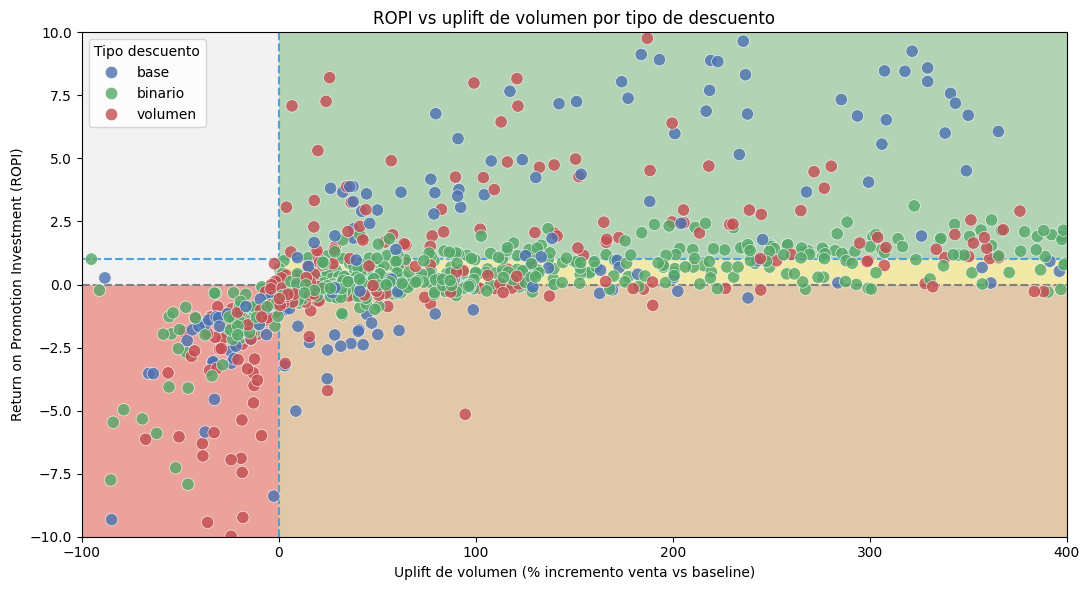

In [80]:
# ============================================================
# ROPI vs uplift de volumen destacando tipos de descuento
# ============================================================

data_uplift_ropi = resultados_df[
    resultados_df["ROPI"].notna()
    & np.isfinite(resultados_df["ROPI"])
    & resultados_df["Uplift de volumen (%)"].notna()
    & np.isfinite(resultados_df["Uplift de volumen (%)"])
    & (resultados_df["Uplift de volumen (%)"] <= 400)
].copy()

# Agregar tipo_descuento si no viene en resultados_df
if "tipo_descuento" not in data_uplift_ropi.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_uplift_ropi = data_uplift_ropi.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Normalizar tipo_descuento
data_uplift_ropi["tipo_descuento"] = (
    data_uplift_ropi["tipo_descuento"]
    .astype("string")
    .fillna("Sin tipo_descuento")
    .str.strip()
)

# Paleta para tipos de descuento
paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
    "Sin tipo_descuento": "#BDBDBD",
}

tipos_presentes = sorted(data_uplift_ropi["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette(
        "tab10",
        n_colors=len(tipos_inesperados)
    ).as_hex()

    paleta_tipo_descuento.update(
        dict(zip(tipos_inesperados, colores_extra))
    )

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen", "Sin tipo_descuento"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen", "Sin tipo_descuento"]
]

if data_uplift_ropi.empty:
    print("No hay descuentos con ROPI y uplift de volumen válidos para graficar.")
else:
    x_min, x_max, y_min, y_max = calcular_limites_plot(
        data_uplift_ropi,
        x_col="Uplift de volumen (%)",
        y_col="ROPI",
        x_max_fijo=400,
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    # Pintar zonas de performance
    agregar_zonas_performance(
        ax=ax,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        x_corte=0,
        y_corte=0,
        y_objetivo=1,
    )

    # Scatter destacando tipos de descuento
    sns.scatterplot(
        data=data_uplift_ropi,
        x="Uplift de volumen (%)",
        y="ROPI",
        hue="tipo_descuento",
        hue_order=orden_tipos_descuento,
        palette=paleta_tipo_descuento,
        alpha=0.8,
        s=80,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
        zorder=2,
    )

    ax.set_title("ROPI vs uplift de volumen por tipo de descuento")
    ax.set_xlabel("Uplift de volumen (% incremento venta vs baseline)")
    ax.set_ylabel("Return on Promotion Investment (ROPI)")
    ax.legend(title="Tipo descuento")

    plt.tight_layout()
    plt.show()

## 5.9 ROPI vs. Uplift de volumen destacando algún segmento de producto

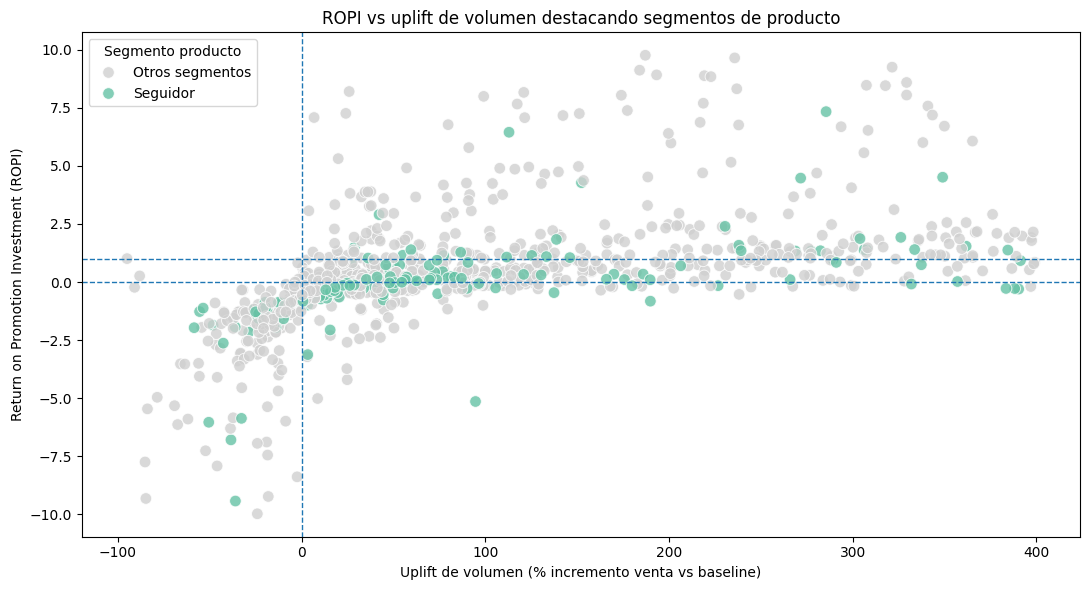

In [81]:
# ============================================================
# ROPI vs uplift de volumen destacando segmentos de producto
# ============================================================

SEGMENTOS_A_DESTACAR = ["Seguidor"]

data_uplift_segmento = resultados_df[
    resultados_df["ROPI"].notna()
    & np.isfinite(resultados_df["ROPI"])
    & resultados_df["Uplift de volumen (%)"].notna()
    & np.isfinite(resultados_df["Uplift de volumen (%)"])
    & (resultados_df["Uplift de volumen (%)"] <= 400)
].copy()

if "segmento_producto" not in data_uplift_segmento.columns:
    raise KeyError("Falta la columna 'segmento_producto' en resultados_df.")

segmentos_destacados = SEGMENTOS_A_DESTACAR
if isinstance(segmentos_destacados, str):
    segmentos_destacados = [segmentos_destacados]

data_uplift_segmento["segmento_producto"] = (
    data_uplift_segmento["segmento_producto"]
    .astype("string")
    .fillna("Sin segmento_producto")
    .str.strip()
)

segmentos_destacados = [
    str(segmento).strip()
    for segmento in segmentos_destacados
    if pd.notna(segmento) and str(segmento).strip()
]

data_uplift_segmento["grupo_segmento"] = np.where(
    data_uplift_segmento["segmento_producto"].isin(segmentos_destacados),
    data_uplift_segmento["segmento_producto"],
    "Otros segmentos",
)

segmentos_encontrados = [
    segmento
    for segmento in segmentos_destacados
    if segmento in data_uplift_segmento["segmento_producto"].unique()
]

if data_uplift_segmento.empty:
    print("No hay descuentos con ROPI y uplift de volumen válidos para graficar.")
elif not segmentos_encontrados:
    print("Ninguno de los segmentos indicados está presente en los datos filtrados.")
else:
    orden_grupos = ["Otros segmentos"] + segmentos_encontrados
    colores_destacados = sns.color_palette("Set2", n_colors=len(segmentos_encontrados)).as_hex()
    paleta_segmentos = {"Otros segmentos": "#D0D0D0"}
    paleta_segmentos.update(dict(zip(segmentos_encontrados, colores_destacados)))

    plt.figure(figsize=(11, 6))

    sns.scatterplot(
        data=data_uplift_segmento,
        x="Uplift de volumen (%)",
        y="ROPI",
        hue="grupo_segmento",
        hue_order=orden_grupos,
        palette=paleta_segmentos,
        alpha=0.8,
        s=70,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)

    plt.title("ROPI vs uplift de volumen destacando segmentos de producto")
    plt.xlabel("Uplift de volumen (% incremento venta vs baseline)")
    plt.ylabel("Return on Promotion Investment (ROPI)")
    plt.legend(title="Segmento producto")
    plt.tight_layout()
    plt.show()


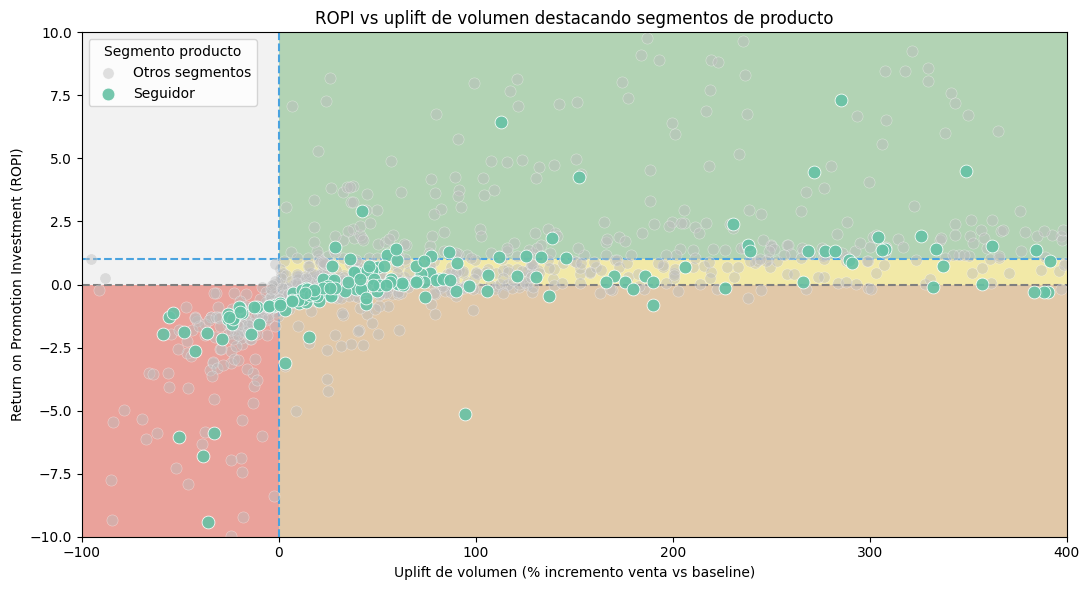

In [82]:
# ============================================================
# ROPI vs uplift de volumen destacando segmentos de producto
# ============================================================

data_uplift_segmento = resultados_df[
    resultados_df["ROPI"].notna()
    & np.isfinite(resultados_df["ROPI"])
    & resultados_df["Uplift de volumen (%)"].notna()
    & np.isfinite(resultados_df["Uplift de volumen (%)"])
    & (resultados_df["Uplift de volumen (%)"] <= 400)
].copy()

if "segmento_producto" not in data_uplift_segmento.columns:
    raise KeyError("Falta la columna 'segmento_producto' en resultados_df.")

segmentos_destacados = SEGMENTOS_A_DESTACAR
if isinstance(segmentos_destacados, str):
    segmentos_destacados = [segmentos_destacados]

data_uplift_segmento["segmento_producto"] = (
    data_uplift_segmento["segmento_producto"]
    .astype("string")
    .fillna("Sin segmento_producto")
    .str.strip()
)

segmentos_destacados = [
    str(segmento).strip()
    for segmento in segmentos_destacados
    if pd.notna(segmento) and str(segmento).strip()
]

data_uplift_segmento["grupo_segmento"] = np.where(
    data_uplift_segmento["segmento_producto"].isin(segmentos_destacados),
    data_uplift_segmento["segmento_producto"],
    "Otros segmentos",
)

segmentos_encontrados = [
    segmento
    for segmento in segmentos_destacados
    if segmento in data_uplift_segmento["segmento_producto"].unique()
]

if data_uplift_segmento.empty:
    print("No hay descuentos con ROPI y uplift de volumen válidos para graficar.")
elif not segmentos_encontrados:
    print("Ninguno de los segmentos indicados está presente en los datos filtrados.")
else:
    x_min, x_max, y_min, y_max = calcular_limites_plot(
        data_uplift_segmento,
        x_col="Uplift de volumen (%)",
        y_col="ROPI",
        x_max_fijo=400,
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    # Pintar zonas de performance
    agregar_zonas_performance(
        ax=ax,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        x_corte=0,
        y_corte=0,
        y_objetivo=1,
    )

    # 1) Graficar "otros segmentos" primero, en gris
    data_otros = data_uplift_segmento[
        data_uplift_segmento["grupo_segmento"] == "Otros segmentos"
    ]

    ax.scatter(
        data_otros["Uplift de volumen (%)"],
        data_otros["ROPI"],
        color="#BDBDBD",
        alpha=0.45,
        s=65,
        edgecolors="white",
        linewidths=0.4,
        label="Otros segmentos",
        zorder=2,
    )

    # 2) Graficar segmentos destacados encima
    colores_destacados = sns.color_palette("Set2", n_colors=len(segmentos_encontrados)).as_hex()

    for color, segmento in zip(colores_destacados, segmentos_encontrados):
        data_seg = data_uplift_segmento[
            data_uplift_segmento["grupo_segmento"] == segmento
        ]

        ax.scatter(
            data_seg["Uplift de volumen (%)"],
            data_seg["ROPI"],
            color=color,
            alpha=0.9,
            s=85,
            edgecolors="white",
            linewidths=0.6,
            label=segmento,
            zorder=3,
        )

    ax.set_title("ROPI vs uplift de volumen destacando segmentos de producto")
    ax.set_xlabel("Uplift de volumen (% incremento venta vs baseline)")
    ax.set_ylabel("Return on Promotion Investment (ROPI)")
    ax.legend(title="Segmento producto")

    plt.tight_layout()
    plt.show()

## 5.10 Tabla de cantidades de descuentos según tipo de descuento y color

In [83]:
# Tabla de cantidades de descuentos por tipo_descuento y color
data_tabla = resultados_df.copy()

data_tabla["tipo_descuento"] = (
    data_tabla["tipo_descuento"]
    .astype("string")
    .fillna("")
    .str.strip()
)
data_tabla["tipo_descuento"] = data_tabla["tipo_descuento"].mask(
    data_tabla["tipo_descuento"].eq(""),
    "Sin tipo_descuento",
)

data_tabla["color"] = (
    data_tabla["color"]
    .astype("string")
    .fillna("")
    .str.strip()
)
data_tabla["color"] = data_tabla["color"].mask(
    data_tabla["color"].eq(""),
    "gris",
)

orden_colores_tabla = ["rojo", "naranjo", "amarillo", "verde", "gris"]

tabla_tipo_color = pd.crosstab(
    data_tabla["tipo_descuento"],
    data_tabla["color"],
)

for color in orden_colores_tabla:
    if color not in tabla_tipo_color.columns:
        tabla_tipo_color[color] = 0

tabla_tipo_color = tabla_tipo_color[orden_colores_tabla]

if "orden_tipos_descuento" in globals():
    tipos_ordenados = [
        tipo for tipo in orden_tipos_descuento
        if tipo in tabla_tipo_color.index
    ]
else:
    tipos_ordenados = [
        tipo for tipo in ["base", "binario", "volumen"]
        if tipo in tabla_tipo_color.index
    ]

tipos_inesperados = sorted(
    tipo for tipo in tabla_tipo_color.index
    if tipo not in tipos_ordenados
)

tabla_tipo_color = tabla_tipo_color.reindex(
    tipos_ordenados + tipos_inesperados,
    fill_value=0,
)

tabla_tipo_color["total"] = tabla_tipo_color.sum(axis=1)

assert tabla_tipo_color["total"].sum() == len(resultados_df), (
    f"La suma de tabla_tipo_color['total']={tabla_tipo_color['total'].sum()} "
    f"no coincide con len(resultados_df)={len(resultados_df)}"
)

assert (
    tabla_tipo_color[orden_colores_tabla].sum(axis=1) == tabla_tipo_color["total"]
).all(), "Las columnas por color no suman correctamente el total por tipo_descuento."

display(tabla_tipo_color.reset_index())


color,tipo_descuento,rojo,naranjo,amarillo,verde,gris,total
0,base,34,40,27,97,1,199
1,binario,93,145,266,190,3,697
2,volumen,65,61,57,147,2,332


In [84]:
# tabla_tipo_color.to_excel("tabla_tipo_color")

## 5.11 Tabla de cantidades de descuentos según segmento de producto y color

In [85]:
# Tabla de cantidades de descuentos por segmento_producto y color
data_tabla = resultados_df.copy()

if "orden_colores_tabla" not in globals():
    orden_colores_tabla = ["rojo", "naranjo", "amarillo", "verde", "gris"]

data_tabla["segmento_producto"] = (
    data_tabla["segmento_producto"]
    .astype("string")
    .fillna("")
    .str.strip()
)
data_tabla["segmento_producto"] = data_tabla["segmento_producto"].mask(
    data_tabla["segmento_producto"].eq(""),
    "Sin segmento_producto",
)

data_tabla["color"] = (
    data_tabla["color"]
    .astype("string")
    .fillna("")
    .str.strip()
)
data_tabla["color"] = data_tabla["color"].mask(
    data_tabla["color"].eq(""),
    "gris",
)

tabla_segmento_color = pd.crosstab(
    data_tabla["segmento_producto"],
    data_tabla["color"],
)

for color in orden_colores_tabla:
    if color not in tabla_segmento_color.columns:
        tabla_segmento_color[color] = 0

tabla_segmento_color = tabla_segmento_color[orden_colores_tabla]
tabla_segmento_color["total"] = tabla_segmento_color.sum(axis=1)

assert tabla_segmento_color["total"].sum() == len(resultados_df), (
    f"La suma de tabla_segmento_color['total']={tabla_segmento_color['total'].sum()} "
    f"no coincide con len(resultados_df)={len(resultados_df)}"
)

assert (
    tabla_segmento_color[orden_colores_tabla].sum(axis=1)
    == tabla_segmento_color["total"]
).all(), "Las columnas por color no suman correctamente el total por segmento_producto."

tabla_segmento_color = (
    tabla_segmento_color
    .reset_index()
    .sort_values(["total", "segmento_producto"], ascending=[False, True], kind="stable")
    .reset_index(drop=True)
)

assert tabla_segmento_color["segmento_producto"].nunique() == data_tabla["segmento_producto"].nunique(), (
    "La tabla de segmento_producto no incluye todos los segmentos presentes en resultados_df."
)

display(tabla_segmento_color)


color,segmento_producto,rojo,naranjo,amarillo,verde,gris,total
0,Héroe,80,78,185,248,1,592
1,Seguidor,29,57,74,56,0,216
2,Emergente,29,33,35,94,0,191
3,Villano,20,51,22,8,4,105
4,Aprendiz,20,12,19,16,0,67
5,Sin segmento_producto,8,7,11,5,1,32
6,Rebelde,6,8,4,7,0,25


## 5.12 Búsqueda de ejemplos para comité

In [86]:
resultados_df.head()

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-16.001080,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo,binario
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,CB,54.0,...,215.595900,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,amarillo,binario
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-12.502899,389.0,2025-01-02,2026-03-31,454.0,77049,260011.852,False,rojo,volumen
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,CB,54.0,...,528.065061,262.0,2025-01-02,2026-03-31,454.0,2293,9505.799,False,verde,volumen
4,6,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,CB,32.0,...,-6.316177,371.0,2025-01-02,2026-03-31,454.0,6603,21825.425,False,rojo,binario


In [87]:
gris = resultados_df[(
(resultados_df["segmento_producto"] == "Héroe") &
(resultados_df["color"] == "gris")
)].sort_values("ROPI", ascending=False)

gris.head()

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
419,491,[3914],1,False,3003,Jamón y Pechuga de Pavo,JAMON G2,Héroe,CB,32.0,...,-0.294757,387.0,2025-01-02,2026-03-31,454.0,46405,169608.426,False,gris,binario


In [88]:
buenos_ejemplos = resultados_df[(
(resultados_df["segmento_producto"] == "Emergente") &
(resultados_df["color"] == "verde")
)].sort_values("ROPI", ascending=False)

buenos_ejemplos.head()

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
749,901,[1932],1,False,3850,Chorizo Premium (Angus/Artesanal),PARRILLEROS,Emergente,CB,54.0,...,728.442852,140.0,2025-01-02,2026-03-31,454.0,234,783.000,False,verde,base
329,389,[475],1,False,1695,Pechuga de Pollo,JAMON G2,Emergente,CB,54.0,...,307.478962,144.0,2025-01-02,2026-03-31,454.0,243,985.295,False,verde,base
337,398,[485],1,False,1831,Jamón Cerdo,JAMON G2,Emergente,CB,54.0,...,317.809899,112.0,2025-01-02,2026-03-31,454.0,190,1885.998,False,verde,base
443,518,"[74903, 74904, 74905]",3,True,3017,Jamón y Pechuga de Pavo,JAMON G2,Emergente,CB,54.0,...,120.919586,232.0,2025-01-09,2026-03-31,447.0,2479,9541.123,False,verde,volumen
734,878,[1829],1,False,3640,Prieta,PARRILLEROS,Emergente,CB,54.0,...,329.356146,56.0,2025-01-02,2026-03-31,454.0,77,328.000,False,verde,base


In [89]:
ejemplos_no_alineados = resultados_df[(
(resultados_df["segmento_producto"] == "Aprendiz") &
(resultados_df["color"].isin(["amarillo", "naranja"]))
)].sort_values("ROPI", ascending=False)

ejemplos_no_alineados

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
89,99,"[75626, 75627, 75628]",3,True,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,307.365987,38.0,2025-01-02,2026-03-16,439.0,123,274.0,False,amarillo,volumen
730,868,[1762],1,False,3600,Jamón Cerdo,JAMON G1,Aprendiz,CB,54.0,...,15.125119,30.0,2025-01-14,2026-03-31,442.0,36,57.5,False,amarillo,base
589,688,[1266],1,False,3142,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,356.980219,43.0,2025-02-12,2026-03-24,406.0,65,172.0,False,amarillo,base
607,710,[1296],1,False,3145,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,163.346175,39.0,2025-01-03,2026-03-25,447.0,86,266.0,False,amarillo,base
599,700,[1281],1,False,3144,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,182.221511,47.0,2025-02-12,2026-03-24,406.0,70,180.0,False,amarillo,base
611,715,"[75182, 75183, 75184]",3,True,3145,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,3.745761,39.0,2025-01-03,2026-03-25,447.0,86,266.0,False,amarillo,volumen
83,93,[2511],1,False,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,200.456681,38.0,2025-01-02,2026-03-16,439.0,123,274.0,False,amarillo,base
742,893,[4175],1,False,3844,Snackin (Snacks de Salame),SNACKS,Aprendiz,CB,54.0,...,88.236156,78.0,2025-05-30,2026-03-31,306.0,218,130.0,False,amarillo,binario
88,98,"[75623, 75624, 75625]",3,True,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,70.275819,368.0,2025-01-02,2026-03-16,439.0,4165,9118.0,False,amarillo,volumen
737,888,[1908],1,False,3844,Snackin (Snacks de Salame),SNACKS,Aprendiz,CB,54.0,...,89.207367,78.0,2025-05-30,2026-03-31,306.0,218,130.0,False,amarillo,base


In [90]:
ejemplos_desalineados = resultados_df[(
(resultados_df["segmento_producto"] == "Aprendiz") &
(resultados_df["color"].isin(["rojo"]))
)].sort_values("ROPI", ascending=False)

ejemplos_desalineados

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,cod_canal,cod_consolidado,...,Uplift de volumen (%),dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo,color,tipo_descuento
789,943,[4200],1,False,3899,Hamburguesa 185 gr,HAMBURGUESAS,Aprendiz,CB,54.0,...,-1.687873,50.0,2026-02-02,2026-03-31,58.0,456,2001.7,False,rojo,binario
787,941,[4198],1,False,3899,Hamburguesa 185 gr,HAMBURGUESAS,Aprendiz,CB,54.0,...,-16.665220,50.0,2026-02-02,2026-03-31,58.0,456,2001.7,False,rojo,binario
598,699,[1279],1,False,3144,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,54.0,...,-19.671953,47.0,2025-02-12,2026-03-24,406.0,70,180.0,False,rojo,base
85,95,[4403],1,False,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-10.573052,368.0,2025-01-02,2026-03-16,439.0,4165,9118.0,False,rojo,binario
84,94,[4402],1,False,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-16.176023,368.0,2025-01-02,2026-03-16,439.0,4165,9118.0,False,rojo,binario
604,707,[1291],1,False,3145,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-37.166214,289.0,2025-01-02,2026-03-13,436.0,701,1484.0,False,rojo,base
585,684,[1260],1,False,3142,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-43.789714,238.0,2025-01-02,2026-03-13,436.0,509,1264.0,False,rojo,base
81,91,[2507],1,False,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-14.331998,368.0,2025-01-02,2026-03-16,439.0,4165,9118.0,False,rojo,base
80,90,[2506],1,False,440,Paté Jamón/Salame/Ternera/Ave/Pollo,PATE,Aprendiz,CB,32.0,...,-21.691890,368.0,2025-01-02,2026-03-16,439.0,4165,9118.0,False,rojo,base
823,987,[4237],1,False,3945,Snackin (Snacks de Salame),SNACKS,Aprendiz,CB,32.0,...,-50.957001,80.0,2025-12-27,2026-03-31,95.0,3748,801.0,False,rojo,binario


## 5.13 ROPI vs. Uplift de volumen destacando algún id_descuento análisis en particular

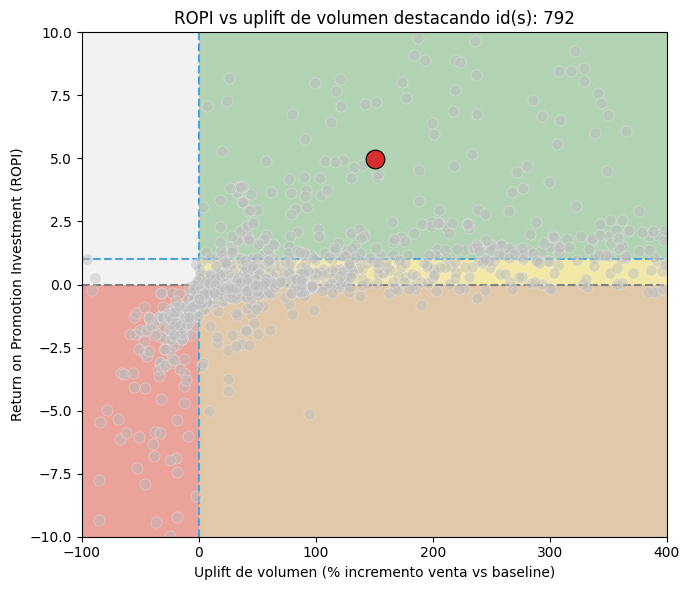

,id_descuento_analisis,tipo_descuento,segmento_producto,color,Uplift de volumen (%),ROPI,Margen incremental bruto ($),Costo Promoción ($)
0,792,volumen,Emergente,verde,150.684857,4.97522,8.972670e+06,1803472.0


In [91]:
ID_DSCTO_ANALISIS_DESTACAR = 792  # tambien puede ser [792, 845]

if "calcular_limites_plot" not in globals() or "agregar_zonas_performance" not in globals():
    raise NameError(
        "Primero ejecuta la celda donde se definen 'calcular_limites_plot' y 'agregar_zonas_performance'."
    )


def graficar_ropi_vs_uplift_destacando_ids(
    df,
    ids_destacados,
    id_col=ID_COL_ANALISIS,
    x_col="Uplift de volumen (%)",
    y_col="ROPI",
    x_max_fijo=400,
):
    data_plot = df[
        df[y_col].notna()
        & np.isfinite(df[y_col])
        & df[x_col].notna()
        & np.isfinite(df[x_col])
        & (df[x_col] <= x_max_fijo)
    ].copy()

    if data_plot.empty:
        print("No hay descuentos con ROPI y uplift validos para graficar.")
        return None

    if isinstance(ids_destacados, (list, tuple, set, pd.Series, np.ndarray)):
        ids_destacados = list(ids_destacados)
    else:
        ids_destacados = [ids_destacados]

    ids_destacados_norm = [
        str(valor).strip()
        for valor in ids_destacados
        if pd.notna(valor) and str(valor).strip()
    ]

    if not ids_destacados_norm:
        raise ValueError("Debes indicar al menos un id_descuento_analisis valido.")

    data_plot["_id_plot"] = data_plot[id_col].astype(str).str.strip()
    data_plot["_destacado"] = data_plot["_id_plot"].isin(ids_destacados_norm)

    data_destacada = data_plot[data_plot["_destacado"]].copy()

    if data_destacada.empty:
        print("Ninguno de los ids indicados esta presente en la base filtrada para el grafico.")
        return None

    data_destacada = data_destacada.sort_values(
        [y_col, x_col],
        ascending=[False, False],
        kind="stable",
    )

    x_min, x_max, y_min, y_max = calcular_limites_plot(
        data_plot,
        x_col=x_col,
        y_col=y_col,
        x_max_fijo=x_max_fijo,
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    agregar_zonas_performance(
        ax=ax,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        x_corte=0,
        y_corte=0,
        y_objetivo=1,
    )

    data_no_destacada = data_plot[~data_plot["_destacado"]]

    ax.scatter(
        data_no_destacada[x_col],
        data_no_destacada[y_col],
        color="#BDBDBD",
        alpha=0.45,
        s=65,
        edgecolors="white",
        linewidths=0.4,
        label="Otros descuentos",
        zorder=2,
    )

    ax.scatter(
        data_destacada[x_col],
        data_destacada[y_col],
        color="#D62728",
        alpha=0.95,
        s=180,
        edgecolors="black",
        linewidths=0.9,
        label="Ejemplo destacado",
        zorder=3,
    )

    desplazamientos = [(12, 12), (12, -20), (-90, 12), (-90, -20)]

    for i, (_, fila) in enumerate(data_destacada.iterrows()):
        dx, dy = desplazamientos[i % len(desplazamientos)]
        etiqueta = [f"ID {fila['_id_plot']}"]

        if "segmento_producto" in fila.index and pd.notna(fila.get("segmento_producto")):
            etiqueta.append(str(fila.get("segmento_producto")))

        etiqueta.append(f"ROPI={fila[y_col]:.2f}")
        etiqueta.append(f"Uplift={fila[x_col]:.1f}%")

        # ax.annotate(
        #     "\n".join(etiqueta),
        #     xy=(fila[x_col], fila[y_col]),
        #     xytext=(dx, dy),
        #     textcoords="offset points",
        #     fontsize=9,
        #     bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#333333", "alpha": 0.95},
        #     arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1},
        #     zorder=4,
        # )

    ids_titulo = ", ".join(data_destacada["_id_plot"].tolist())
    ax.set_title(f"ROPI vs uplift de volumen destacando id(s): {ids_titulo}")
    ax.set_xlabel("Uplift de volumen (% incremento venta vs baseline)")
    ax.set_ylabel("Return on Promotion Investment (ROPI)")
    # ax.legend(title="Grupo")

    plt.tight_layout()
    plt.show()

    columnas_resumen = [
        id_col,
        "tipo_descuento",
        "segmento_producto",
        "color",
        x_col,
        y_col,
        "Margen incremental bruto ($)",
        "Costo Promoción ($)",
        "Incremento Venta ($)",
    ]
    columnas_resumen = [columna for columna in columnas_resumen if columna in data_destacada.columns]

    return data_destacada[columnas_resumen].reset_index(drop=True)


resumen_id_destacado = graficar_ropi_vs_uplift_destacando_ids(
    resultados_df,
    ID_DSCTO_ANALISIS_DESTACAR,
)

if resumen_id_destacado is not None:
    display(resumen_id_destacado)


## 5.14 Búsqueda de descuentos según id

In [92]:
required_globals_514 = [
    "descuentos_raw",
    "descuentos",
    "descuentos_analisis",
    "resultados_df_pre_graficos",
    "resultados_df",
    "ID_COL_ANALISIS",
    "_preparar_descuentos_para_analisis",
    "_normalizar_tipo_descuento_descuentos",
]
missing_globals_514 = [nombre for nombre in required_globals_514 if nombre not in globals()]

if missing_globals_514:
    raise NameError(
        "Faltan objetos para ejecutar 5.14. Reejecuta el notebook al menos hasta la sección 4. "
        f"Faltantes: {missing_globals_514}"
    )

COLUMNAS_DETALLE_514 = [
    "id_descuento",
    ID_COL_ANALISIS,
    "tipo_descuento",
    "cod_sku",
    "cod_canal",
    "cod_consolidado",
    "fecha_inicio_original",
    "fecha_fin_original",
    "fecha_inicio",
    "fecha_fin",
    "monto_descuento",
    "pasa_pre_analisis",
    "esta_en_descuentos_analisis",
    "esta_en_resultados_pre_graficos",
    "esta_en_resultados_finales",
    "ROPI_pre_graficos",
    "Uplift de volumen (%)_pre_graficos",
    "color_pre_graficos",
    "segmento_producto_pre_graficos",
    "ROPI",
    "Uplift de volumen (%)",
    "color",
    "segmento_producto",
]

COLUMNAS_RESUMEN_BUSQUEDA_514 = [
    "id_descuento",
    ID_COL_ANALISIS,
    "tipo_descuento",
    "cod_consolidado",
    "fecha_inicio",
    "fecha_fin",
    "monto_descuento",
    "pasa_pre_analisis",
    "esta_en_resultados_pre_graficos",
    "esta_en_resultados_finales",
]


def _normalizar_texto_busqueda(valor):
    if pd.isna(valor):
        return None

    texto = str(valor).strip()
    return texto if texto else None



def _mask_match_valor(serie, valor):
    texto = _normalizar_texto_busqueda(valor)

    if texto is None:
        return pd.Series(False, index=serie.index)

    mask = serie.astype("string").str.strip().eq(texto)

    valor_num = pd.to_numeric(pd.Series([texto]), errors="coerce").iloc[0]
    if pd.notna(valor_num):
        valor_num = float(valor_num)
        valor_num = int(valor_num) if valor_num.is_integer() else valor_num
        mask = mask | pd.to_numeric(serie, errors="coerce").eq(valor_num)

    return mask.fillna(False)



def _es_cod_consolidado_generico(serie):
    return serie.isna() | serie.astype("string").str.strip().eq("")



def _construir_base_descuentos_busqueda():
    base = _normalizar_tipo_descuento_descuentos(descuentos_raw)
    base = _preparar_descuentos_para_analisis(base)

    mapa_ids = descuentos[["id_descuento", ID_COL_ANALISIS]].drop_duplicates()
    base = base.merge(mapa_ids, on="id_descuento", how="left")

    base["pasa_pre_analisis"] = base["id_descuento"].isin(
        descuentos["id_descuento"].dropna().unique()
    )
    base["esta_en_descuentos_analisis"] = base[ID_COL_ANALISIS].isin(
        descuentos_analisis[ID_COL_ANALISIS].dropna().unique()
    )
    base["esta_en_resultados_pre_graficos"] = base[ID_COL_ANALISIS].isin(
        resultados_df_pre_graficos[ID_COL_ANALISIS].dropna().unique()
    )
    base["esta_en_resultados_finales"] = base[ID_COL_ANALISIS].isin(
        resultados_df[ID_COL_ANALISIS].dropna().unique()
    )

    columnas_pre = [
        columna
        for columna in [ID_COL_ANALISIS, "ROPI", "Uplift de volumen (%)", "color", "segmento_producto"]
        if columna in resultados_df_pre_graficos.columns
    ]
    if columnas_pre:
        detalle_pre = (
            resultados_df_pre_graficos[columnas_pre]
            .drop_duplicates(ID_COL_ANALISIS)
            .rename(columns={
                "ROPI": "ROPI_pre_graficos",
                "Uplift de volumen (%)": "Uplift de volumen (%)_pre_graficos",
                "color": "color_pre_graficos",
                "segmento_producto": "segmento_producto_pre_graficos",
            })
        )
        base = base.merge(detalle_pre, on=ID_COL_ANALISIS, how="left")

    columnas_final = [
        columna
        for columna in [ID_COL_ANALISIS, "ROPI", "Uplift de volumen (%)", "color", "segmento_producto"]
        if columna in resultados_df.columns
    ]
    if columnas_final:
        detalle_final = resultados_df[columnas_final].drop_duplicates(ID_COL_ANALISIS)
        base = base.merge(detalle_final, on=ID_COL_ANALISIS, how="left")

    return base



def buscar_descuentos_por_llave(sku, canal, fecha, consolidado=None):
    if _normalizar_texto_busqueda(sku) is None:
        raise ValueError("Debes indicar un SKU válido.")
    if _normalizar_texto_busqueda(canal) is None:
        raise ValueError("Debes indicar un canal válido.")
    if fecha is None:
        raise ValueError("Debes indicar una fecha válida.")

    fecha_busqueda = pd.to_datetime(fecha).normalize()
    base = _construir_base_descuentos_busqueda()

    coincidencias = base.loc[
        _mask_match_valor(base["cod_sku"], sku)
        & _mask_match_valor(base["cod_canal"], canal)
        & base["fecha_inicio"].dt.normalize().le(fecha_busqueda)
        & base["fecha_fin"].dt.normalize().ge(fecha_busqueda)
    ].copy()

    if coincidencias.empty:
        return pd.DataFrame(columns=COLUMNAS_DETALLE_514)

    if _normalizar_texto_busqueda(consolidado) is not None:
        mask_exacto = _mask_match_valor(coincidencias["cod_consolidado"], consolidado)
        mask_generico = _es_cod_consolidado_generico(coincidencias["cod_consolidado"])
        coincidencias = coincidencias.loc[mask_exacto | mask_generico].copy()
        coincidencias["_prioridad_consolidado"] = 1
        coincidencias.loc[
            _mask_match_valor(coincidencias["cod_consolidado"], consolidado),
            "_prioridad_consolidado",
        ] = 0
    else:
        coincidencias["_prioridad_consolidado"] = 1

    if coincidencias.empty:
        return pd.DataFrame(columns=COLUMNAS_DETALLE_514)

    coincidencias = coincidencias.sort_values(
        ["_prioridad_consolidado", "fecha_inicio", "fecha_fin", "id_descuento"],
        ascending=[True, True, True, True],
        kind="stable",
    )

    columnas_presentes = [
        columna for columna in COLUMNAS_DETALLE_514 if columna in coincidencias.columns
    ]
    return coincidencias[columnas_presentes].reset_index(drop=True)


In [93]:
required_globals_traza_514 = [
    "descuentos_raw",
    "descuentos",
    "descuentos_analisis",
    "resultados_df_pre_graficos",
    "resultados_df",
    "filtros_pre_graficos",
    "filtros_descuentos_pre_analisis_tempranos",
    "filtros_descuentos_pre_analisis_tardios",
    "COLUMNAS_DETALLE_514",
    "_mask_match_valor",
    "_construir_base_descuentos_busqueda",
]
missing_globals_traza_514 = [
    nombre for nombre in required_globals_traza_514 if nombre not in globals()
]

if missing_globals_traza_514:
    raise NameError(
        "Faltan objetos para ejecutar la trazabilidad de 5.14. "
        f"Faltantes: {missing_globals_traza_514}"
    )


def _diagnosticar_primer_filtro_que_excluye(df, filtros, id_col, valor_id):
    actual = df.copy()
    historial = []

    if not _mask_match_valor(actual[id_col], valor_id).any():
        return {
            "primer_filtro": None,
            "notas": "",
            "historial": pd.DataFrame(),
        }

    for paso, condicion, notas in filtros:
        mask = condicion(actual) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, actual)
        siguiente = actual.loc[mask].copy()

        estaba_antes = bool(_mask_match_valor(actual[id_col], valor_id).any())
        sigue_despues = bool(_mask_match_valor(siguiente[id_col], valor_id).any())

        historial.append({
            "paso": paso,
            "presente_antes": estaba_antes,
            "presente_despues": sigue_despues,
            "elimina_id": estaba_antes and not sigue_despues,
            "notas": notas,
        })

        if estaba_antes and not sigue_despues:
            return {
                "primer_filtro": paso,
                "notas": notas,
                "historial": pd.DataFrame(historial),
            }

        actual = siguiente

    return {
        "primer_filtro": None,
        "notas": "",
        "historial": pd.DataFrame(historial),
    }


def trazar_descuento_por_id(id_busqueda):
    valor_busqueda = _normalizar_texto_busqueda(id_busqueda)
    if valor_busqueda is None:
        raise ValueError("Debes indicar un id_descuento o id_descuento_analisis válido.")

    base_descuentos = _construir_base_descuentos_busqueda()

    def formatear(valor, decimales=2):
        if pd.isna(valor):
            return "NaN"
        if isinstance(valor, (int, float, np.integer, np.floating)):
            return f"{float(valor):.{decimales}f}"
        return str(valor)

    def construir_resumen_compacto(
        estado,
        id_descuento=None,
        id_descuento_analisis=None,
        primer_filtro=None,
        fila_final=None,
        prioriza_id_analisis=False,
    ):
        lineas = []

        if prioriza_id_analisis:
            lineas.append(
                f"El valor {valor_busqueda} coincide como id_descuento y como {ID_COL_ANALISIS}; "
                f"se prioriza {ID_COL_ANALISIS}."
            )

        if estado == "no_encontrado":
            return [f"No se encontró el id {valor_busqueda}."]

        if estado == "filtrado_pre_analisis":
            return lineas + [
                f"id_descuento {id_descuento} excluido en pre-análisis por: {primer_filtro}."
            ]

        if estado == "sin_id_descuento_analisis":
            return lineas + [
                f"id_descuento {id_descuento} sobrevive al pre-análisis, pero no resuelve {ID_COL_ANALISIS}."
            ]

        if estado == "ausente_pre_graficos":
            return lineas + [
                f"{ID_COL_ANALISIS}: {id_descuento_analisis}. No llega a resultados_df_pre_graficos."
            ]

        if estado == "filtrado_pre_graficos":
            return lineas + [
                f"{ID_COL_ANALISIS}: {id_descuento_analisis}. Sale de resultados_df por: {primer_filtro}."
            ]

        if estado == "final" and fila_final is not None:
            return lineas + [
                f"{ID_COL_ANALISIS}: {id_descuento_analisis}. "
                f"ROPI={formatear(fila_final.get('ROPI'))} | "
                f"Uplift={formatear(fila_final.get('Uplift de volumen (%)'))}% | "
                f"color={fila_final.get('color', np.nan)} | "
                f"segmento={fila_final.get('segmento_producto', np.nan)}"
            ]

        return lineas + [f"{ID_COL_ANALISIS}: {id_descuento_analisis}."]

    def construir_detalle_analisis(id_descuento_analisis):
        detalle = descuentos_analisis.loc[
            _mask_match_valor(descuentos_analisis[ID_COL_ANALISIS], id_descuento_analisis)
        ].copy()

        if detalle.empty:
            return detalle

        columnas_base = [
            ID_COL_ANALISIS,
            "ids_descuento_originales",
            "n_ids_descuento_originales",
            "es_descuento_agrupado",
            "cod_sku",
            "tipo_descuento",
            "cod_canal",
            "cod_consolidado",
            "fecha_inicio",
            "fecha_fin",
            "duracion_dias",
        ]
        detalle = detalle[[col for col in columnas_base if col in detalle.columns]]

        columnas_pre = [
            columna
            for columna in [ID_COL_ANALISIS, "ROPI", "Uplift de volumen (%)", "color", "segmento_producto"]
            if columna in resultados_df_pre_graficos.columns
        ]
        if columnas_pre:
            detalle_pre = (
                resultados_df_pre_graficos[columnas_pre]
                .drop_duplicates(ID_COL_ANALISIS)
                .rename(columns={
                    "ROPI": "ROPI_pre_graficos",
                    "Uplift de volumen (%)": "Uplift de volumen (%)_pre_graficos",
                    "color": "color_pre_graficos",
                    "segmento_producto": "segmento_producto_pre_graficos",
                })
            )
            detalle = detalle.merge(detalle_pre, on=ID_COL_ANALISIS, how="left")

        columnas_final = [
            columna
            for columna in [ID_COL_ANALISIS, "ROPI", "Uplift de volumen (%)", "color", "segmento_producto"]
            if columna in resultados_df.columns
        ]
        if columnas_final:
            detalle_final = resultados_df[columnas_final].drop_duplicates(ID_COL_ANALISIS)
            detalle = detalle.merge(detalle_final, on=ID_COL_ANALISIS, how="left")

        return detalle.reset_index(drop=True)

    def construir_resultado(
        estado,
        resumen,
        id_descuento_analisis=None,
        detalle_descuento=None,
        detalle_analisis=None,
        historial_filtros=None,
        resumen_compacto=None,
    ):
        return {
            "estado": estado,
            "resumen": resumen,
            "resumen_compacto": resumen_compacto or resumen,
            "id_descuento_analisis": id_descuento_analisis,
            "detalle_descuento": detalle_descuento if detalle_descuento is not None else pd.DataFrame(),
            "detalle_analisis": detalle_analisis if detalle_analisis is not None else pd.DataFrame(),
            "historial_filtros": (
                historial_filtros.reset_index(drop=True)
                if historial_filtros is not None and not historial_filtros.empty
                else pd.DataFrame()
            ),
        }

    def resolver_desde_id_analisis(
        id_descuento_analisis,
        resumen,
        historial_pre=None,
        prioriza_id_analisis=False,
    ):
        historial_filtros = historial_pre.copy() if historial_pre is not None else pd.DataFrame()
        detalle_descuento = base_descuentos.loc[
            _mask_match_valor(base_descuentos[ID_COL_ANALISIS], id_descuento_analisis)
        ].copy()
        detalle_descuento = detalle_descuento[
            [col for col in COLUMNAS_DETALLE_514 if col in detalle_descuento.columns]
        ].reset_index(drop=True)
        detalle_analisis = construir_detalle_analisis(id_descuento_analisis)

        resumen.append(f"{ID_COL_ANALISIS} resuelto: {id_descuento_analisis}")

        fila_pre = resultados_df_pre_graficos.loc[
            _mask_match_valor(resultados_df_pre_graficos[ID_COL_ANALISIS], id_descuento_analisis)
        ].copy()
        fila_final = resultados_df.loc[
            _mask_match_valor(resultados_df[ID_COL_ANALISIS], id_descuento_analisis)
        ].copy()

        estado = "final"
        primer_filtro = None
        fila_final_resuelta = None

        if fila_pre.empty:
            estado = "ausente_pre_graficos"
            resumen.append(
                "El descuento existe en descuentos_analisis, pero no aparece en resultados_df_pre_graficos."
            )
        elif fila_final.empty:
            diagnostico = _diagnosticar_primer_filtro_que_excluye(
                resultados_df_pre_graficos,
                filtros_pre_graficos,
                ID_COL_ANALISIS,
                id_descuento_analisis,
            )
            historial_resultados = diagnostico["historial"].copy()
            if not historial_resultados.empty:
                historial_resultados["etapa_pipeline"] = "resultados"
                historial_filtros = pd.concat(
                    [historial_filtros, historial_resultados],
                    ignore_index=True,
                )
            estado = "filtrado_pre_graficos"
            primer_filtro = diagnostico["primer_filtro"]
            resumen.append(
                "El descuento llega a resultados_df_pre_graficos, "
                f"pero queda fuera de resultados_df por el filtro: {diagnostico['primer_filtro']}."
            )
            if diagnostico["notas"]:
                resumen.append(f"Detalle del filtro: {diagnostico['notas']}")
        else:
            fila_final_resuelta = fila_final.iloc[0]
            resumen.append("El descuento llega al resultado final vigente.")
            resumen.append(
                "Ubicación final: "
                f"ROPI={formatear(fila_final_resuelta.get('ROPI'))}, "
                f"Uplift={formatear(fila_final_resuelta.get('Uplift de volumen (%)'))}%, "
                f"color={fila_final_resuelta.get('color', np.nan)}, "
                f"segmento_producto={fila_final_resuelta.get('segmento_producto', np.nan)}"
            )

        return construir_resultado(
            estado=estado,
            resumen=resumen,
            id_descuento_analisis=id_descuento_analisis,
            detalle_descuento=detalle_descuento,
            detalle_analisis=detalle_analisis,
            historial_filtros=historial_filtros,
            resumen_compacto=construir_resumen_compacto(
                estado,
                id_descuento_analisis=id_descuento_analisis,
                primer_filtro=primer_filtro,
                fila_final=fila_final_resuelta,
                prioriza_id_analisis=prioriza_id_analisis,
            ),
        )

    coincidencias_raw = descuentos_raw.loc[
        _mask_match_valor(descuentos_raw["id_descuento"], id_busqueda)
    ].copy()
    coincidencias_analisis = descuentos_analisis.loc[
        _mask_match_valor(descuentos_analisis[ID_COL_ANALISIS], id_busqueda)
    ].copy()

    if coincidencias_raw.empty and coincidencias_analisis.empty:
        return construir_resultado(
            estado="no_encontrado",
            resumen=[
                f"No se encontró el id {valor_busqueda} ni como id_descuento ni como {ID_COL_ANALISIS}."
            ],
            detalle_descuento=pd.DataFrame(columns=COLUMNAS_DETALLE_514),
            resumen_compacto=construir_resumen_compacto("no_encontrado"),
        )

    resumen = []

    if not coincidencias_analisis.empty:
        prioriza_id_analisis = not coincidencias_raw.empty
        if prioriza_id_analisis:
            resumen.append(
                f"El valor {valor_busqueda} coincide tanto con id_descuento como con {ID_COL_ANALISIS}. "
                f"Se prioriza {ID_COL_ANALISIS} para la traza principal."
            )

        id_descuento_analisis = coincidencias_analisis[ID_COL_ANALISIS].iloc[0]
        resumen.append(
            "IDs descuento originales del grupo: "
            f"{coincidencias_analisis['ids_descuento_originales'].iloc[0]}"
        )
        return resolver_desde_id_analisis(
            id_descuento_analisis,
            resumen,
            prioriza_id_analisis=prioriza_id_analisis,
        )

    id_descuento = coincidencias_raw["id_descuento"].iloc[0]
    detalle_descuento = base_descuentos.loc[
        _mask_match_valor(base_descuentos["id_descuento"], id_descuento)
    ].copy()
    detalle_descuento = detalle_descuento[
        [col for col in COLUMNAS_DETALLE_514 if col in detalle_descuento.columns]
    ].reset_index(drop=True)

    resumen.append(f"id_descuento encontrado en descuentos_raw: {id_descuento}")

    base_temprana = _normalizar_tipo_descuento_descuentos(descuentos_raw)
    diagnostico_temprano = _diagnosticar_primer_filtro_que_excluye(
        base_temprana,
        filtros_descuentos_pre_analisis_tempranos,
        "id_descuento",
        id_descuento,
    )

    if diagnostico_temprano["primer_filtro"] is not None:
        historial_filtros = diagnostico_temprano["historial"].copy()
        if not historial_filtros.empty:
            historial_filtros["etapa_pipeline"] = "preparación temprana"
        resumen.append(
            "El descuento no llega a descuentos_analisis. "
            f"Se excluye primero en: {diagnostico_temprano['primer_filtro']}."
        )
        if diagnostico_temprano["notas"]:
            resumen.append(f"Detalle del filtro: {diagnostico_temprano['notas']}")
        return construir_resultado(
            estado="filtrado_pre_analisis",
            resumen=resumen,
            detalle_descuento=detalle_descuento,
            historial_filtros=historial_filtros,
            resumen_compacto=construir_resumen_compacto(
                "filtrado_pre_analisis",
                id_descuento=id_descuento,
                primer_filtro=diagnostico_temprano["primer_filtro"],
            ),
        )

    historial_pre = diagnostico_temprano["historial"].copy()
    if not historial_pre.empty:
        historial_pre["etapa_pipeline"] = "preparación temprana"

    base_tardia = _aplicar_filtros_sin_registro(
        base_temprana,
        filtros_descuentos_pre_analisis_tempranos,
    )
    base_tardia = _preparar_descuentos_para_analisis(base_tardia)
    diagnostico_tardio = _diagnosticar_primer_filtro_que_excluye(
        base_tardia,
        filtros_descuentos_pre_analisis_tardios,
        "id_descuento",
        id_descuento,
    )

    historial_tardio = diagnostico_tardio["historial"].copy()
    if not historial_tardio.empty:
        historial_tardio["etapa_pipeline"] = "preparación tardía"
        historial_pre = pd.concat([historial_pre, historial_tardio], ignore_index=True)

    if diagnostico_tardio["primer_filtro"] is not None:
        resumen.append(
            "El descuento no llega a descuentos_analisis. "
            f"Se excluye primero en: {diagnostico_tardio['primer_filtro']}."
        )
        if diagnostico_tardio["notas"]:
            resumen.append(f"Detalle del filtro: {diagnostico_tardio['notas']}")
        return construir_resultado(
            estado="filtrado_pre_analisis",
            resumen=resumen,
            detalle_descuento=detalle_descuento,
            historial_filtros=historial_pre,
            resumen_compacto=construir_resumen_compacto(
                "filtrado_pre_analisis",
                id_descuento=id_descuento,
                primer_filtro=diagnostico_tardio["primer_filtro"],
            ),
        )

    fila_mapeo = descuentos.loc[
        _mask_match_valor(descuentos["id_descuento"], id_descuento),
        ["id_descuento", ID_COL_ANALISIS],
    ].drop_duplicates()

    if fila_mapeo.empty:
        resumen.append(
            "El descuento sobrevive al pre-análisis, pero no se pudo resolver su id_descuento_analisis."
        )
        return construir_resultado(
            estado="sin_id_descuento_analisis",
            resumen=resumen,
            detalle_descuento=detalle_descuento,
            historial_filtros=historial_pre,
            resumen_compacto=construir_resumen_compacto(
                "sin_id_descuento_analisis",
                id_descuento=id_descuento,
            ),
        )

    id_descuento_analisis = fila_mapeo[ID_COL_ANALISIS].iloc[0]
    resumen.append("El descuento sobrevive al pre-análisis.")
    return resolver_desde_id_analisis(id_descuento_analisis, resumen, historial_pre)


In [94]:
# Wrappers de uso: búsqueda por caso

def buscar_caso_514(caso, mostrar=True):
    caso = dict(caso or {})
    resultados = pd.DataFrame(columns=COLUMNAS_DETALLE_514)
    ids_candidatos = []
    id_sugerido = None

    sku = caso.get("sku")
    canal = caso.get("canal")
    fecha = caso.get("fecha")
    consolidado = caso.get("consolidado")

    if (
        _normalizar_texto_busqueda(sku) is None
        or _normalizar_texto_busqueda(canal) is None
        or fecha is None
    ):
        columnas_resumen = [
            columna
            for columna in COLUMNAS_RESUMEN_BUSQUEDA_514
            if columna in resultados.columns
        ]
        resultado = {
            "caso": caso,
            "resultados": resultados,
            "columnas_resumen": columnas_resumen,
            "ids_candidatos": ids_candidatos,
            "id_sugerido": id_sugerido,
        }
        globals()["resultados_busqueda_514"] = resultados
        globals()["IDS_BUSQUEDA_CANDIDATOS"] = ids_candidatos
        globals()["ID_BUSQUEDA_SUGERIDO"] = id_sugerido
        if mostrar:
            print("Cada caso debe incluir sku, canal y fecha para ejecutar la búsqueda.")
        return resultado

    resultados = buscar_descuentos_por_llave(
        sku=sku,
        canal=canal,
        fecha=fecha,
        consolidado=consolidado,
    )

    if not resultados.empty:
        if ID_COL_ANALISIS in resultados.columns:
            ids_candidatos = (
                resultados[ID_COL_ANALISIS]
                .dropna()
                .drop_duplicates()
                .tolist()
            )

        if not ids_candidatos and "id_descuento" in resultados.columns:
            ids_candidatos = (
                resultados["id_descuento"]
                .dropna()
                .drop_duplicates()
                .tolist()
            )

        if ids_candidatos:
            id_sugerido = ids_candidatos[0]

    columnas_resumen = [
        columna
        for columna in COLUMNAS_RESUMEN_BUSQUEDA_514
        if columna in resultados.columns
    ]

    resultado = {
        "caso": caso,
        "resultados": resultados,
        "columnas_resumen": columnas_resumen,
        "ids_candidatos": ids_candidatos,
        "id_sugerido": id_sugerido,
    }

    globals()["resultados_busqueda_514"] = resultados
    globals()["IDS_BUSQUEDA_CANDIDATOS"] = ids_candidatos
    globals()["ID_BUSQUEDA_SUGERIDO"] = id_sugerido

    if mostrar:
        nombre_caso = caso.get("nombre") or "Caso 5.14"
        encabezado = f"{nombre_caso} | descuentos={resultados.shape[0]}"
        if id_sugerido is not None:
            encabezado += f" | sugerido={id_sugerido}"
        elif resultados.empty:
            encabezado += " | sin coincidencias"
        if len(ids_candidatos) > 1:
            encabezado += f" | candidatos={ids_candidatos}"
        print(encabezado)
        if not resultados.empty:
            display(resultados[columnas_resumen] if columnas_resumen else resultados)

    return resultado


In [95]:
# Wrappers de uso: trazabilidad por caso

def trazar_caso_514(
    resultado_busqueda=None,
    id_busqueda=None,
    usar_sugerido=True,
    graficar=False,
    mostrar=True,
):
    id_resuelto = id_busqueda

    if (
        _normalizar_texto_busqueda(id_resuelto) is None
        and usar_sugerido
        and isinstance(resultado_busqueda, dict)
    ):
        id_resuelto = resultado_busqueda.get("id_sugerido")

    if _normalizar_texto_busqueda(id_resuelto) is None:
        trazabilidad = {
            "estado": "sin_id",
            "resumen": [
                "No hay un id para trazar. Pasa id_busqueda o usa el id_sugerido de buscar_caso_514.",
            ],
            "resumen_compacto": [
                "No hay un id para trazar.",
            ],
            "id_descuento_analisis": None,
            "detalle_descuento": pd.DataFrame(),
            "detalle_analisis": pd.DataFrame(),
            "historial_filtros": pd.DataFrame(),
        }
        globals()["ID_BUSQUEDA"] = None
        globals()["trazabilidad_descuento_514"] = trazabilidad
        if mostrar:
            print("\n".join(trazabilidad["resumen_compacto"]))
        return trazabilidad

    trazabilidad = trazar_descuento_por_id(id_resuelto)
    globals()["ID_BUSQUEDA"] = id_resuelto
    globals()["trazabilidad_descuento_514"] = trazabilidad

    if mostrar:
        print("\n".join(trazabilidad.get("resumen_compacto", trazabilidad["resumen"])))

        tabla_principal = trazabilidad["detalle_analisis"]
        if tabla_principal.empty:
            tabla_principal = trazabilidad["detalle_descuento"]

        if not tabla_principal.empty:
            display(tabla_principal)

        if (
            trazabilidad["estado"] in {"filtrado_pre_analisis", "filtrado_pre_graficos"}
            and not trazabilidad["historial_filtros"].empty
        ):
            display(trazabilidad["historial_filtros"])

    if (
        graficar
        and trazabilidad["estado"] == "final"
        and trazabilidad["id_descuento_analisis"] is not None
    ):
        if "graficar_ropi_vs_uplift_destacando_ids" in globals():
            graficar_ropi_vs_uplift_destacando_ids(
                resultados_df,
                trazabilidad["id_descuento_analisis"],
            )
        elif mostrar:
            print("No se pudo graficar porque falta graficar_ropi_vs_uplift_destacando_ids en memoria.")

    return trazabilidad


def revisar_caso_514(caso, graficar=False, mostrar_busqueda=True, mostrar_traza=True):
    resultado_busqueda = buscar_caso_514(caso, mostrar=mostrar_busqueda)

    if resultado_busqueda["id_sugerido"] is None:
        trazabilidad = {
            "estado": "sin_id",
            "resumen": [
                "No hay un id sugerido para trazar en este caso.",
            ],
            "resumen_compacto": [
                "No hay un id sugerido para trazar en este caso.",
            ],
            "id_descuento_analisis": None,
            "detalle_descuento": pd.DataFrame(),
            "detalle_analisis": pd.DataFrame(),
            "historial_filtros": pd.DataFrame(),
        }
        globals()["trazabilidad_descuento_514"] = trazabilidad
        if mostrar_traza:
            print("\n".join(trazabilidad["resumen_compacto"]))
    else:
        trazabilidad = trazar_caso_514(
            resultado_busqueda=resultado_busqueda,
            usar_sugerido=True,
            graficar=graficar,
            mostrar=mostrar_traza,
        )

    return {
        "resultado_busqueda": resultado_busqueda,
        "trazabilidad": trazabilidad,
    }


In [96]:
# Casos iterables para 5.14
CASOS_514 = [
    {"nombre": "Enero 2025", "canal": "CB", "consolidado": 32, "sku": 3017, "fecha": "03-01-2025"},
    {"nombre": "Febrero 2025", "canal": "CB", "consolidado": 32, "sku": 3018, "fecha": "03-02-2025"},
    {"nombre": "Marzo 2025", "canal": "CB", "consolidado": 32, "sku": 3879, "fecha": "03-03-2025"},
    {"nombre": "Abril 2025", "canal": "CB", "consolidado": 32, "sku": 3985, "fecha": "03-04-2025"},
    {"nombre": "Mayo 2025", "canal": "CB", "consolidado": 32, "sku": 8453, "fecha": "07-05-2025"},
    {"nombre": "Junio 2025", "canal": "CB", "consolidado": 32, "sku": 3456, "fecha": "03-06-2025"},
    {"nombre": "Julio 2025", "canal": "CB", "consolidado": 32, "sku": 3038, "fecha": "03-07-2025"},
    {"nombre": "Agosto 2025", "canal": "CB", "consolidado": 32, "sku": 710, "fecha": "06-08-2025"},
    {"nombre": "Septiembre 2025", "canal": "CB", "consolidado": 32, "sku": 1228, "fecha": "03-09-2025"},
    {"nombre": "Octubre 2025", "canal": "CB", "consolidado": 32, "sku": 3922, "fecha": "03-10-2025"},
    {"nombre": "Noviembre 2025", "canal": "CB", "consolidado": 32, "sku": 916, "fecha": "05-11-2025"},
    {"nombre": "Diciembre 2025", "canal": "CB", "consolidado": 32, "sku": 3148, "fecha": "03-12-2025"},
    {"nombre": "Enero 2026", "canal": "CB", "consolidado": 32, "sku": 3003, "fecha": "03-01-2025"},
    {"nombre": "Febrero 2026", "canal": "CB", "consolidado": 32, "sku": 3945, "fecha": "03-02-2026"},
    {"nombre": "Marzo 2026", "canal": "CB", "consolidado": 32, "sku": 3945, "fecha": "03-03-2026"},
]

# Ejemplos de uso:
# resultado = buscar_caso_514(CASOS_514[0])
# traza = trazar_caso_514(resultado)
# revision = revisar_caso_514(CASOS_514[0])
# for caso in CASOS_514:
#     revisar_caso_514(caso, graficar=False)
